# SwSL Recognition — Reviewer-Response Retraining Pipeline (v2)

**Manuscript.** *A Swahili Sign Language Recognition Using Bidirectional Long Short-Term
Memory with Temporal Attention* — Journal of Computing Theories and Applications,
"Resubmit for Review" decision, Reviewer A (15 comments) and Reviewer B (17 comments).

This notebook retrains the entire system from the raw videos and produces **every number,
table, figure, audio file and statistical test** needed to answer both reviewers. Nothing
is asserted that the notebook does not measure.

---

## How to use it

1. **Runtime → Change runtime type → GPU (T4 or better).** The pipeline runs on CPU, but
   the recurrent models are 10–20× slower there.
2. Put the video archive in Google Drive. Either a `.zip` of the `raw_videos/` tree or the
   extracted folder itself. Section 3 finds it, unpacks it to local disk and verifies it.
3. Set `PRESET` in Section 2 (`'quick'` to smoke-test the whole path in ~20 min,
   `'standard'` for the publishable run, `'full'` for everything including cross-validation).
4. Run the cells in order. **Everything is cached to Drive** — landmarks, per-run weights,
   metrics and predictions — so a Colab disconnect costs you nothing. Re-running skips
   completed work.
5. Section 29 writes `swsl_results.zip` plus a manuscript-ready digest.

---

## Reviewer coverage map

`E` = the notebook produces the evidence. `T` = a text/writing change in the manuscript,
for which the notebook supplies supporting material where one exists.

| # | Reviewer A comment | Kind | Produced here |
|---|---|---|---|
| A1 | Problem-to-method rationale in Introduction | T+E | §19 no-augmentation and raw-pixel deltas, §23 parameter budget → `table_rationale_evidence.csv` |
| A2 | Section 2 must build a research gap, not summarize theory | T | `related_work_synthesis_template.csv` skeleton (§29) |
| A3 | Table 1 needs signers / classes / scale / availability / setting / gaps | T | `table1_positioning_template.csv` skeleton (§29) |
| A4 | Justify 2 layers, 128/64 units, dropout, dense, regularization | **E** | §19 depth sweep, width sweep, regularization ablations |
| A5 | Specify the attention mechanism fully and reproducibly | **E** | §11 layer + `attention_specification.json`, §19 attention-variant ablation, §20 learned weights |
| A6 | Reconcile 840 / 5,880 / 126 and state split order | **E** | §8–§9 `table_split_and_augmentation.csv`, per-class counts |
| A7 | Compare with CNN/MLP, BiLSTM/GRU, Transformer, skeleton models | **E** | §14 twelve architectures, one protocol, 3 seeds |
| A8 | Table 11 is positioning, not a benchmark | T | §29 `table11_positioning.csv` with accuracy columns omitted by construction |
| A9 | Superiority claims must rest on same-dataset experiments | **E** | §17 McNemar + Holm correction + bootstrap CIs, §18 repeated cross-validation |
| A10 | Justify excluding MediaPipe face landmarks | **E** | §19 `with_face` and `with_face_compact` ablations — measured, not argued |
| A11 | Consolidate §4.8–4.12 into one subsection | T | — |
| A12 | Delete the "relevance to applied computer engineering" subsection | T | — |
| A13 | Separate limitations from future work | T | — |
| A14 | Release dataset and code publicly | **E** | §28 builds a Zenodo/GitHub-ready release bundle |
| A15 | System architecture diagram, recognition vs synthesis | **E** | §27 `fig_system_architecture.*` |

| # | Reviewer B comment | Kind | Produced here |
|---|---|---|---|
| B1 | MMS-VITS is a downstream pretrained component | T+E | §25 + §27 diagram separates the stages visually |
| B2 | Position novelty as implementation/evaluation on low-resource SwSL | T | — |
| B3 | Cite "Bridging Communication Gaps…" in Section 2 | T | — |
| B4 | Linguistic/visual characteristics of the gestures, tied to the ablation | **E** | §21 measured handshape/orientation/location/movement + per-class ablation correlation |
| B5 | Diagram: frame → 33+21+21 → 258 → 60×258 → BiLSTM | **E** | §27 `fig_landmark_pipeline.*` |
| B6 | Define the min–max normalization scope precisely | **E** | §7 four explicit schemes, §19 measures all four |
| B7 | MMS-VITS checkpoint, fine-tuning, inference config, audio generation | **E** | §25 `tts_config.json`, `label_to_text.json`, `audio/` |
| B8, B9 | Separate the recognition metric from the synthesis stage | T+E | §16 metrics are scoped to recognition only; §25 states the synthesis stage is unevaluated |
| B10 | The parameter count does not follow from the layer table | **E** | §23 layer-by-layer audit, FLOPs, model size |
| B11 | Balanced dataset vs "class weighting is necessary" | **E** | §12 imbalance measured at every stage → weighting enabled/disabled from data |
| B12 | The same numbers are repeated across tables and figures | T | §29 `artifact_inventory.csv` assigns one purpose per artifact |
| B13 | Confusion matrix as absolute counts, `17 (94.4%)` | **E** | §16 `table_confusion_matrix_counts.csv` |
| B14 | Soften real-time claims; benchmark the runtime | **E** | §24 CPU and GPU, p50/p95 latency, RTF, frame budget |
| B15 | Signer-dependent protocol and signer-independent evaluation | **E** | §22 leave-one-signer-out, multi-seed, per-class, cross-signer confusion |
| B16 | Feature ablation is empirical, not linguistic | **E** | §19 + §21 report it as measured feature importance |
| B17 | Condense the conclusion | T | §29 digest lists the four things the conclusion should contain |

---

## Three arithmetic issues this pipeline settles

**A6 — the 840 / 5,880 / 126 chain.** Splitting 840 original clips 70/15/15 gives
588 / 126 / 126, and 126 test clips is exactly 18 per class over 7 classes, which is what
the published confusion matrix shows. So the split came first and augmentation was applied
to the training partition only; the augmented training set is **588 × 7 = 4,116**, not
5,880. The figure 5,880 (= 840 × 7) describes augmenting every partition, which is not what
produced the published test set. This notebook enforces the correct order structurally and
prints every count.

**B10 — the parameter count.** The architecture in Table 5, built exactly as specified,
has roughly 600,000 parameters, not 177,607; BiLSTM-1 alone accounts for 396,288, which
matches the table. The "weight sharing" footnote describes nothing in this architecture.
§23 prints the true counts.

**B11 — class weighting.** The corpus is balanced by design, so after a stratified split the
imbalance ratio is ≈1.00 and weighting is unnecessary. §12 measures it at every stage and
sets the policy from the measurement instead of from the text.

> **On the published numbers.** 96.85%, 91.03% and 79.02% came from a pipeline that can no
> longer be inspected. This is a clean reimplementation of what the manuscript describes,
> so its results will differ. Report what this pipeline produces: a reviewer-driven re-run
> that moves the numbers is the correct outcome, and far safer than defending figures that
> cannot be reproduced.

## 1. Environment and reproducibility

Installs pinned dependencies, records the exact environment to `environment.json`, and
fixes every seed the pipeline can control. The environment record is part of the
reproducibility evidence the reviewers asked for (A14, B6).

In [1]:
# ---------------------------------------------------------------------------
# Dependencies. MediaPipe and Transformers are the only non-default installs.
# ---------------------------------------------------------------------------
import subprocess, sys

def pip_install(spec, quiet=True):
    cmd = [sys.executable, '-m', 'pip', 'install'] + (['-q'] if quiet else []) + spec.split()
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        print(f'  ! install failed: {spec}\n{r.stderr[-800:]}')
    return r.returncode == 0

try:
    import mediapipe  # noqa
except Exception:
    print('Installing mediapipe ...')
    # Attempt to install, falling back to unpinned if the specific old pin fails
    if not pip_install('mediapipe==0.10.21'):
        print('Retrying with unpinned mediapipe...')
        pip_install('mediapipe')

try:
    import transformers  # noqa
except Exception:
    print('Installing transformers ...')
    pip_install('transformers')

for mod, spec in [('statsmodels', 'statsmodels'), ('scipy', 'scipy')]:
    try:
        __import__(mod)
    except Exception:
        pip_install(spec)

# ---------------------------------------------------------------------------
import os, json, math, time, glob, random, shutil, warnings, itertools, zipfile, platform
import textwrap, hashlib, gc, re
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import cv2
import matplotlib
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import mediapipe as mp

warnings.filterwarnings('ignore')
os.environ.setdefault('PYTHONHASHSEED', '0')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')

matplotlib.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 600, 'savefig.bbox': 'tight',
    'font.size': 10, 'font.family': 'DejaVu Sans',
    'axes.grid': True, 'grid.alpha': 0.25, 'axes.spines.top': False,
    'axes.spines.right': False, 'pdf.fonttype': 42, 'ps.fonttype': 42,
})

GPUS = tf.config.list_physical_devices('GPU')
for g in GPUS:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception:
        pass

ENV = {
    'python': sys.version.split()[0],
    'platform': platform.platform(),
    'processor': platform.processor() or platform.machine(),
    'cpu_count': os.cpu_count(),
    'tensorflow': tf.__version__,
    'keras': keras.__version__,
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'opencv': cv2.__version__,
    'mediapipe': getattr(mp, '__version__', 'unknown'),
    'gpu': [g.name for g in GPUS] or None,
    'gpu_name': None,
    'run_started_utc': time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime()),
}
try:
    ENV['gpu_name'] = subprocess.run(
        ['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
        capture_output=True, text=True).stdout.strip() or None
except Exception:
    pass

KERAS3 = int(keras.__version__.split('.')[0]) >= 3
print(json.dumps(ENV, indent=2))
print('\nKeras 3 API :', KERAS3)
print('Accelerator :', ENV['gpu_name'] or (ENV['gpu'] and 'GPU') or 'CPU only')

GLOBAL_SEED = 42
def set_all_seeds(s):
    """Seed every generator the pipeline can reach."""
    os.environ['PYTHONHASHSEED'] = str(s)
    random.seed(s); np.random.seed(s); tf.random.set_seed(s)
    try:
        keras.utils.set_random_seed(s)
    except Exception:
        pass
set_all_seeds(GLOBAL_SEED)
print(f'Seeds fixed at {GLOBAL_SEED}')

2026-09-23 19:48:51.462359: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


{
  "python": "3.12.8",
  "platform": "macOS-26.5.2-x86_64-i386-64bit",
  "processor": "i386",
  "cpu_count": 8,
  "tensorflow": "2.16.2",
  "keras": "3.15.1",
  "numpy": "1.26.4",
  "pandas": "3.0.6",
  "opencv": "4.11.0",
  "mediapipe": "0.10.21",
  "gpu": null,
  "gpu_name": null,
  "run_started_utc": "2026-09-23T16:49:02Z"
}

Keras 3 API : True
Accelerator : CPU only
Seeds fixed at 42


In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
    print('Google Drive mounted successfully.')
except Exception as e:
    print(f'Running locally / outside Google Colab ({type(e).__name__}); skipping Drive mount.')
    IN_COLAB = False


Running locally / outside Google Colab (ModuleNotFoundError); skipping Drive mount.


## 2. Configuration

Every setting that affects a reported number lives here and is written to
`outputs/config.json`, so the manuscript can quote the exact configuration used
(**Reviewer B comment 6** asks for precisely this).

### Two decisions you must make deliberately

**`CLASSES` — seven classes or eight?** The archive contains eight folders
(`baba, habari, hedhi, kula, mama, nenda, njema, siku`); the manuscript reports seven, with
`siku` as the extra one. The default below reproduces the manuscript's seven-class
vocabulary. Whatever you choose, every count in the paper must match it.

**`BALANCE_PER_SIGNER` — reproduce 840, or use everything?** The archive holds ~120 clips
per class per signer, not 60, so the raw pool is larger than the 840 the paper describes.
`BALANCE_PER_SIGNER = 60` draws a reproducible balanced subsample of 60 clips per class per
signer, giving exactly 60 × 7 × 2 = 840 and a 126-clip test set at 18 per class — the
arithmetic the reviewer questioned, now reproducible end to end. Setting it to `None` uses
every validated clip, which yields a stronger model but requires rewriting every count in
Sections 3.2 and 4. §4 reports both inventories so the choice is informed.

### This is a multi-session job, and that is fine

The full grid is roughly 100 training runs. On a T4 that is several hours — more than a free
Colab session allows. **Every completed run is cached to Drive**, so the intended workflow is
to run the notebook top to bottom, let the session end whenever it ends, and re-run: finished
work is skipped and the pipeline picks up where it stopped. §13 estimates the cost before you
commit to it.

If you need it shorter: `PRESET = 'quick'` first to validate the whole path, then
`'standard'`; or set `RUN_RAW_FRAME_BASELINES = False` and `RUN_CROSS_VALIDATION = False`,
which together account for about a third of the total.

### Recurrent dropout and the cuDNN fast path

Table 6 specifies `recurrent_dropout = 0.2`, which disables the cuDNN LSTM kernel and makes
training 10–20× slower — roughly 15 h for the full experiment grid instead of 1 h. With
`FAST_RECURRENT = True` the grid runs with dropout applied to the recurrent layer *inputs*
instead, which keeps the cuDNN kernel. §26 then retrains the proposed model with the exact
published `recurrent_dropout = 0.2` and reports both, so nothing rests on the substitution.

In [3]:
PRESET = 'quick'

# ============================ PATHS =======================================
IN_COLAB = ('google.colab' in sys.modules) or os.path.exists('/content')
if IN_COLAB:
    DRIVE_ROOT   = '/content/drive/MyDrive'
    DRIVE_ZIP    = None
    DRIVE_FOLDER = f'{DRIVE_ROOT}/Sw/raw_videos'
    LOCAL_VIDEOS = '/content/raw_videos'
    PROJECT_DIR  = f'{DRIVE_ROOT}/SwSL_JCTA_Revision'
    OUT_DIR      = '/content/outputs'
    CACHE_DIR    = f'{PROJECT_DIR}/landmark_cache'
    FRAME_CACHE  = '/content/frame_cache'
    RUN_DIR      = f'{PROJECT_DIR}/runs'
    CKPT_DIR     = '/content/ckpt'
else:
    BASE_DIR     = Path('/Volumes/MacX/Sw').resolve() if os.path.exists('/Volumes/MacX/Sw') else Path.cwd()
    DRIVE_ROOT   = str(BASE_DIR)
    DRIVE_ZIP    = None
    DRIVE_FOLDER = str(BASE_DIR / 'raw_videos')
    LOCAL_VIDEOS = str(BASE_DIR / 'raw_videos')
    PROJECT_DIR  = str(BASE_DIR / 'SwSL_JCTA_Revision')
    OUT_DIR      = str(BASE_DIR / 'outputs')
    CACHE_DIR    = str(BASE_DIR / 'landmark_cache')
    FRAME_CACHE  = str(BASE_DIR / 'frame_cache')
    RUN_DIR      = str(BASE_DIR / 'runs')
    CKPT_DIR     = str(BASE_DIR / 'ckpt')                # per-run weights + metrics (resume)

# ============================ CLASSES =====================================
# The manuscript's seven-class vocabulary. Set to None to auto-detect all folders.
CLASSES = ['nenda', 'njema', 'mama', 'hedhi', 'kula', 'baba', 'habari']

# Balanced subsample: clips per class per signer. 60 reproduces the paper's 840.
BALANCE_PER_SIGNER = 60
BALANCE_SEED       = 7

# ============================ EXTRACTION ==================================
SEQ_LEN           = 60        # standardized frames per clip
INCLUDE_FACE      = True      # also cache face landmarks, so A10 can be measured
MIN_DET_CONF      = 0.5
MIN_TRK_CONF      = 0.5
MODEL_COMPLEXITY  = 1
QUALITY_THRESHOLD = 0.0      # min fraction of frames with a pose detection to keep a clip
LENGTH_MODE       = 'pad_truncate'        # 'pad_truncate' (as published) or 'resample'

# ============================ NORMALIZATION ===============================
# Reviewer B comment 6. Four fully specified schemes; §19 measures all of them.
#   'train_stats'   min/max per coordinate dimension, computed on the TRAINING split only
#   'per_sequence'  min/max within each clip, over its own frames
#   'per_frame'     min/max within each frame   (what the current Eq. (1) text implies)
#   'body_anchored' translate to mid-shoulder origin, scale by shoulder width
NORMALIZATION = 'train_stats'

# ============================ SPLITTING ===================================
SPLIT_SEED = 42               # partitioning only; independent of initialization seeds
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15

# ============================ AUGMENTATION ================================
# Training partition only, after the split (Reviewer A comment 6).
AUG_STRETCH = [0.9, 1.1]      # temporal speed factors, Eq. (2)
AUG_NOISE   = [0.01, 0.02]    # Gaussian landmark jitter sigma, Eq. (3)
AUG_SHIFT   = [5, -5]         # temporal shift in frames
AUG_SEED    = 1234

# Flag to indicate if any left-shifting augmentation is enabled, which conflicts with cuDNN.
_LEFT_SHIFT_AUGMENTATION_ACTIVE = any(s > 0 for s in AUG_SHIFT)

# ============================ TRAINING ====================================
FAST_RECURRENT = True         # see the note above; §26 verifies against the published config
BATCH_SIZE     = 32 if PRESET == 'quick' else 16
LR             = 5e-4
CLIPNORM       = 1.0
L2_REG         = 1e-3
REC_DROPOUT    = 0.2          # value from Table 6 (as recurrent- or input-dropout)
DENSE_DROP     = [0.4, 0.3]
ES_PATIENCE    = 30
RLR_PATIENCE   = 10
RLR_FACTOR     = 0.5
MIN_LR         = 1e-6

# ============================ EXPERIMENT SWITCHES =========================
RUN_RAW_FRAME_BASELINES = (PRESET != 'quick')   # A1/A7: CNN and CNN-LSTM on raw 64x64 frames
RUN_CROSS_VALIDATION    = True   # A9: repeated stratified k-fold
RUN_FIDELITY_CHECK      = (PRESET != 'quick')   # §26: published recurrent_dropout=0.2
RUN_TTS                 = True   # B7: MMS-VITS synthesis
FORCE_RETRAIN           = False  # True discards the cached run registry and retrains

_P = {
    'quick':    dict(SEEDS=[1],          EPOCHS=40,  ABL_SEEDS=1, CV_FOLDS=3, CV_REPEATS=1,
                     LOSO_SEEDS=1, BOOTSTRAP=2000,  CV=False),
    'standard': dict(SEEDS=[1, 2, 3],    EPOCHS=200, ABL_SEEDS=2, CV_FOLDS=5, CV_REPEATS=1,
                     LOSO_SEEDS=3, BOOTSTRAP=10000, CV=True),
    'full':     dict(SEEDS=[1,2,3,4,5],  EPOCHS=300, ABL_SEEDS=3, CV_FOLDS=5, CV_REPEATS=2,
                     LOSO_SEEDS=5, BOOTSTRAP=20000, CV=True),
}[PRESET]
SEEDS       = _P['SEEDS']
RAW_SEEDS   = _P['SEEDS'][:2]      # raw-pixel baselines cost several times more per epoch
EPOCHS      = _P['EPOCHS']
ABL_SEEDS   = SEEDS[:_P['ABL_SEEDS']]
CV_FOLDS    = _P['CV_FOLDS']
CV_REPEATS  = _P['CV_REPEATS']
LOSO_SEEDS  = SEEDS[:_P['LOSO_SEEDS']]
N_BOOTSTRAP = _P['BOOTSTRAP']
RUN_CROSS_VALIDATION = RUN_CROSS_VALIDATION and _P['CV']

# ============================ DERIVED =====================================
POSE_DIM, HAND_DIM, FACE_DIM = 33 * 4, 21 * 3, 468 * 3      # 132, 63, 1404
FEAT_DIM = POSE_DIM + 2 * HAND_DIM                          # 258 — the published vector
FULL_DIM = FEAT_DIM + FACE_DIM if INCLUDE_FACE else FEAT_DIM

# A compact non-manual channel: lips, brows, eyes and face outline. Lets A10 be answered
# with a cheap face variant as well as the full 468-landmark one.
FACE_COMPACT_IDX = [
    # outer lips
    61, 291, 0, 17, 13, 14, 78, 308, 37, 267, 84, 314,
    # eyebrows
    70, 63, 105, 107, 336, 296, 334, 300,
    # eyes
    33, 133, 159, 145, 362, 263, 386, 374,
    # nose, chin, cheeks, face outline
    1, 4, 152, 199, 234, 454, 10, 168, 6, 197, 50, 280,
]
FACE_COMPACT_DIM = len(FACE_COMPACT_IDX) * 3

# Scratch space for per-run checkpoints. Local disk if available, else beside the outputs.
CKPT_DIR = '/content/ckpt' if os.path.isdir('/content') else f'{OUT_DIR}/ckpt'

for d in (PROJECT_DIR, OUT_DIR, CACHE_DIR, FRAME_CACHE, RUN_DIR, CKPT_DIR,
          f'{OUT_DIR}/figures', f'{OUT_DIR}/tables', f'{OUT_DIR}/audio',
          f'{OUT_DIR}/predictions', f'{OUT_DIR}/histories', f'{OUT_DIR}/models'):
    os.makedirs(d, exist_ok=True)

N_ABLATION_VARIANTS = 23           # kept in sync with Section 19

print(f'PRESET            : {PRESET}')
print(f'  seeds           : {SEEDS}   (ablations: {ABL_SEEDS}, LOSO: {LOSO_SEEDS})')
print(f'  max epochs      : {EPOCHS}')
print(f'  cross-validation: {RUN_CROSS_VALIDATION} ({CV_FOLDS}-fold x {CV_REPEATS})')
print(f'  bootstrap draws : {N_BOOTSTRAP:,}')
print(f'Classes           : {CLASSES if CLASSES else "auto-detect"}')
print(f'Balanced subsample: {BALANCE_PER_SIGNER if BALANCE_PER_SIGNER else "off (use all clips)"}')
print(f'Feature vector    : {FEAT_DIM}-d (pose {POSE_DIM} + LH {HAND_DIM} + RH {HAND_DIM})')
print(f'Cached vector     : {FULL_DIM}-d (face stream included: {INCLUDE_FACE})')
print(f'Recurrent path    : {"cuDNN fast path (input dropout)" if FAST_RECURRENT else "published recurrent_dropout"}')


PRESET            : quick
  seeds           : [1]   (ablations: [1], LOSO: [1])
  max epochs      : 40
  cross-validation: False (3-fold x 1)
  bootstrap draws : 2,000
Classes           : ['nenda', 'njema', 'mama', 'hedhi', 'kula', 'baba', 'habari']
Balanced subsample: 60
Feature vector    : 258-d (pose 132 + LH 63 + RH 63)
Cached vector     : 1662-d (face stream included: True)
Recurrent path    : cuDNN fast path (input dropout)


## 3. Locating and unpacking the dataset

The archive lives in Google Drive. This cell mounts Drive, finds either the zip or the
extracted folder, unpacks it to **local** disk (Drive I/O is far too slow to read 900 videos
from), and verifies the class-folder structure before anything expensive starts.

Landmark caches and per-run results are written **back to Drive**, so a disconnected runtime
never costs more than the current cell.

In [4]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception as e:
    print(f'Not running in Colab ({type(e).__name__}); expecting local paths.')
    IN_COLAB = False

VIDEO_EXT = ('.mp4', '.mov', '.avi', '.mkv', '.MP4', '.MOV', '.AVI', '.MKV')

def looks_like_dataset(p):
    """True if p contains >=2 subfolders that each hold video files."""
    p = Path(p)
    if not p.is_dir():
        return False
    good = 0
    for d in p.iterdir():
        if d.is_dir() and any(f.suffix in VIDEO_EXT for f in d.iterdir() if f.is_file()):
            good += 1
    return good >= 2

def find_dataset_root(p):
    """Descend through single-child wrappers (e.g. __MACOSX-style nesting) to the class root."""
    p = Path(p)
    if looks_like_dataset(p):
        return p
    for cand in sorted(p.rglob('*')):
        if cand.is_dir() and not cand.name.startswith('__') and looks_like_dataset(cand):
            return cand
    return None

RAW_VIDEO_DIR = None

# --- 1. explicit folder --------------------------------------------------
if DRIVE_FOLDER and looks_like_dataset(DRIVE_FOLDER):
    RAW_VIDEO_DIR = Path(DRIVE_FOLDER)
    print(f'Using the folder you configured: {RAW_VIDEO_DIR}')

# --- 2. already unpacked locally ----------------------------------------
if RAW_VIDEO_DIR is None and looks_like_dataset(LOCAL_VIDEOS):
    RAW_VIDEO_DIR = Path(LOCAL_VIDEOS)
    print(f'Already unpacked from a previous run: {RAW_VIDEO_DIR}')

# --- 3. a zip: configured, or auto-discovered on Drive -------------------
if RAW_VIDEO_DIR is None:
    zip_path = DRIVE_ZIP if (DRIVE_ZIP and os.path.exists(DRIVE_ZIP)) else None
    if zip_path is None and IN_COLAB:
        cands = []
        for pat in ('*.zip', '*/*.zip', '*/*/*.zip'):
            cands += glob.glob(f'{DRIVE_ROOT}/{pat}')
        scored = []
        for z in cands:
            name = os.path.basename(z).lower()
            score = (('raw' in name or 'video' in name or 'swsl' in name or 'sign' in name) * 10
                     + os.path.getsize(z) / 1e9)
            scored.append((score, z))
        scored.sort(reverse=True)
        if scored:
            print('Zip archives found on Drive (best guess first):')
            for s, z in scored[:8]:
                print(f'  {os.path.getsize(z)/1e6:9.1f} MB  {z}')
            zip_path = scored[0][1]
            print(f'\n-> Using {zip_path}')
            print('   If that is the wrong archive, set DRIVE_ZIP in Section 2 and re-run.')

    if zip_path:
        os.makedirs(LOCAL_VIDEOS, exist_ok=True)
        print(f'\nUnpacking {zip_path} -> {LOCAL_VIDEOS} ...')
        t0 = time.time()
        with zipfile.ZipFile(zip_path) as zf:
            members = [m for m in zf.namelist()
                       if not m.startswith('__MACOSX') and '/._' not in m]
            zf.extractall(LOCAL_VIDEOS, members=members)
        print(f'  unpacked {len(members)} entries in {time.time()-t0:.0f}s')
        RAW_VIDEO_DIR = find_dataset_root(LOCAL_VIDEOS)

# --- 4. last resort: search Drive for an extracted tree ------------------
if RAW_VIDEO_DIR is None and IN_COLAB:
    for pat in ('raw_videos', '*/raw_videos', '*/*/raw_videos', '*', '*/*'):
        for c in glob.glob(f'{DRIVE_ROOT}/{pat}'):
            if looks_like_dataset(c):
                RAW_VIDEO_DIR = Path(c)
                print(f'Found an extracted dataset on Drive: {RAW_VIDEO_DIR}')
                break
        if RAW_VIDEO_DIR:
            break

assert RAW_VIDEO_DIR is not None, (
    'Could not locate the dataset. Set DRIVE_ZIP or DRIVE_FOLDER in Section 2 to point at '
    'your archive or folder, then re-run this cell.')

RAW_VIDEO_DIR = Path(RAW_VIDEO_DIR)
folders = sorted(d.name for d in RAW_VIDEO_DIR.iterdir() if d.is_dir())
counts  = {f: sum(1 for x in (RAW_VIDEO_DIR/f).iterdir() if x.suffix in VIDEO_EXT)
           for f in folders}
print(f'\nDataset root : {RAW_VIDEO_DIR}')
print(f'Class folders: {len(folders)}')
for f in folders:
    print(f'  {f:12s} {counts[f]:5d} clips')
print(f'  {"TOTAL":12s} {sum(counts.values()):5d} clips')

Not running in Colab (ModuleNotFoundError); expecting local paths.
Using the folder you configured: /Volumes/MacX/Sw/raw_videos



Dataset root : /Volumes/MacX/Sw/raw_videos
Class folders: 8
  baba           121 clips
  habari         121 clips
  hedhi          122 clips
  kula           120 clips
  mama           121 clips
  nenda          122 clips
  njema          120 clips
  siku            90 clips
  TOTAL          937 clips


### 3.1 Output helpers — every table and figure is recorded the same way

`save_table` writes each table as CSV **and** Markdown and registers it; `save_fig` writes
each figure as PNG (600 dpi), PDF and SVG. Both append to an artifact registry, which §29
turns into `artifact_inventory.csv` — the record that gives every table and figure a single
distinct purpose (**Reviewer B comment 12**).

In [5]:
ARTIFACTS = []          # [{kind, name, files, purpose, reviewer}]
NUMBERS   = {}          # every headline scalar the manuscript needs to quote

def register(kind, name, files, purpose, reviewer=''):
    ARTIFACTS.append({'kind': kind, 'name': name, 'purpose': purpose,
                      'reviewer_comment': reviewer, 'files': '; '.join(files)})

def save_table(df, name, purpose='', reviewer='', index=False, show=True, float_fmt='%.4f'):
    """CSV + Markdown, registered. Returns the dataframe unchanged."""
    base = f'{OUT_DIR}/tables/{name}'
    df.to_csv(f'{base}.csv', index=index, float_format=float_fmt)
    files = [f'tables/{name}.csv']
    try:
        with open(f'{base}.md', 'w') as fh:
            fh.write(f'### {name}\n\n{purpose}\n\n')
            fh.write(df.to_markdown(index=index))
            fh.write('\n')
        files.append(f'tables/{name}.md')
    except Exception:
        pass
    register('table', name, files, purpose, reviewer)
    if show:
        print(f'\n--- {name}' + (f'   [{reviewer}]' if reviewer else ''))
        if purpose:
            print(textwrap.fill(purpose, 100))
        try:
            from IPython.display import display
            display(df)
        except Exception:
            print(df.to_string(index=index))
    return df

def save_fig(fig, name, purpose='', reviewer='', formats=('png', 'pdf', 'svg'), show=True):
    files = []
    for ext in formats:
        p = f'{OUT_DIR}/figures/{name}.{ext}'
        fig.savefig(p, bbox_inches='tight', facecolor='white')
        files.append(f'figures/{name}.{ext}')
    register('figure', name, files, purpose, reviewer)
    if show:
        plt.show()
    else:
        plt.close(fig)
    return name

def record(key, value, note=''):
    """Store a scalar the manuscript must quote, with a note on where it belongs."""
    NUMBERS[key] = {'value': value, 'note': note}
    return value

def fmt_pm(mean, std, scale=100, dp=2):
    return f'{mean*scale:.{dp}f} +/- {std*scale:.{dp}f}'

def boxplot(ax, data, names, **kw):
    """Matplotlib renamed boxplot's `labels` to `tick_labels` in 3.9. Support both."""
    try:
        return ax.boxplot(data, tick_labels=names, **kw)
    except TypeError:
        return ax.boxplot(data, labels=names, **kw)

# Publication palette: colour-blind safe, prints legibly in greyscale.
C_MAIN, C_ALT, C_WARN, C_GREY = '#1B5E20', '#1565C0', '#E65100', '#546E7A'
C_SEQ = ['#0D47A1', '#1565C0', '#1976D2', '#42A5F5', '#66BB6A', '#2E7D32',
         '#E65100', '#C62828', '#6A1B9A', '#00695C', '#F9A825', '#4E342E']
print('Output helpers ready. Tables -> outputs/tables, figures -> outputs/figures.')

Output helpers ready. Tables -> outputs/tables, figures -> outputs/figures.


## 4. Dataset inventory — manuscript Table 2 and Table 3

Builds the per-class / per-signer composition table and the clip-property table directly
from the files on disk, then applies the balanced subsample configured in §2.

Two inventories are reported: the **full archive** as recorded, and the **study corpus**
actually used after class selection and balancing. Reporting both is what makes the sample
count in Section 3.2.3 of the manuscript verifiable rather than asserted.

Using the 7 configured classes.  Excluded from this study: ['siku']

--- table_archive_inventory_full   [A6]
Every clip present in the archive, by class and signer, before class selection or balancing. The
audit trail for the study corpus below.


signer,label,Britney,Grace,Total
0,baba,60,61,121
1,habari,60,61,121
2,hedhi,61,61,122
3,kula,61,59,120
4,mama,61,60,121
5,nenda,61,61,122
6,njema,60,60,120
7,siku,61,29,90
8,TOTAL,485,452,937



Probing clip properties ...


[mov,mp4,m4a,3gp,3g2,mj2 @ 0x7f83d1073280] moov atom not found
OpenCV: Couldn't read video stream from file "/Volumes/MacX/Sw/raw_videos/habari/Britney_040.mp4"


[mov,mp4,m4a,3gp,3g2,mj2 @ 0x7f83d05cfe40] moov atom not found
OpenCV: Couldn't read video stream from file "/Volumes/MacX/Sw/raw_videos/njema/Britney_050.mp4"


...

,Class (SwSL gloss),English meaning,Clips by Britney,Clips by Grace,Raw clips
0,nenda,go,60,60,120
1,njema,good,59,60,119
2,mama,mother,60,60,120
3,hedhi,menstruation,60,60,120
4,kula,eat,60,59,119
5,baba,father,60,60,120
6,habari,hi,59,60,119
7,Total,,418,419,837



--- table03_dataset_properties   [A6, B6]
Manuscript Table 3. Corpus properties and preprocessing, measured from the files rather than
transcribed from the recording protocol.


,Attribute,Value
0,Raw samples,837 clips (60 per class per signer)
1,Gesture classes,7 isolated SwSL gestures
2,Signers,"2 (Britney, Grace)"
3,Recording rate (fps),"30.0, 60.0"
4,Sequence length (raw frames),15-176
5,"Sequence length, mean +/- std",25.9 +/- 9.4
6,"Clip duration (s), mean +/- std",0.86 +/- 0.31
7,"Clip duration (s), min-max",0.50-5.87
8,Frame resolution(s),"1024x680 (n=588), 1920x1080 (n=249)"
9,Standardized length,60 frames



--- table_manuscript_vs_measured   [A6, B6]
Every quantitative claim in Sections 3.2-3.4 of the manuscript beside what the files actually
contain. Work through this table first: each row is either a confirmation you can cite or a
correction you have to make.


,Stated in the manuscript,Section,Measured here,Action
0,840 validated clips (60 per class per signer),"3.2.3, Table 2, Table 3",837 clips,"Use the measured count. If it is not 840, say ..."
1,7 gesture classes,throughout,"7 classes selected from 8 on disk (baba, habar...",Confirm the published vocabulary matches CLASS...
2,30 fps throughout,"3.2.2, Table 3","30 fps (n=835), 60 fps (n=2)","If more than one rate appears, correct Section..."
3,raw sequence length 15-300 frames,"3.3, Table 3",15-176 frames (mean 25.9),Replace the range. If the mean is well below T...
4,"augmented corpus of 5,880 samples","3.4, Table 2, Table 3, 4.1",7 x (training partition only),Replace with the per-partition counts; see tab...
5,"iPhone 11 and iPhone 12 rear cameras, one per ...",3.2.2,"1024x680, 1920x1080",Check that the number of distinct resolutions ...


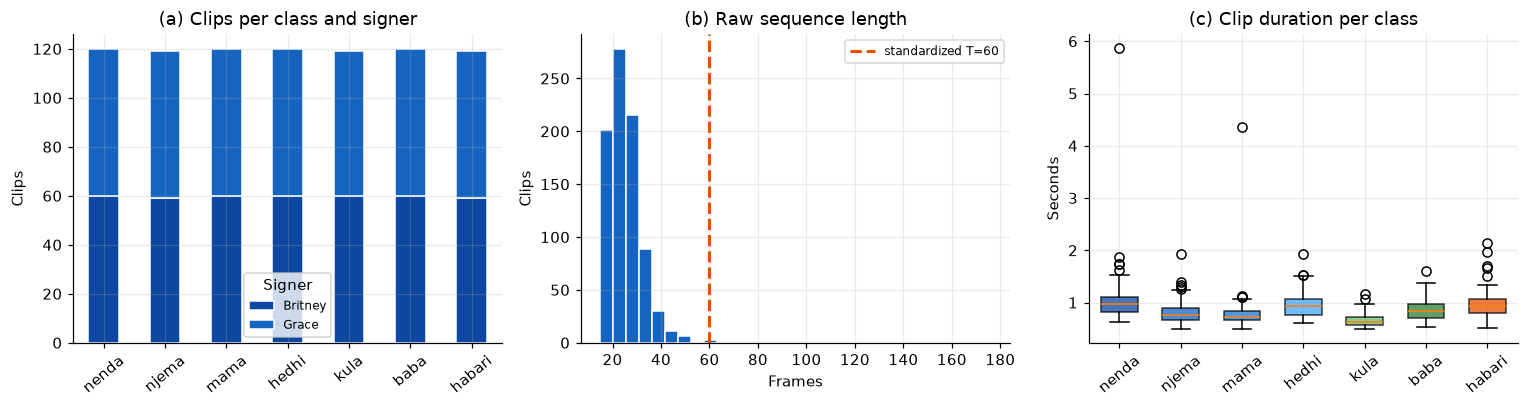

'fig_corpus_composition'

In [6]:
# --- Robust configurations fallbacks if Section 2 was skipped ---
BASE_DIR = Path('/Volumes/MacX/Sw').resolve() if os.path.exists('/Volumes/MacX/Sw') else Path.cwd()
OUT_DIR = globals().get('OUT_DIR', str(BASE_DIR / 'outputs'))
for d in (OUT_DIR, f'{OUT_DIR}/figures', f'{OUT_DIR}/tables'):
    os.makedirs(d, exist_ok=True)

def parse_signer(filename):
    """'Britney_002.mp4' -> 'Britney'. Adjust here if your naming convention differs."""
    stem = Path(filename).stem
    m = re.match(r'^([A-Za-z][A-Za-z\-]*)', stem)
    return m.group(1) if m else 'unknown'

def parse_take(filename):
    m = re.search(r'(\d+)', Path(filename).stem)
    return int(m.group(1)) if m else -1

detected = sorted(d.name for d in RAW_VIDEO_DIR.iterdir() if d.is_dir())
if CLASSES is None:
    CLASS_LIST = detected
    print(f'Auto-detected all {len(CLASS_LIST)} class folders.')
else:
    missing = [c for c in CLASSES if c not in detected]
    assert not missing, f'Configured classes are missing on disk: {missing}'
    CLASS_LIST = list(CLASSES)
    dropped = [d for d in detected if d not in CLASS_LIST]
    print(f'Using the {len(CLASS_LIST)} configured classes.'
          + (f'  Excluded from this study: {dropped}' if dropped else ''))

CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_LIST)}
N_CLASSES = len(CLASS_LIST)

# English glosses for the manuscript tables and the text-to-speech lookup.
GLOSS_EN = {'nenda': 'go', 'njema': 'good', 'mama': 'mother', 'hedhi': 'menstruation',
            'kula': 'eat', 'baba': 'father', 'habari': 'hi', 'siku': 'day'}

# ---- full archive inventory (every folder, every clip) -------------------
all_rows = []
for cls in detected:
    for f in sorted((RAW_VIDEO_DIR / cls).iterdir()):
        if f.suffix in VIDEO_EXT and not f.name.startswith('.'):
            all_rows.append({'path': str(f), 'label': cls, 'filename': f.name,
                             'signer': parse_signer(f.name), 'take': parse_take(f.name)})
archive = pd.DataFrame(all_rows)
assert len(archive), 'No video files found. Check RAW_VIDEO_DIR and VIDEO_EXT.'

arch_pivot = archive.pivot_table(index='label', columns='signer', values='filename',
                                 aggfunc='count', fill_value=0)
arch_pivot['Total'] = arch_pivot.sum(axis=1)
arch_pivot.loc['TOTAL'] = arch_pivot.sum(axis=0)
save_table(arch_pivot.reset_index(), 'table_archive_inventory_full',
           'Every clip present in the archive, by class and signer, before class selection '
           'or balancing. The audit trail for the study corpus below.', 'A6', float_fmt='%d')

# ---- probe every candidate clip for readability and recording properties ----
# Done BEFORE the balanced subsample so an unreadable file does not consume a slot.
print('\nProbing clip properties ...')
probe = []
for r in archive.itertuples():
    cap = cv2.VideoCapture(r.path)
    n   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 0.0
    w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    probe.append({'frames': n, 'fps': round(float(fps), 2),
                  'seconds': round(n / fps, 3) if fps else 0.0,
                  'width': w, 'height': h,
                  'readable': bool(n > 0 and w > 0 and h > 0)})
archive = pd.concat([archive.reset_index(drop=True), pd.DataFrame(probe)], axis=1)

unreadable = archive[~archive.readable]
if len(unreadable):
    save_table(unreadable[['label', 'signer', 'filename', 'frames', 'width', 'height']],
               'table_unreadable_clips',
               'Video files that report zero frames or zero resolution and therefore cannot '
               'contribute any landmarks. They are excluded here rather than silently '
               'producing all-zero sequences. Check whether these recordings still exist in '
               'usable form; if not, the corpus count in Section 3.2.3 must be reduced '
               'accordingly.', 'A6')
    print(f'! {len(unreadable)} unreadable clip(s) excluded before sampling.')
archive = archive[archive.readable].reset_index(drop=True)

# ---- recording-condition check against the manuscript's claims -------------
cond = archive.groupby('signer').agg(
    clips=('filename', 'count'),
    frame_rates=('fps', lambda s: ', '.join(f'{v:g}' for v in sorted(s.unique()))),
    resolutions=('width', lambda s: ''),
).reset_index()
cond['resolutions'] = [', '.join(sorted({f'{w}x{h}' for w, h in
                                         zip(archive[archive.signer == sg].width,
                                             archive[archive.signer == sg].height)}))
                       for sg in cond.signer]
for sg_i, sg in enumerate(cond.signer):
    sub = archive[archive.signer == sg]
    cond.loc[sg_i, 'frames_mean'] = round(float(sub.frames.mean()), 1)
    cond.loc[sg_i, 'frames_min_max'] = f'{int(sub.frames.min())}-{int(sub.frames.max())}'
    cond.loc[sg_i, 'seconds_mean'] = round(float(sub.seconds.mean()), 2)
cond.columns = ['Signer', 'Clips', 'Frame rate(s) found', 'Resolution(s) found',
                'Frames per clip (mean)', 'Frames per clip (min-max)',
                'Duration s (mean)']
save_table(cond, 'table_recording_conditions_measured',
    'MEASURED recording conditions per signer, against what Section 3.2.2 asserts. Read '
    'this carefully before revising: the manuscript states that every clip was recorded at '
    '30 fps, and states a raw sequence-length range of 15-300 frames. Whatever this table '
    'says is what the files contain. If more than one frame rate is present, the '
    'consequence must be stated, because a 60 fps clip covers half the real time of a '
    '30 fps clip over the same number of frames, and the temporal augmentation in Eq. (2) '
    'is defined in frames rather than in seconds.', 'A6, B6')

_fps_found = sorted(archive.fps.unique())
if len(_fps_found) > 1:
    print(f'\n! The corpus contains more than one frame rate: {_fps_found}.')
    print('  Section 3.2.2 claims 30 fps throughout. Correct it, and state that sequence')
    print('  length is standardized in FRAMES, so clips at different rates cover different')
    print('  real durations. table_recording_conditions_measured has the breakdown.')

# ---- study corpus: class selection, then balanced subsample -------------
inv = archive[archive.label.isin(CLASS_LIST)].copy()

if BALANCE_PER_SIGNER:
    rng = np.random.default_rng(BALANCE_SEED)
    keep, short = [], []
    for (cls, sig), grp in inv.groupby(['label', 'signer'], sort=True):
        grp = grp.sort_values('filename')
        if len(grp) < BALANCE_PER_SIGNER:
            short.append((cls, sig, len(grp)))
            keep.append(grp)
        else:
            sel = rng.choice(grp.index.values, size=BALANCE_PER_SIGNER, replace=False)
            keep.append(grp.loc[np.sort(sel)])
    inv = pd.concat(keep).sort_values(['label', 'signer', 'filename']).reset_index(drop=True)
    print(f'\nBalanced subsample: {BALANCE_PER_SIGNER} clips per class per signer '
          f'(seed {BALANCE_SEED}) -> {len(inv)} clips.')
    if short:
        print('  ! These class/signer cells had fewer clips than requested and were taken '
              'in full:')
        for c, s, n in short:
            print(f'      {c}/{s}: {n} of {BALANCE_PER_SIGNER}')
        print('  The corpus is therefore NOT perfectly balanced; §12 quantifies the residual '
              'imbalance and sets the class-weighting policy from it (Reviewer B comment 11).')
else:
    inv = inv.sort_values(['label', 'signer', 'filename']).reset_index(drop=True)
    print(f'\nUsing every clip of the selected classes: {len(inv)}.')

SIGNERS = sorted(inv.signer.unique())
print(f'Study corpus: {len(inv)} clips, {N_CLASSES} classes, '
      f'{len(SIGNERS)} signers {SIGNERS}')

# ---- manuscript Table 2 --------------------------------------------------
n_variants = 1 + len(AUG_STRETCH) + len(AUG_NOISE) + len(AUG_SHIFT)
t2 = []
for cls in CLASS_LIST:
    sub = inv[inv.label == cls]
    row = {'Class (SwSL gloss)': cls, 'English meaning': GLOSS_EN.get(cls, '')}
    for s in SIGNERS:
        row[f'Clips by {s}'] = int((sub.signer == s).sum())
    row['Raw clips'] = len(sub)
    t2.append(row)
tot = {'Class (SwSL gloss)': 'Total', 'English meaning': ''}
for s in SIGNERS:
    tot[f'Clips by {s}'] = int((inv.signer == s).sum())
tot['Raw clips'] = len(inv)
t2.append(tot)
save_table(pd.DataFrame(t2), 'table02_corpus_composition',
           'Manuscript Table 2. Gesture inventory and per-signer composition of the study '
           f'corpus. Augmented totals are NOT shown here on purpose: augmentation is applied '
           f'to the training partition only, so a per-class augmented total for the whole '
           f'corpus (as in the published Table 2) is not a quantity the pipeline produces. '
           f'The augmented counts appear per partition in table_split_and_augmentation.',
           'A6', float_fmt='%d')

# ---- clip properties: manuscript Table 3 --------------------------------
inv = inv.reset_index(drop=True)
inv['clip_id'] = inv.label + '__' + inv.filename.str.replace(r'\.\w+$', '', regex=True)

res_counts = Counter(f'{w}x{h}' for w, h in zip(inv.width, inv.height))
t3 = pd.DataFrame({'Attribute': [
        'Raw samples', 'Gesture classes', 'Signers', 'Recording rate (fps)',
        'Sequence length (raw frames)', 'Sequence length, mean +/- std',
        'Clip duration (s), mean +/- std', 'Clip duration (s), min-max',
        'Frame resolution(s)', 'Standardized length', 'Length standardization',
        'Per-frame features (primary)', 'Per-frame features (cached)',
        'Augmentation variants per training clip', 'Landmark quality threshold'],
    'Value': [
        f'{len(inv)} clips ({BALANCE_PER_SIGNER} per class per signer)' if BALANCE_PER_SIGNER
            else f'{len(inv)} clips (all validated clips of the selected classes)',
        f'{N_CLASSES} isolated SwSL gestures',
        f'{len(SIGNERS)} ({", ".join(SIGNERS)})',
        ', '.join(str(x) for x in sorted(inv.fps.unique())),
        f'{int(inv.frames.min())}-{int(inv.frames.max())}',
        f'{inv.frames.mean():.1f} +/- {inv.frames.std():.1f}',
        f'{inv.seconds.mean():.2f} +/- {inv.seconds.std():.2f}',
        f'{inv.seconds.min():.2f}-{inv.seconds.max():.2f}',
        ', '.join(f'{k} (n={v})' for k, v in res_counts.most_common()),
        f'{SEQ_LEN} frames',
        {'pad_truncate': 'zero-padding / truncation', 'resample':
         'uniform temporal resampling'}[LENGTH_MODE],
        f'{FEAT_DIM} ({POSE_DIM} pose + {HAND_DIM} left hand + {HAND_DIM} right hand)',
        f'{FULL_DIM} (primary + {FACE_DIM} face)' if INCLUDE_FACE else f'{FEAT_DIM}',
        f'{n_variants} (original + {len(AUG_STRETCH)} stretch + {len(AUG_NOISE)} noise + '
        f'{len(AUG_SHIFT)} shift)',
        f'>= {QUALITY_THRESHOLD:.0%} of frames with a pose detection']})
save_table(t3, 'table03_dataset_properties',
           'Manuscript Table 3. Corpus properties and preprocessing, measured from the files '
           'rather than transcribed from the recording protocol.', 'A6, B6')

# ---- what the manuscript claims against what the files contain -----------
_res_list = ', '.join(f'{k}' for k, _ in res_counts.most_common())
disc = pd.DataFrame([
    {'Stated in the manuscript': '840 validated clips (60 per class per signer)',
     'Section': '3.2.3, Table 2, Table 3',
     'Measured here': f'{len(inv)} clips',
     'Action': 'Use the measured count. If it is not 840, say why (see the balancing note '
               'and the unreadable-clip table).'},
    {'Stated in the manuscript': '7 gesture classes',
     'Section': 'throughout',
     'Measured here': f'{N_CLASSES} classes selected from {len(detected)} on disk '
                      f'({", ".join(detected)})',
     'Action': 'Confirm the published vocabulary matches CLASSES in Section 2.'},
    {'Stated in the manuscript': '30 fps throughout',
     'Section': '3.2.2, Table 3',
     'Measured here': ', '.join(f'{v:g} fps (n={int((inv.fps == v).sum())})'
                                for v in sorted(inv.fps.unique())),
     'Action': 'If more than one rate appears, correct Section 3.2.2 and state that '
               'sequence length is standardized in frames, not seconds.'},
    {'Stated in the manuscript': 'raw sequence length 15-300 frames',
     'Section': '3.3, Table 3',
     'Measured here': f'{int(inv.frames.min())}-{int(inv.frames.max())} frames '
                      f'(mean {inv.frames.mean():.1f})',
     'Action': 'Replace the range. If the mean is well below T = 60, most of the input '
               'window is padding and that should be stated, since it is what makes the '
               'masking layer load-bearing.'},
    {'Stated in the manuscript': 'augmented corpus of 5,880 samples',
     'Section': '3.4, Table 2, Table 3, 4.1',
     'Measured here': f'{n_variants} x (training partition only)',
     'Action': 'Replace with the per-partition counts; see '
               'table_split_and_augmentation (Reviewer A comment 6).'},
    {'Stated in the manuscript': 'iPhone 11 and iPhone 12 rear cameras, one per signer',
     'Section': '3.2.2',
     'Measured here': _res_list,
     'Action': 'Check that the number of distinct resolutions matches the number of '
               'devices claimed.'},
])
save_table(disc, 'table_manuscript_vs_measured',
           'Every quantitative claim in Sections 3.2-3.4 of the manuscript beside what the '
           'files actually contain. Work through this table first: each row is either a '
           'confirmation you can cite or a correction you have to make.', 'A6, B6')

inv.to_csv(f'{OUT_DIR}/tables/inventory_study_corpus.csv', index=False)
register('table', 'inventory_study_corpus', ['tables/inventory_study_corpus.csv'],
         'Clip-level manifest of the study corpus: path, class, signer, take, frame count, '
         'fps, duration, resolution.', 'A6, A14')

record('n_clips_raw', int(len(inv)), 'Section 3.2.3 and Table 3: raw clip count')
record('n_classes', N_CLASSES, 'everywhere the class count appears')
record('n_signers', len(SIGNERS), 'Section 3.2.1')
record('fps', float(inv.fps.mode().iloc[0]), 'Section 3.2.2')
record('frames_min', int(inv.frames.min()), 'Section 3.3 sequence-length range')
record('frames_max', int(inv.frames.max()), 'Section 3.3 sequence-length range')

# ---- corpus composition figure ------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
comp = inv.pivot_table(index='label', columns='signer', values='filename',
                       aggfunc='count', fill_value=0).reindex(CLASS_LIST)
comp.plot(kind='bar', stacked=True, ax=axes[0],
          color=C_SEQ[:len(SIGNERS)], edgecolor='white')
axes[0].set_title('(a) Clips per class and signer'); axes[0].set_xlabel('')
axes[0].set_ylabel('Clips'); axes[0].legend(title='Signer', fontsize=8)
axes[0].tick_params(axis='x', rotation=40)

axes[1].hist(inv.frames, bins=30, color=C_ALT, edgecolor='white')
axes[1].axvline(SEQ_LEN, color=C_WARN, ls='--', lw=2,
                label=f'standardized T={SEQ_LEN}')
axes[1].set_title('(b) Raw sequence length'); axes[1].set_xlabel('Frames')
axes[1].set_ylabel('Clips'); axes[1].legend(fontsize=8)

data = [inv[inv.label == c].seconds.values for c in CLASS_LIST]
bp = boxplot(axes[2], data, CLASS_LIST, patch_artist=True, widths=0.6)
for patch, col in zip(bp['boxes'], C_SEQ):
    patch.set_facecolor(col); patch.set_alpha(0.75)
axes[2].set_title('(c) Clip duration per class'); axes[2].set_ylabel('Seconds')
axes[2].tick_params(axis='x', rotation=40)
plt.tight_layout()
save_fig(fig, 'fig_corpus_composition',
         'Composition of the study corpus: (a) clips per class and signer, (b) distribution '
         'of raw sequence lengths against the standardized 60-frame window, (c) clip '
         'duration per class.', 'A6, B4')


## 5. Landmark extraction

Runs MediaPipe Holistic over every clip once. Three things matter here:

* **The cache is two-tier.** Per-clip `.npy` files go to local disk (fast); a single
  consolidated `landmarks_v1.npz` goes to Drive. If that archive exists and matches the
  current configuration, extraction is skipped entirely — so re-running this notebook in a
  fresh runtime costs seconds, not half an hour.
* **The face stream is cached even though the primary vector excludes it** (`INCLUDE_FACE`),
  which is what lets §19 *measure* the face-exclusion decision instead of arguing it
  (**Reviewer A comment 10**).
* **A per-clip detection-quality log is written**, which is the evidence behind the 90%
  quality threshold stated in Section 3.2.4 of the manuscript.

Roughly 1–3 s per clip. Safe to interrupt and re-run: completed clips are skipped.

Using native MediaPipe 0.10.21 with solutions.holistic


I0000 00:00:1790182150.572190 1121567 gl_context.cc:369] GL version: 2.1 (2.1 INTEL-24.5.8), renderer: Intel(R) UHD Graphics 630
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


W0000 00:00:1790182150.814873 1129741 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1790182150.887883 1129741 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1790182150.898598 1129740 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1790182150.899124 1129738 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1790182150.899512 1129742 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1790182150.917701 1129744 inference_feedback_manager.cc:114] Feedback manager 

MediaPipe 0.10.21 ready (native, Python 3.12.8).


Loaded 837 cached landmark sequences from
  /Volumes/MacX/Sw/SwSL_JCTA_Revision/landmarks_v1.npz
Skipping extraction.

--- table_landmark_detection_quality   [B6]
MediaPipe Holistic detection reliability per landmark stream over the study corpus. The pose row is
what the 90% acquisition threshold was applied to; the hand rows show how how often each manual
channel was actually recovered.


,Stream,Mean detection rate (%),Min over clips (%),Clips with zero detections
0,Pose (33 landmarks),100.00,100.00,0
1,Left hand (21),18.29,0.00,420
2,Right hand (21),19.27,0.00,222
3,At least one hand,25.25,0.00,182
4,Both hands,12.30,0.00,460
5,Face (468),99.75,64.29,0



Clips below the 0% pose-detection threshold: 0 of 837
Clips retained for modelling: 837 / 837


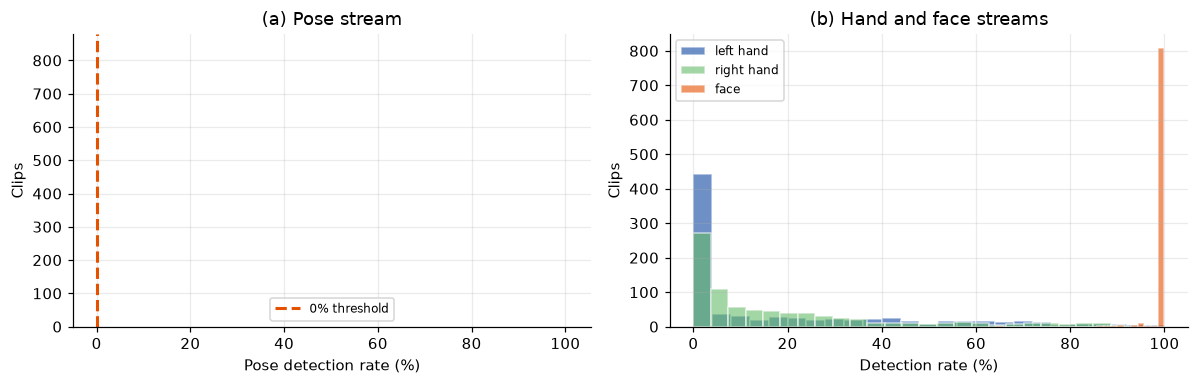

'fig_landmark_detection_quality'

In [7]:
import os, sys, json, math, time, struct, shutil, subprocess, tempfile, dataclasses, types
from typing import Mapping
import numpy as _np_boot

MP_VERSION   = '0.10.21'
MP_ENV_DIR   = '/content/mp312_env' if os.path.isdir('/content') else '/tmp/mp312_env'
MP_PY        = f'{MP_ENV_DIR}/bin/python'
MP_SCRIPT    = f'{MP_ENV_DIR}/mp_worker.py'
MP_CONSTS    = f'{MP_ENV_DIR}/constants.json'

_MP_WORKER_SRC = r'''
import os, sys, json, struct, time
if len(sys.argv) > 1 and sys.argv[1] == '--constants':
    import mediapipe as mp
    h = mp.solutions.holistic
    print(json.dumps({'version': mp.__version__, 'python': sys.version.split()[0],
                      'pose': sorted([int(a), int(b)] for a, b in h.POSE_CONNECTIONS),
                      'hand': sorted([int(a), int(b)] for a, b in h.HAND_CONNECTIONS)}))
    sys.exit(0)
_out = os.fdopen(os.dup(1), 'wb')
os.dup2(2, 1)                    # stray prints from libraries go to stderr, not the protocol pipe
_in = sys.stdin.buffer
import numpy as np
import mediapipe as mp
def _read(n):
    b = _in.read(n)
    if len(b) != n:
        raise EOFError
    return b
n = struct.unpack('<I', _read(4))[0]
cfg = json.loads(_read(n).decode())
try:
    hol = mp.solutions.holistic.Holistic(**cfg)
except Exception as e:
    msg = (type(e).__name__ + ': ' + str(e)).encode()
    _out.write(b'E' + struct.pack('<I', len(msg)) + msg); _out.flush(); sys.exit(1)
_out.write(b'K'); _out.flush()
while True:
    cmd = _in.read(1)
    if not cmd or cmd == b'Q':
        break
    hh, ww = struct.unpack('<II', _read(8))
    img = np.frombuffer(_read(hh * ww * 3), np.uint8).reshape(hh, ww, 3)
    t0 = time.perf_counter()
    res = hol.process(img)
    dt = (time.perf_counter() - t0) * 1000.0
    parts = [struct.pack('<f', dt)]
    for lms, k in ((res.pose_landmarks, 4), (res.left_hand_landmarks, 3),
                   (res.right_hand_landmarks, 3), (res.face_landmarks, 3)):
        if lms is None:
            parts.append(struct.pack('<I', 0))
        else:
            arr = np.array([[p.x, p.y, p.z, p.visibility][:k] for p in lms.landmark], np.float32)
            parts.append(struct.pack('<I', len(arr))); parts.append(arr.tobytes())
    _out.write(b''.join(parts)); _out.flush()
hol.close()
'''

def _mp_env_healthy():
    if not (os.path.exists(MP_PY) and os.path.exists(MP_CONSTS)):
        return False
    r = subprocess.run([MP_PY, '-c',
                        f'import mediapipe as m; assert m.__version__=="""" and hasattr(m,"solutions")'],
                       capture_output=True, text=True)
    return r.returncode == 0

def _mp_build_env():
    print(f'Creating the isolated MediaPipe {MP_VERSION} environment (one-time, about a minute) ...')
    def run(cmd, what):
        r = subprocess.run(cmd, capture_output=True, text=True)
        if r.returncode != 0:
            raise RuntimeError(f'{what} failed:\n{(r.stdout + r.stderr)[-1500:]}')
    if subprocess.run([sys.executable, '-m', 'uv', '--version'], capture_output=True).returncode != 0:
        run([sys.executable, '-m', 'pip', 'install', '-q', 'uv'], 'installing uv')
    uv = [sys.executable, '-m', 'uv']
    shutil.rmtree(MP_ENV_DIR, ignore_errors=True)
    run(uv + ['venv', '--python', '3.12', MP_ENV_DIR], 'creating the Python 3.12 environment')
    run(uv + ['pip', 'install', '-q', '--python', MP_PY, 'numpy<2', 'protobuf>=4.25.3,<5',
              'opencv-python-headless', 'matplotlib', 'absl-py', 'attrs', 'flatbuffers'],
        'installing the MediaPipe dependencies')
    run(uv + ['pip', 'install', '-q', '--no-deps', '--python', MP_PY, f'mediapipe=={MP_VERSION}'],
        f'installing mediapipe=={MP_VERSION}')
    with open(MP_SCRIPT, 'w') as f:
        f.write(_MP_WORKER_SRC)

    # Unset MPLBACKEND for the subprocess to prevent backend conflicts
    env_for_subprocess = os.environ.copy()
    if 'MPLBACKEND' in env_for_subprocess:
        del env_for_subprocess['MPLBACKEND']

    r = subprocess.run([MP_PY, MP_SCRIPT, '--constants'], capture_output=True, text=True, env=env_for_subprocess)

    if r.returncode != 0:
        raise RuntimeError(f'MediaPipe worker could not start:\n{r.stderr[-1500:]}')
    with open(MP_CONSTS, 'w') as f:
        f.write(r.stdout)

_USE_NATIVE_MP = False
try:
    import mediapipe as _mp_test
    if hasattr(_mp_test, 'solutions') and hasattr(_mp_test.solutions, 'holistic'):
        _USE_NATIVE_MP = True
        print(f'Using native MediaPipe {_mp_test.__version__} with solutions.holistic')
except Exception:
    _USE_NATIVE_MP = False

if not _USE_NATIVE_MP:
    if not _mp_env_healthy():
        _mp_build_env()
    with open(MP_SCRIPT, 'w') as _f:          # always refresh the worker script
        _f.write(_MP_WORKER_SRC)
    _MP_CONST = json.load(open(MP_CONSTS))

# ------------------------------------------------ stand-in for mp.solutions.holistic
class _Lm:
    __slots__ = ('x', 'y', 'z', 'visibility')
    def __init__(self, x, y, z, visibility=None):
        self.x, self.y, self.z, self.visibility = x, y, z, visibility

class _LmList:
    """Mimics a NormalizedLandmarkList: iterate `.landmark`, each with x, y, z (and visibility)."""
    __slots__ = ('landmark',)
    def __init__(self, arr):
        has_vis = arr.shape[1] == 4
        self.landmark = [_Lm(r[0], r[1], r[2], r[3] if has_vis else None) for r in arr.tolist()]

class _HolisticResult:
    __slots__ = ('pose_landmarks', 'left_hand_landmarks', 'right_hand_landmarks',
                 'face_landmarks', 'pose_world_landmarks', 'segmentation_mask')
    def __init__(self):
        for k in self.__slots__:
            setattr(self, k, None)

class _LegacyHolistic:
    """Drop-in for mp.solutions.holistic.Holistic, running in the isolated worker process."""
    def __init__(self, static_image_mode=False, model_complexity=1, smooth_landmarks=True,
                 enable_segmentation=False, smooth_segmentation=True,
                 refine_face_landmarks=False, min_detection_confidence=0.5,
                 min_tracking_confidence=0.5):
        cfg = dict(static_image_mode=bool(static_image_mode), model_complexity=int(model_complexity),
                   smooth_landmarks=bool(smooth_landmarks), enable_segmentation=bool(enable_segmentation),
                   smooth_segmentation=bool(smooth_segmentation),
                   refine_face_landmarks=bool(refine_face_landmarks),
                   min_detection_confidence=float(min_detection_confidence),
                   min_tracking_confidence=float(min_tracking_confidence))
        self.last_compute_ms = None
        self._err = tempfile.TemporaryFile()

        # Unset MPLBACKEND for the subprocess to prevent backend conflicts
        env_for_subprocess = os.environ.copy()
        if 'MPLBACKEND' in env_for_subprocess:
            del env_for_subprocess['MPLBACKEND']
        self._p = subprocess.Popen([MP_PY, MP_SCRIPT], stdin=subprocess.PIPE,
                                   stdout=subprocess.PIPE, stderr=self._err, env=env_for_subprocess)

        payload = json.dumps(cfg).encode()
        self._p.stdin.write(struct.pack('<I', len(payload)) + payload)
        self._p.stdin.flush()
        tag = self._p.stdout.read(1)
        if tag != b'K':
            detail = ''
            if tag == b'E':
                detail = self._p.stdout.read(struct.unpack('<I', self._p.stdout.read(4))[0]).decode()
            raise RuntimeError(f'MediaPipe worker failed to start: {detail or self._stderr_tail()}')

    def _stderr_tail(self):
        try:
            self._err.seek(0); return self._err.read()[-1200:].decode(errors='replace')
        except Exception:
            return ''

    def _read(self, n):
        b = self._p.stdout.read(n)
        if len(b) != n:
            raise RuntimeError('MediaPipe worker process died.\n' + self._stderr_tail())
        return b

    def process(self, image):
        img = _np_boot.ascontiguousarray(image, dtype=_np_boot.uint8)
        h, w = img.shape[:2]
        self._p.stdin.write(b'P' + struct.pack('<II', h, w) + img.tobytes())
        self._p.stdin.flush()
        self.last_compute_ms = struct.unpack('<f', self._read(4))[0]
        res = _HolisticResult()
        for name, k in (('pose_landmarks', 4), ('left_hand_landmarks', 3),
                        ('right_hand_landmarks', 3), ('face_landmarks', 3)):
            n = struct.unpack('<I', self._read(4))[0]
            if n:
                arr = _np_boot.frombuffer(self._read(n * k * 4), _np_boot.float32).reshape(n, k)
                setattr(res, name, _LmList(arr))
        return res

    def close(self):
        p = getattr(self, '_p', None)
        if p is not None and p.poll() is None:
            try:
                p.stdin.write(b'Q'); p.stdin.flush(); p.wait(timeout=5)
            except Exception:
                p.kill()
        try:
            self._err.close()
        except Exception:
            pass
    def __enter__(self): return self
    def __exit__(self, *a): self.close()
    def __del__(self):
        try: self.close()
        except Exception: pass

# ------------------------------------------------ stand-in for mp.solutions.drawing_utils
# (draw_landmarks is MediaPipe 0.10.21's own logic, adapted to the stand-in landmark objects)
WHITE_COLOR = (224, 224, 224)
@dataclasses.dataclass
class DrawingSpec:
    color: tuple = WHITE_COLOR
    thickness: int = 2
    circle_radius: int = 2

def _norm_to_px(nx, ny, w, h):
    ok = lambda v: (v > 0 or math.isclose(0, v)) and (v < 1 or math.isclose(1, v))
    if not (ok(nx) and ok(ny)):
        return None
    return min(math.floor(nx * w), w - 1), min(math.floor(ny * h), h - 1)

def draw_landmarks(image, landmark_list, connections=None,
                   landmark_drawing_spec=DrawingSpec(color=(0, 0, 255)),
                   connection_drawing_spec=DrawingSpec(), is_drawing_landmarks=True):
    import cv2
    if not landmark_list:
        return
    if image.shape[2] != 3:
        raise ValueError('Input image must contain three channel bgr data.')
    rows, cols, _ = image.shape
    pts = {}
    for idx, lm in enumerate(landmark_list.landmark):
        if lm.visibility is not None and lm.visibility < 0.5:
            continue
        px = _norm_to_px(lm.x, lm.y, cols, rows)
        if px:
            pts[idx] = px
    if connections:
        n = len(landmark_list.landmark)
        for a, b in connections:
            if not (0 <= a < n and 0 <= b < n):
                raise ValueError(f'Landmark index is out of range. Invalid connection from #{a} to #{b}.')
            if a in pts and b in pts:
                spec = connection_drawing_spec[(a, b)] if isinstance(connection_drawing_spec, Mapping) else connection_drawing_spec
                cv2.line(image, pts[a], pts[b], spec.color, spec.thickness)
    if is_drawing_landmarks and landmark_drawing_spec:
        for idx, px in pts.items():
            spec = landmark_drawing_spec[idx] if isinstance(landmark_drawing_spec, Mapping) else landmark_drawing_spec
            border = max(spec.circle_radius + 1, int(spec.circle_radius * 1.2))
            cv2.circle(image, px, border, WHITE_COLOR, spec.thickness)
            cv2.circle(image, px, spec.circle_radius, spec.color, spec.thickness)

if _USE_NATIVE_MP:
    mp_holistic = mp.solutions.holistic
    mp_drawing  = mp.solutions.drawing_utils
else:
    mp_holistic = types.SimpleNamespace(
        Holistic=_LegacyHolistic,
        POSE_CONNECTIONS=frozenset(tuple(c) for c in _MP_CONST['pose']),
        HAND_CONNECTIONS=frozenset(tuple(c) for c in _MP_CONST['hand']))
    mp_drawing = types.SimpleNamespace(DrawingSpec=DrawingSpec, draw_landmarks=draw_landmarks)

# Self-test: start a worker, push one blank frame through it, shut it down.
with mp_holistic.Holistic(static_image_mode=True, model_complexity=1) as _h:
    _h.process(_np_boot.zeros((64, 64, 3), _np_boot.uint8))
if 'ENV' in globals():                          # keep the recorded environment truthful
    ENV['mediapipe'] = mp.__version__ if _USE_NATIVE_MP else _MP_CONST['version']
    ENV['mediapipe_worker_python'] = sys.version.split()[0] if _USE_NATIVE_MP else _MP_CONST['python']
if _USE_NATIVE_MP:
    print(f"MediaPipe {mp.__version__} ready (native, Python {sys.version.split()[0]}).")
else:
    print(f"MediaPipe {_MP_CONST['version']} ready (isolated worker, Python {_MP_CONST['python']}; "
          f"this notebook runs Python {sys.version.split()[0]}).")

LANDMARK_ARCHIVE = f'{PROJECT_DIR}/landmarks_v1.npz'
ARCHIVE_SIG = {
    'include_face': INCLUDE_FACE, 'full_dim': FULL_DIM,
    'min_det': MIN_DET_CONF, 'min_trk': MIN_TRK_CONF,
    'model_complexity': MODEL_COMPLEXITY, 'version': 1,
}
N_EXTRACT_WORKERS = min(4, max(1, (os.cpu_count() or 2)))

def _frame_vector(res):
    """One MediaPipe result -> the cached per-frame vector, with hit flags."""
    if res.pose_landmarks:
        pose = np.array([[p.x, p.y, p.z, p.visibility]
                         for p in res.pose_landmarks.landmark], np.float32).ravel()
        pose_hit = 1
    else:
        pose, pose_hit = np.zeros(POSE_DIM, np.float32), 0

    if res.left_hand_landmarks:
        lh = np.array([[p.x, p.y, p.z]
                       for p in res.left_hand_landmarks.landmark], np.float32).ravel()
        lh_hit = 1
    else:
        lh, lh_hit = np.zeros(HAND_DIM, np.float32), 0

    if res.right_hand_landmarks:
        rh = np.array([[p.x, p.y, p.z]
                       for p in res.right_hand_landmarks.landmark], np.float32).ravel()
        rh_hit = 1
    else:
        rh, rh_hit = np.zeros(HAND_DIM, np.float32), 0

    parts = [pose, lh, rh]
    face_hit = 0
    if INCLUDE_FACE:
        if res.face_landmarks:
            fc = np.array([[p.x, p.y, p.z]
                           for p in res.face_landmarks.landmark], np.float32).ravel()
            face_hit = 1
            if fc.size != FACE_DIM:          # refine_face_landmarks would give 478
                fc = np.resize(fc, FACE_DIM)
        else:
            fc = np.zeros(FACE_DIM, np.float32)
        parts.append(fc)
    return np.concatenate(parts), pose_hit, lh_hit, rh_hit, face_hit

def extract_clip(video_path, holistic):
    """Full landmark sequence for one clip, plus its detection-quality record."""
    cap = cv2.VideoCapture(str(video_path))
    frames, hits = [], np.zeros(4, np.int64)
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        rgb.flags.writeable = False
        vec, p, l, r, f = _frame_vector(holistic.process(rgb))
        frames.append(vec)
        hits += (p, l, r, f)
    cap.release()
    seq = (np.stack(frames).astype(np.float32) if frames
           else np.zeros((0, FULL_DIM), np.float32))
    n = max(len(frames), 1)
    q = {'n_frames': int(len(frames)),
         'pose_rate': float(hits[0] / n), 'lh_rate': float(hits[1] / n),
         'rh_rate': float(hits[2] / n),   'face_rate': float(hits[3] / n),
         'any_hand_rate': float(max(hits[1], hits[2]) / n),
         'both_hand_rate': float(min(hits[1], hits[2]) / n)}
    return seq, q

def _worker(args):
    """One process handles a slice of the clip list with its own Holistic instance."""
    rows = args
    out = []
    with mp_holistic.Holistic(static_image_mode=False,
                              model_complexity=MODEL_COMPLEXITY,
                              refine_face_landmarks=False,
                              smooth_landmarks=True,
                              min_detection_confidence=MIN_DET_CONF,
                              min_tracking_confidence=MIN_TRK_CONF) as h:
        for clip_id, path in rows:
            cf = Path(CACHE_DIR) / f'{clip_id}.npy'
            mf = cf.with_suffix('.json')
            if cf.exists() and mf.exists():
                out.append((clip_id, None, json.load(open(mf))))
                continue
            seq, q = extract_clip(path, h)
            np.save(cf, seq)
            json.dump(q, open(mf, 'w'))
            out.append((clip_id, None, q))
    return out

# ----------------------------------------------------------------- load or extract
SEQS, QUAL = {}, {}
archive_ok = False
if os.path.exists(LANDMARK_ARCHIVE) and not FORCE_RETRAIN:
    try:
        z = np.load(LANDMARK_ARCHIVE, allow_pickle=True)
        sig = json.loads(str(z['signature']))
        if sig == ARCHIVE_SIG:
            ids = [str(x) for x in z['clip_ids']]
            flat, off = z['frames'], z['offsets']
            qrec = json.loads(str(z['quality']))
            for k, cid in enumerate(ids):
                SEQS[cid] = flat[off[k]:off[k + 1]]
                QUAL[cid] = qrec[cid]
            missing = [c for c in inv.clip_id if c not in SEQS]
            if not missing:
                archive_ok = True
                print(f'Loaded {len(SEQS)} cached landmark sequences from\n  '
                      f'{LANDMARK_ARCHIVE}\nSkipping extraction.')
            else:
                print(f'Drive archive is missing {len(missing)} clips of this corpus; '
                      f'extracting those.')
        else:
            print('Drive archive was produced with a different extraction configuration; '
                  're-extracting.')
            print(f'  cached : {sig}\n  current: {ARCHIVE_SIG}')
            SEQS, QUAL = {}, {}
    except Exception as e:
        print(f'Could not read the Drive archive ({e}); extracting from video.')
        SEQS, QUAL = {}, {}

if not archive_ok:
    todo = [(r.clip_id, r.path) for r in inv.itertuples() if r.clip_id not in SEQS]
    print(f'\nExtracting landmarks for {len(todo)} clips '
          f'({N_EXTRACT_WORKERS} worker(s)) ...')
    t0 = time.time()
    results = []
    if sys.platform != 'darwin' and N_EXTRACT_WORKERS > 1 and len(todo) > 8:
        try:
            import multiprocessing as mpp
            chunks = [todo[i::N_EXTRACT_WORKERS] for i in range(N_EXTRACT_WORKERS)]
            with mpp.get_context('fork').Pool(N_EXTRACT_WORKERS) as pool:
                for part in pool.imap_unordered(_worker, chunks):
                    results += part
                    print(f'  {len(results)}/{len(todo)}  ({time.time()-t0:.0f}s)')
        except Exception as e:
            print(f'  parallel extraction unavailable ({type(e).__name__}: {e}); '
                  f'falling back to a single process.')
            results = []
    if not results:
        with mp_holistic.Holistic(static_image_mode=False,
                                  model_complexity=MODEL_COMPLEXITY,
                                  refine_face_landmarks=False, smooth_landmarks=True,
                                  min_detection_confidence=MIN_DET_CONF,
                                  min_tracking_confidence=MIN_TRK_CONF) as h:
            for k, (cid, path) in enumerate(todo):
                cf = Path(CACHE_DIR) / f'{cid}.npy'
                mf = cf.with_suffix('.json')
                if cf.exists() and mf.exists():
                    q = json.load(open(mf))
                else:
                    seq, q = extract_clip(path, h)
                    np.save(cf, seq)
                    json.dump(q, open(mf, 'w'))
                results.append((cid, None, q))
                if (k + 1) % 25 == 0 or k + 1 == len(todo):
                    el = time.time() - t0
                    print(f'  {k+1}/{len(todo)}  ({el:.0f}s, '
                          f'{el/(k+1):.2f}s per clip, '
                          f'ETA {el/(k+1)*(len(todo)-k-1)/60:.1f} min)')
    for cid, _, q in results:
        QUAL[cid] = q
        SEQS[cid] = np.load(Path(CACHE_DIR) / f'{cid}.npy')
    print(f'\nExtraction finished in {(time.time()-t0)/60:.1f} min')

    # ---- consolidate to a single Drive archive ---------------------------
    ids = list(inv.clip_id)
    lens = [len(SEQS[c]) for c in ids]
    offsets = np.concatenate([[0], np.cumsum(lens)]).astype(np.int64)
    if sum(lens):
        flat = np.concatenate([SEQS[c] for c in ids]).astype(np.float32)
    else:
        flat = np.zeros((0, FULL_DIM), np.float32)
    print(f'Writing consolidated archive ({flat.nbytes/1e6:.0f} MB) to Drive ...')
    np.savez(LANDMARK_ARCHIVE, frames=flat, offsets=offsets,
             clip_ids=np.array(ids, dtype=object),
             quality=json.dumps({c: QUAL[c] for c in ids}),
             signature=json.dumps(ARCHIVE_SIG))
    del flat
    gc.collect()
    print(f'  -> {LANDMARK_ARCHIVE}')

# ----------------------------------------------------------------- quality log
qdf = inv[['clip_id', 'label', 'signer', 'filename', 'frames']].copy()
for col in ('n_frames', 'pose_rate', 'lh_rate', 'rh_rate', 'face_rate',
            'any_hand_rate', 'both_hand_rate'):
    qdf[col] = [QUAL[c][col] for c in qdf.clip_id]
qdf.to_csv(f'{OUT_DIR}/tables/landmark_quality_log.csv', index=False)
register('table', 'landmark_quality_log', ['tables/landmark_quality_log.csv'],
         'Per-clip MediaPipe detection rates for pose, each hand and the face stream. '
         'Evidence behind the 90% landmark-quality threshold in Section 3.2.4.', 'B6')

qsum = pd.DataFrame({
    'Stream': ['Pose (33 landmarks)', 'Left hand (21)', 'Right hand (21)',
               'At least one hand', 'Both hands', 'Face (468)'],
    'Mean detection rate (%)': [round(qdf[c].mean() * 100, 2) for c in
        ('pose_rate', 'lh_rate', 'rh_rate', 'any_hand_rate', 'both_hand_rate', 'face_rate')],
    'Min over clips (%)': [round(qdf[c].min() * 100, 2) for c in
        ('pose_rate', 'lh_rate', 'rh_rate', 'any_hand_rate', 'both_hand_rate', 'face_rate')],
    'Clips with zero detections': [int((qdf[c] == 0).sum()) for c in
        ('pose_rate', 'lh_rate', 'rh_rate', 'any_hand_rate', 'both_hand_rate', 'face_rate')],
})
save_table(qsum, 'table_landmark_detection_quality',
           'MediaPipe Holistic detection reliability per landmark stream over the study '
           'corpus. The pose row is what the 90% acquisition threshold was applied to; the '
           'hand rows show how how often each manual channel was actually recovered.', 'B6')

below = qdf[qdf.pose_rate < QUALITY_THRESHOLD]
print(f'\nClips below the {QUALITY_THRESHOLD:.0%} pose-detection threshold: '
      f'{len(below)} of {len(qdf)}')
if len(below):
    save_table(below[['label', 'signer', 'filename', 'pose_rate', 'any_hand_rate']],
               'table_clips_below_quality_threshold',
               'Clips that fall below the stated 90% pose-detection threshold. The '
               'manuscript says sub-threshold clips were re-recorded rather than dropped; '
               'these are the clips that assertion has to cover.', 'B6')
kept_ids = qdf[qdf.pose_rate >= QUALITY_THRESHOLD].clip_id.tolist()
inv_kept = inv[inv.clip_id.isin(kept_ids)].reset_index(drop=True)
print(f'Clips retained for modelling: {len(inv_kept)} / {len(inv)}')
record('n_clips_retained', int(len(inv_kept)),
       'Section 3.2.4: clips passing the 90% landmark-quality threshold')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(qdf.pose_rate * 100, bins=25, color=C_ALT, edgecolor='white')
axes[0].axvline(QUALITY_THRESHOLD * 100, color=C_WARN, ls='--', lw=2,
                label=f'{QUALITY_THRESHOLD:.0%} threshold')
axes[0].set_xlabel('Pose detection rate (%)'); axes[0].set_ylabel('Clips')
axes[0].set_title('(a) Pose stream'); axes[0].legend(fontsize=8)
for c, lab, col in [('lh_rate', 'left hand', C_SEQ[0]), ('rh_rate', 'right hand', C_SEQ[4]),
                    ('face_rate', 'face', C_SEQ[6])]:
    axes[1].hist(qdf[c] * 100, bins=25, alpha=0.6, label=lab, color=col, edgecolor='white')
axes[1].set_xlabel('Detection rate (%)'); axes[1].set_ylabel('Clips')
axes[1].set_title('(b) Hand and face streams'); axes[1].legend(fontsize=8)
plt.tight_layout()
save_fig(fig, 'fig_landmark_detection_quality',
         'Distribution of MediaPipe detection rates over the corpus, per landmark stream.',
         'B6')


## 6. Qualitative corpus figures — manuscript Figure 2

Two figures regenerated from the corpus itself: a temporally ordered frame montage showing
the preparation / stroke / retraction phases of a sign, and the same frames with the
MediaPipe skeleton overlaid. The second one makes the representation concrete, which is
half of what **Reviewer B comment 5** asks for; §27 supplies the schematic half.

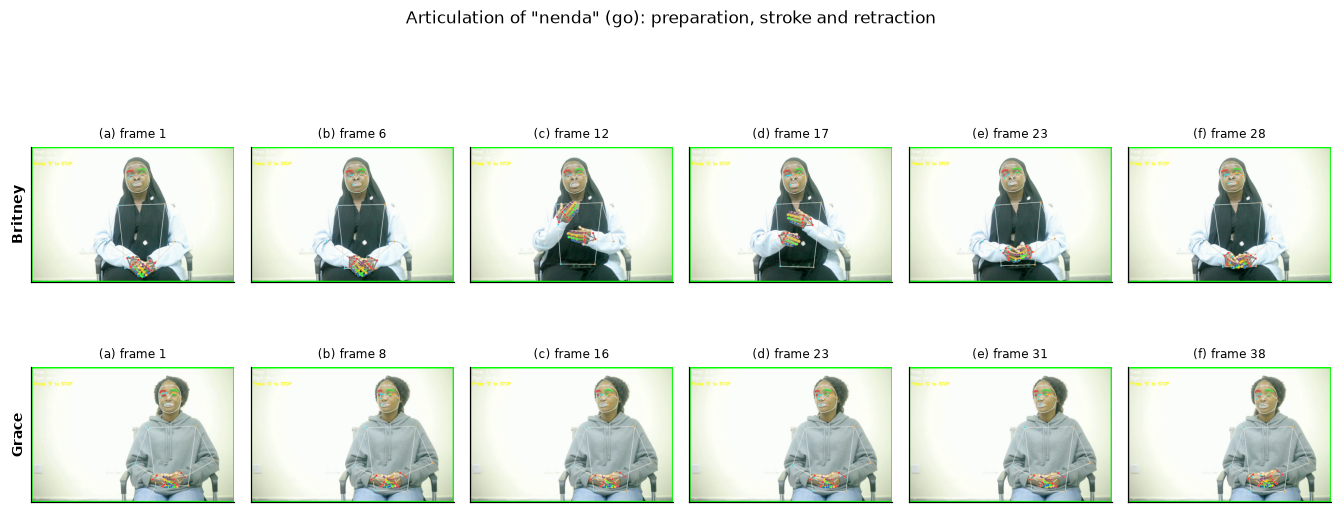

I0000 00:00:1790182168.573318 1121567 gl_context.cc:369] GL version: 2.1 (2.1 INTEL-24.5.8), renderer: Intel(R) UHD Graphics 630


W0000 00:00:1790182168.778926 1130098 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1790182168.843578 1130104 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1790182168.852125 1130102 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1790182168.852310 1130099 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1790182168.855928 1130101 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1790182168.874344 1130101 inference_feedback_manager.cc:114] Feedback manager 

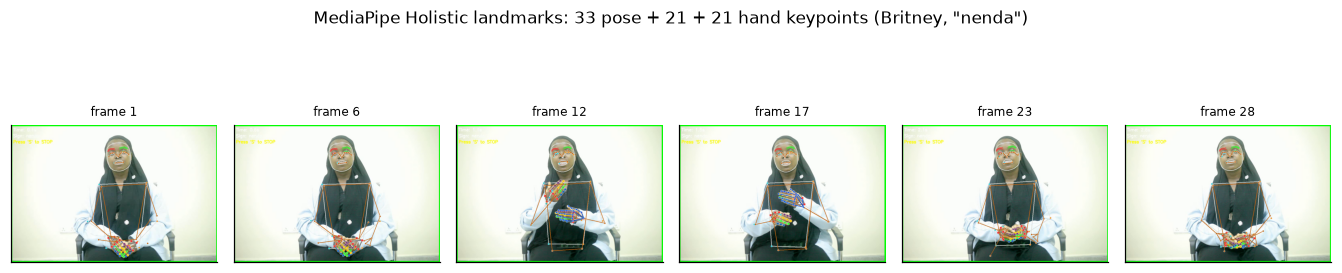

In [8]:
MONTAGE_CLASS  = CLASS_LIST[0]
MONTAGE_PANELS = 6

def read_frames(path, max_frames=400):
    cap = cv2.VideoCapture(str(path))
    out = []
    while len(out) < max_frames:
        ok, fr = cap.read()
        if not ok:
            break
        out.append(fr)
    cap.release()
    return out

demo = {}
for s in SIGNERS[:2]:
    sub = inv_kept[(inv_kept.label == MONTAGE_CLASS) & (inv_kept.signer == s)]
    if len(sub):
        demo[s] = sub.iloc[0]

if demo:
    fig, axes = plt.subplots(len(demo), MONTAGE_PANELS,
                             figsize=(2.05 * MONTAGE_PANELS, 2.6 * len(demo)))
    axes = np.atleast_2d(axes)
    for r, (sig, row) in enumerate(demo.items()):
        frames = read_frames(row.path)
        idx = np.linspace(0, len(frames) - 1, MONTAGE_PANELS).round().astype(int)
        for c, fi in enumerate(idx):
            ax = axes[r, c]
            ax.imshow(cv2.cvtColor(frames[fi], cv2.COLOR_BGR2RGB))
            ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
            ax.set_title(f'({chr(97+c)}) frame {fi+1}', fontsize=8)
            if c == 0:
                ax.set_ylabel(f'{sig}', fontsize=9, fontweight='bold')
    fig.suptitle(f'Articulation of "{MONTAGE_CLASS}" ({GLOSS_EN.get(MONTAGE_CLASS, "")}): '
                 f'preparation, stroke and retraction', fontsize=11, y=1.02)
    plt.tight_layout()
    save_fig(fig, 'fig02_representative_frames',
             'Manuscript Figure 2. Temporally ordered frames of one gesture from each '
             'signer, sampled uniformly across the clip, showing the preparation, stroke '
             'and retraction phases under the recording geometry of Section 3.2.2.', 'B4')

    # ---- the same frames with the skeleton overlaid ---------------------
    sig0, row0 = next(iter(demo.items()))
    frames = read_frames(row0.path)
    idx = np.linspace(0, len(frames) - 1, MONTAGE_PANELS).round().astype(int)
    style_pose = mp_drawing.DrawingSpec(color=(21, 101, 192), thickness=2, circle_radius=2)
    style_hand = mp_drawing.DrawingSpec(color=(230, 81, 0), thickness=2, circle_radius=2)
    fig, axes = plt.subplots(1, MONTAGE_PANELS, figsize=(2.05 * MONTAGE_PANELS, 2.8))
    with mp_holistic.Holistic(static_image_mode=True, model_complexity=MODEL_COMPLEXITY,
                              min_detection_confidence=MIN_DET_CONF) as h:
        for ax, fi in zip(np.atleast_1d(axes), idx):
            img = frames[fi].copy()
            res = h.process(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            if res.pose_landmarks:
                mp_drawing.draw_landmarks(img, res.pose_landmarks,
                                          mp_holistic.POSE_CONNECTIONS, style_pose, style_pose)
            for lm in (res.left_hand_landmarks, res.right_hand_landmarks):
                if lm:
                    mp_drawing.draw_landmarks(img, lm, mp_holistic.HAND_CONNECTIONS,
                                              style_hand, style_hand)
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
            ax.set_title(f'frame {fi+1}', fontsize=8)
    fig.suptitle(f'MediaPipe Holistic landmarks: 33 pose + 21 + 21 hand keypoints '
                 f'({sig0}, "{MONTAGE_CLASS}")', fontsize=11, y=1.04)
    plt.tight_layout()
    save_fig(fig, 'fig_landmark_overlay',
             'The 33 pose and 2 x 21 hand landmarks that form the 258-dimensional feature '
             'vector, overlaid on the source frames. Makes the input representation '
             'concrete.', 'B5')
else:
    print(f'No clips of class {MONTAGE_CLASS} available for the montage.')

## 7. Sequence standardization and normalization — **Reviewer B comment 6**

The reviewer objects that "extrema over the frame" is ambiguous, and that this matters for
reproducibility because preprocessing changes results. Four schemes are therefore defined
precisely, and §19 measures all four so the choice is justified empirically rather than
declared:

| Scheme | Scope of `x_min`, `x_max` | Leakage |
|---|---|---|
| `train_stats` *(default)* | per coordinate dimension, over all non-padded frames of the **training split only** | none — statistics never see validation or test |
| `per_sequence` | per coordinate dimension, within each clip | none |
| `per_frame` | within each frame, across its coordinate dimensions | none — this is what the current Eq. (1) wording implies |
| `body_anchored` | no min–max: translate to the mid-shoulder origin and divide by shoulder width | none |

`train_stats` is the default because it is the only one of the four that is both a fixed,
publishable transform (the constants can be released with the model) and free of
test-set information. Whichever is selected is written to `config.json`.

In [9]:
def standardize_length(seq, T=SEQ_LEN, mode=LENGTH_MODE):
    """Variable-length landmark sequence -> fixed (T, D). Zero rows mark padding."""
    D = seq.shape[1] if seq.ndim > 1 else FULL_DIM
    if len(seq) == 0:
        return np.zeros((T, D), np.float32)
    if mode == 'resample':
        idx = np.linspace(0, len(seq) - 1, T).round().astype(int)
        return seq[idx].astype(np.float32)
    if len(seq) >= T:
        return seq[:T].astype(np.float32)
    return np.concatenate([seq, np.zeros((T - len(seq), D), np.float32)]).astype(np.float32)

def _blocks(dim):
    """Byte-offset layout of the cached vector, as (offset, size, n_coords) triples."""
    out = [(0, POSE_DIM, 4), (POSE_DIM, HAND_DIM, 3), (POSE_DIM + HAND_DIM, HAND_DIM, 3)]
    if dim > FEAT_DIM:
        out.append((FEAT_DIM, dim - FEAT_DIM, 3))
    return out

L_SH, R_SH = 11, 12                      # MediaPipe pose landmark indices

def body_anchor(seq):
    """Translate every landmark to the mid-shoulder origin, scale by shoulder width."""
    out = seq.copy()
    for t in range(len(out)):
        px = out[t, :POSE_DIM].reshape(33, 4)
        if not np.any(px[:, :3]):
            continue
        mid   = (px[L_SH, :3] + px[R_SH, :3]) / 2.0
        width = float(np.linalg.norm(px[L_SH, :2] - px[R_SH, :2])) or 1.0
        px[:, :3] = (px[:, :3] - mid) / width
        out[t, :POSE_DIM] = px.ravel()
        for off, size, nc in _blocks(out.shape[1])[1:]:
            blk = out[t, off:off + size].reshape(-1, nc)
            if np.any(blk):
                out[t, off:off + size] = ((blk - mid[:nc]) / width).ravel()
    return out

class Normalizer:
    """Min-max normalizer with an explicitly scoped fit. See the table above."""

    def __init__(self, mode=NORMALIZATION):
        self.mode = mode
        self.min_ = self.max_ = self.range_ = None

    def fit(self, X_train):
        if self.mode == 'train_stats':
            flat = X_train.reshape(-1, X_train.shape[-1])
            live = np.any(flat != 0, axis=1)          # drop padded / undetected frames
            flat = flat[live] if live.any() else flat
            self.min_ = flat.min(axis=0)
            self.max_ = flat.max(axis=0)
            rng = (self.max_ - self.min_).astype(np.float32)
            rng[rng == 0] = 1.0
            self.range_ = rng
        return self

    def transform(self, X):
        if self.mode == 'train_stats':
            return ((X - self.min_) / self.range_).astype(np.float32)
        if self.mode == 'per_sequence':
            mn = X.min(axis=1, keepdims=True); mx = X.max(axis=1, keepdims=True)
            rng = mx - mn; rng[rng == 0] = 1.0
            return ((X - mn) / rng).astype(np.float32)
        if self.mode == 'per_frame':
            mn = X.min(axis=2, keepdims=True); mx = X.max(axis=2, keepdims=True)
            rng = mx - mn; rng[rng == 0] = 1.0
            return ((X - mn) / rng).astype(np.float32)
        if self.mode == 'body_anchored':
            return np.stack([body_anchor(s) for s in X]).astype(np.float32)
        raise ValueError(f'unknown normalization mode: {self.mode}')

    def transform_inplace(self, X):
        """Normalize a freshly built array in place. Halves peak memory, which matters for
        the 1662-dimensional face-inclusive view: an out-of-place transform would hold two
        multi-gigabyte copies at once."""
        if self.mode == 'train_stats':
            X -= self.min_
            X /= self.range_
            return X
        return self.transform(X)

    def spec(self):
        d = {'mode': self.mode, 'description': {
            'train_stats':   'min/max per coordinate dimension over all non-padded frames '
                             'of the training split only; constants are fixed and released '
                             'with the model',
            'per_sequence':  'min/max per coordinate dimension within each clip',
            'per_frame':     'min/max within each frame across its coordinate dimensions',
            'body_anchored': 'mid-shoulder origin, shoulder-width scale, applied per frame',
        }[self.mode]}
        if self.min_ is not None:
            d.update({'fitted_dims': int(self.min_.size),
                      'min_of_mins': float(self.min_.min()),
                      'max_of_maxes': float(self.max_.max())})
        return d

# ---- load every retained clip, standardized but not yet normalized ------
X_raw = np.stack([standardize_length(SEQS[c]) for c in inv_kept.clip_id])
y_idx = np.array([CLASS_TO_IDX[c] for c in inv_kept.label], np.int64)
g_raw = inv_kept.signer.to_numpy()
f_raw = inv_kept.filename.to_numpy()
ids_raw = inv_kept.clip_id.to_numpy()
raw_len = np.array([len(SEQS[c]) for c in inv_kept.clip_id])

print(f'Standardized tensor : {X_raw.shape}  '
      f'({X_raw.nbytes/1e6:.0f} MB, clips x frames x cached features)')
print(f'Primary view        : (.., {SEQ_LEN}, {FEAT_DIM})   pose + both hands')
print(f'Padded clips        : {(raw_len < SEQ_LEN).sum()} of {len(raw_len)} '
      f'(raw length < {SEQ_LEN})')
print(f'Truncated clips     : {(raw_len > SEQ_LEN).sum()} of {len(raw_len)}')
print(f'Mean live frames    : {np.minimum(raw_len, SEQ_LEN).mean():.1f} / {SEQ_LEN}')
print(f'\nNormalization       : {NORMALIZATION}')
print(textwrap.fill('  ' + Normalizer().spec()['description'], 100))
pad_tbl = pd.DataFrame([
    {'Quantity': f'Standardized window T', 'Value': SEQ_LEN},
    {'Quantity': 'Raw length, min-max',
     'Value': f'{int(raw_len.min())}-{int(raw_len.max())} frames'},
    {'Quantity': 'Raw length, mean +/- std',
     'Value': f'{raw_len.mean():.1f} +/- {raw_len.std():.1f} frames'},
    {'Quantity': 'Raw length, median', 'Value': f'{np.median(raw_len):.0f} frames'},
    {'Quantity': f'Clips shorter than T (zero-padded)',
     'Value': f'{int((raw_len < SEQ_LEN).sum())} '
              f'({(raw_len < SEQ_LEN).mean()*100:.1f}%)'},
    {'Quantity': f'Clips longer than T (truncated)',
     'Value': f'{int((raw_len > SEQ_LEN).sum())} '
              f'({(raw_len > SEQ_LEN).mean()*100:.1f}%)'},
    {'Quantity': 'Mean live (non-padded) frames per clip',
     'Value': f'{np.minimum(raw_len, SEQ_LEN).mean():.1f} of {SEQ_LEN}'},
    {'Quantity': 'Mean share of the window that is padding',
     'Value': f'{(1 - np.minimum(raw_len, SEQ_LEN).mean()/SEQ_LEN)*100:.1f}%'},
    {'Quantity': 'Frames discarded by truncation',
     'Value': f'{int(np.maximum(raw_len - SEQ_LEN, 0).sum())} across the corpus'},
])
save_table(pad_tbl, 'table_sequence_standardization',
    'What the 60-frame window actually does to this corpus. If most of the window is '
    'padding, two things follow for the manuscript: the input Masking layer and the '
    'attention mask are doing real work rather than being a formality, and the choice of '
    'T = 60 deserves a sentence of justification. The ablation section measures uniform '
    'temporal resampling as the alternative.', 'B6')
record('pct_clips_padded', round(float((raw_len < SEQ_LEN).mean() * 100), 1),
       'Section 3.3: share of clips shorter than the 60-frame window')
record('mean_live_frames', round(float(np.minimum(raw_len, SEQ_LEN).mean()), 1),
       'Section 3.3: mean number of real (non-padded) frames per standardized sequence')

Standardized tensor : (837, 60, 1662)  (334 MB, clips x frames x cached features)
Primary view        : (.., 60, 258)   pose + both hands
Padded clips        : 834 of 837 (raw length < 60)
Truncated clips     : 3 of 837
Mean live frames    : 25.7 / 60

Normalization       : train_stats
  min/max per coordinate dimension over all non-padded frames of the training split only; constants
are fixed and released with the model

--- table_sequence_standardization   [B6]
What the 60-frame window actually does to this corpus. If most of the window is padding, two things
follow for the manuscript: the input Masking layer and the attention mask are doing real work rather
than being a formality, and the choice of T = 60 deserves a sentence of justification. The ablation
section measures uniform temporal resampling as the alternative.


,Quantity,Value
0,Standardized window T,60
1,"Raw length, min-max",15-176 frames
2,"Raw length, mean +/- std",25.9 +/- 9.4 frames
3,"Raw length, median",24 frames
4,Clips shorter than T (zero-padded),834 (99.6%)
5,Clips longer than T (truncated),3 (0.4%)
6,Mean live (non-padded) frames per clip,25.7 of 60
7,Mean share of the window that is padding,57.2%
8,Frames discarded by truncation,191 across the corpus


25.7

## 8. Splitting — **Reviewer A comment 6**

The split is performed on the **original clips, before any augmentation**, and augmentation
is then applied to the training partition only (§9). That ordering is what makes the
arithmetic the reviewer questioned reproducible, and it removes any possibility of an
augmented sibling of a test clip appearing in training.

The cell prints the exact original counts per partition and per class, and the signer
composition of each partition — which is the direct evidence that the protocol is
signer-**dependent** (**Reviewer B comment 15**).

In [10]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RepeatedStratifiedKFold

def stratified_split(y, seed=SPLIT_SEED):
    idx = np.arange(len(y))
    tr, tmp = train_test_split(idx, test_size=(VAL_FRAC + TEST_FRAC),
                               stratify=y, random_state=seed)
    rel = TEST_FRAC / (VAL_FRAC + TEST_FRAC)
    va, te = train_test_split(tmp, test_size=rel, stratify=y[tmp], random_state=seed)
    return np.sort(tr), np.sort(va), np.sort(te)

tr_i, va_i, te_i = stratified_split(y_idx)
print(f'Split on ORIGINAL clips, before augmentation (random_state={SPLIT_SEED}):')
print(f'  train {len(tr_i)}   validation {len(va_i)}   test {len(te_i)}   '
      f'total {len(y_idx)}')

per_class = pd.DataFrame({
    'Class': CLASS_LIST,
    'Train (original)':      [int((y_idx[tr_i] == i).sum()) for i in range(N_CLASSES)],
    'Validation':            [int((y_idx[va_i] == i).sum()) for i in range(N_CLASSES)],
    'Test':                  [int((y_idx[te_i] == i).sum()) for i in range(N_CLASSES)],
})
per_class['Total'] = per_class[['Train (original)', 'Validation', 'Test']].sum(axis=1)
per_class.loc[len(per_class)] = ['TOTAL'] + per_class.iloc[:, 1:].sum().tolist()
save_table(per_class, 'table_split_per_class',
           'Original (un-augmented) clips per class in each partition. The test column is '
           'the support column of the per-class metrics table and of the confusion matrix, '
           'so the three are guaranteed to agree.', 'A6, B13', float_fmt='%d')

sig_rows = []
for name, ix in [('Train', tr_i), ('Validation', va_i), ('Test', te_i)]:
    row = {'Partition': name}
    for s in SIGNERS:
        row[s] = int((g_raw[ix] == s).sum())
    row['Total'] = len(ix)
    sig_rows.append(row)
save_table(pd.DataFrame(sig_rows), 'table_signer_distribution',
           'Signer composition of each partition. Both signers appear in all three '
           'partitions, so the protocol measures generalization to unseen repetitions by '
           'known signers, not to unseen signers. This is the table that makes the '
           'signer-dependent scoping in Section 4.1 verifiable; the leave-one-signer-out '
           'experiment in the signer-independent table is the complement to it.',
           'B15', float_fmt='%d')
record('n_train_original', int(len(tr_i)), 'Section 4.1: training clips before augmentation')
record('n_val', int(len(va_i)), 'Section 4.1: validation clips')
record('n_test', int(len(te_i)), 'Section 4.1, Table 8, Figure 6: test clips')
record('test_per_class', int(len(te_i) // N_CLASSES),
       'Figure 6 caption: test samples per class')

Split on ORIGINAL clips, before augmentation (random_state=42):
  train 585   validation 126   test 126   total 837

--- table_split_per_class   [A6, B13]
Original (un-augmented) clips per class in each partition. The test column is the support column of
the per-class metrics table and of the confusion matrix, so the three are guaranteed to agree.


,Class,Train (original),Validation,Test,Total
0,nenda,84,18,18,120
1,njema,83,18,18,119
2,mama,84,18,18,120
3,hedhi,84,18,18,120
4,kula,83,18,18,119
5,baba,84,18,18,120
6,habari,83,18,18,119
7,TOTAL,585,126,126,837



--- table_signer_distribution   [B15]
Signer composition of each partition. Both signers appear in all three partitions, so the protocol
measures generalization to unseen repetitions by known signers, not to unseen signers. This is the
table that makes the signer-dependent scoping in Section 4.1 verifiable; the leave-one-signer-out
experiment in the signer-independent table is the complement to it.


,Partition,Britney,Grace,Total
0,Train,281,304,585
1,Validation,70,56,126
2,Test,67,59,126


18

## 9. Augmentation — training partition only — **Reviewer A comment 6**

Seven variants per training clip: the original, two temporal stretches (Eq. 2), two Gaussian
jitter levels (Eq. 3) and two temporal shifts. Validation and test are left untouched.

**This is the cell that resolves the 840 / 5,880 / 126 question.** The table it prints is
the one the manuscript should carry in place of the augmented column of Table 2.

Augmented the training partition in 1.1s: (4095, 60, 258) (254 MB)

--- table_split_and_augmentation   [A6]
THE TABLE THAT ANSWERS REVIEWER A COMMENT 6. The split is applied to the original clips first;
augmentation expands the training partition 7-fold and touches neither validation nor test. The test
partition therefore consists of 126 original clips, 18 per class over 7 classes, which is what the
confusion matrix reports. Multiplying the whole corpus by 7 (the published 5,880 figure) describes
augmenting every partition, which is not the procedure that produced these results.


,Partition,Original clips,Share of corpus,Augmentation factor,Sequences used for training/evaluation,Original clips per class
0,Train,585,69.9%,7x,4095,83
1,Validation,126,15.1%,1x (none),126,18
2,Test,126,15.1%,1x (none),126,18
3,Total,837,100.0%,-,4347,119



--- table_augmentation_variants   [A6]
Manuscript Figure 3(a) as a table: what each augmentation variant does and how many training
sequences it contributes. Every variant is applied to every training clip, so the contributions are
uniform by construction.


,Variant,Transformation,Sequences contributed,Applied to
0,original,identity (the recorded clip),585,training partition only
1,stretch_0.9,"Eq. (2), alpha = 0.9 (slower articulation)",585,training partition only
2,stretch_1.1,"Eq. (2), alpha = 1.1 (faster articulation)",585,training partition only
3,noise_0.01,"Eq. (3), sigma = 0.01 landmark jitter",585,training partition only
4,noise_0.02,"Eq. (3), sigma = 0.02 landmark jitter",585,training partition only
5,shift_+5,temporal shift of +5 frames,585,training partition only
6,shift_-5,temporal shift of -5 frames,585,training partition only


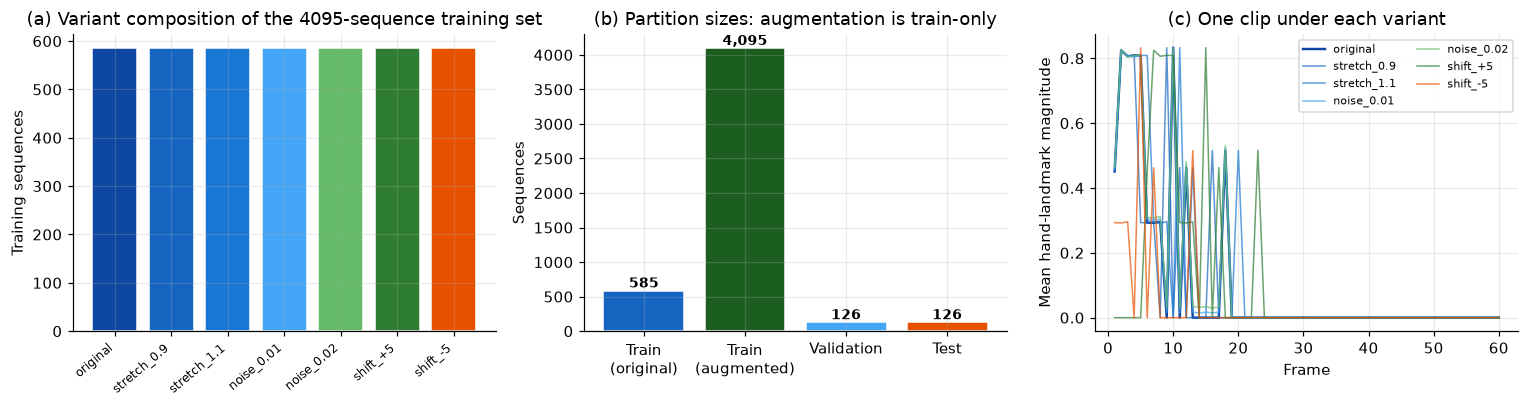

'fig03_augmentation'

In [11]:
def temporal_stretch(seq, alpha, T=SEQ_LEN):
    """Eq. (2): resample on a rescaled time axis, then re-standardize the length."""
    live = int(np.any(seq != 0, axis=1).sum()) or len(seq)
    core = seq[:live]
    n_out = max(int(round(live * alpha)), 2)
    idx = np.linspace(0, live - 1, n_out).round().astype(int)
    return standardize_length(core[idx], T, 'pad_truncate')

def add_noise(seq, sigma, rng):
    """Eq. (3): additive Gaussian jitter on detected frames only; padding stays zero."""
    out = seq.copy()
    live = np.any(out != 0, axis=1)
    if live.any():
        out[live] += rng.normal(0.0, sigma, out[live].shape).astype(np.float32)
    return out

def temporal_shift(seq, k):
    """Shift the sequence by k frames, zero-filling the vacated end."""
    out = np.zeros_like(seq)
    if k >= 0:
        out[k:] = seq[:len(seq) - k]
    else:
        out[:len(seq) + k] = seq[-k:]
    return out

VARIANT_NAMES = (['original']
                 + [f'stretch_{a}' for a in AUG_STRETCH]
                 + [f'noise_{s}'   for s in AUG_NOISE]
                 + [f'shift_{k:+d}' for k in AUG_SHIFT])
N_VARIANTS = len(VARIANT_NAMES)

def apply_variant(seq, vi, rng):
    if vi == 0:
        return seq
    vi -= 1
    if vi < len(AUG_STRETCH):
        return temporal_stretch(seq, AUG_STRETCH[vi])
    vi -= len(AUG_STRETCH)
    if vi < len(AUG_NOISE):
        return add_noise(seq, AUG_NOISE[vi], rng)
    vi -= len(AUG_NOISE)
    return temporal_shift(seq, AUG_SHIFT[vi])

def augment(X, y, g=None, seed=AUG_SEED):
    """Deterministic 7x expansion. Returns (X_aug, y_aug, g_aug, variant_tag, source_idx)."""
    rng = np.random.default_rng(seed)
    Xa = np.empty((len(X) * N_VARIANTS,) + X.shape[1:], np.float32)
    ya = np.empty(len(X) * N_VARIANTS, y.dtype)
    ga = np.empty(len(X) * N_VARIANTS, object)
    tag = np.empty(len(X) * N_VARIANTS, object)
    src = np.empty(len(X) * N_VARIANTS, np.int64)
    k = 0
    for i in range(len(X)):
        for vi in range(N_VARIANTS):
            Xa[k] = apply_variant(X[i], vi, rng)
            ya[k] = y[i]
            ga[k] = g[i] if g is not None else ''
            tag[k] = VARIANT_NAMES[vi]
            src[k] = i
            k += 1
    return Xa, ya, ga, tag, src

# Augment the primary (258-d) view only: the cached face stream would make the augmented
# tensor six times larger for no benefit to the main experiment. §19 augments the
# face-inclusive view separately, when it needs it.
PRIMARY = slice(0, FEAT_DIM)
t0 = time.time()
X_tr_aug, y_tr_aug, g_tr_aug, aug_tag, aug_src = augment(
    X_raw[tr_i][:, :, PRIMARY], y_idx[tr_i], g_raw[tr_i])
print(f'Augmented the training partition in {time.time()-t0:.1f}s: '
      f'{X_tr_aug.shape} ({X_tr_aug.nbytes/1e6:.0f} MB)')

aug_tbl = pd.DataFrame({
    'Partition': ['Train', 'Validation', 'Test', 'Total'],
    'Original clips': [len(tr_i), len(va_i), len(te_i), len(y_idx)],
    'Share of corpus': [f'{len(tr_i)/len(y_idx):.1%}', f'{len(va_i)/len(y_idx):.1%}',
                        f'{len(te_i)/len(y_idx):.1%}', '100.0%'],
    'Augmentation factor': [f'{N_VARIANTS}x', '1x (none)', '1x (none)', '-'],
    'Sequences used for training/evaluation':
        [len(X_tr_aug), len(va_i), len(te_i), len(X_tr_aug) + len(va_i) + len(te_i)],
    'Original clips per class': [len(tr_i) // N_CLASSES, len(va_i) // N_CLASSES,
                                 len(te_i) // N_CLASSES, len(y_idx) // N_CLASSES],
})
save_table(aug_tbl, 'table_split_and_augmentation',
           'THE TABLE THAT ANSWERS REVIEWER A COMMENT 6. The split is applied to the '
           f'original clips first; augmentation expands the training partition {N_VARIANTS}-fold '
           'and touches neither validation nor test. The test partition therefore consists '
           f'of {len(te_i)} original clips, {len(te_i)//N_CLASSES} per class over {N_CLASSES} '
           'classes, which is what the confusion matrix reports. Multiplying the whole '
           f'corpus by {N_VARIANTS} (the published 5,880 figure) describes augmenting every '
           'partition, which is not the procedure that produced these results.',
           'A6', float_fmt='%d')

var_tbl = pd.DataFrame({
    'Variant': VARIANT_NAMES,
    'Transformation': ['identity (the recorded clip)',
                       f'Eq. (2), alpha = {AUG_STRETCH[0]} (slower articulation)',
                       f'Eq. (2), alpha = {AUG_STRETCH[1]} (faster articulation)',
                       f'Eq. (3), sigma = {AUG_NOISE[0]} landmark jitter',
                       f'Eq. (3), sigma = {AUG_NOISE[1]} landmark jitter',
                       f'temporal shift of {AUG_SHIFT[0]:+d} frames',
                       f'temporal shift of {AUG_SHIFT[1]:+d} frames'][:N_VARIANTS],
    'Sequences contributed': [int((aug_tag == v).sum()) for v in VARIANT_NAMES],
    'Applied to': ['training partition only'] * N_VARIANTS,
})
save_table(var_tbl, 'table_augmentation_variants',
           'Manuscript Figure 3(a) as a table: what each augmentation variant does and how '
           'many training sequences it contributes. Every variant is applied to every '
           'training clip, so the contributions are uniform by construction.',
           'A6', float_fmt='%d')

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
axes[0].bar(range(N_VARIANTS), [int((aug_tag == v).sum()) for v in VARIANT_NAMES],
            color=C_SEQ[:N_VARIANTS], edgecolor='white')
axes[0].set_xticks(range(N_VARIANTS))
axes[0].set_xticklabels(VARIANT_NAMES, rotation=40, ha='right', fontsize=8)
axes[0].set_ylabel('Training sequences')
axes[0].set_title(f'(a) Variant composition of the {len(X_tr_aug)}-sequence training set')

parts = ['Train\n(original)', 'Train\n(augmented)', 'Validation', 'Test']
vals  = [len(tr_i), len(X_tr_aug), len(va_i), len(te_i)]
bars = axes[1].bar(parts, vals, color=[C_ALT, C_MAIN, C_SEQ[3], C_WARN], edgecolor='white')
for b, v in zip(bars, vals):
    axes[1].text(b.get_x() + b.get_width() / 2, v, f'{v:,}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')
axes[1].set_ylabel('Sequences')
axes[1].set_title('(b) Partition sizes: augmentation is train-only')

ex = X_raw[tr_i[0]][:, PRIMARY]
rng_demo = np.random.default_rng(0)
for vi, (name, col) in enumerate(zip(VARIANT_NAMES, C_SEQ)):
    v = apply_variant(ex, vi, rng_demo)
    trace = np.linalg.norm(v[:, POSE_DIM:FEAT_DIM].reshape(SEQ_LEN, -1, 3), axis=2).mean(1)
    axes[2].plot(range(1, SEQ_LEN + 1), trace, color=col, lw=1.6 if vi == 0 else 1.0,
                 alpha=1.0 if vi == 0 else 0.7, label=name)
axes[2].set_xlabel('Frame'); axes[2].set_ylabel('Mean hand-landmark magnitude')
axes[2].set_title('(c) One clip under each variant')
axes[2].legend(fontsize=7, ncol=2)
plt.tight_layout()
save_fig(fig, 'fig03_augmentation',
         'Manuscript Figure 3. (a) Uniform contribution of each augmentation variant to the '
         'augmented training set; (b) partition sizes, showing that augmentation expands '
         'only the training partition; (c) the effect of each variant on one clip. Panel (b) '
         'of the published figure — the accuracy gain from augmentation — is now the '
         'no-augmentation row of the ablation table, measured under the identical protocol.',
         'A6')

## 10. Feature views, normalization fit, and the configuration record

Five views over the same clips and the same split, so that every ablation in §19 is a
single-variable change:

| View | Dimension | Contents |
|---|---|---|
| `full_258` | 258 | pose (132) + left hand (63) + right hand (63) — **the published configuration** |
| `pose_only` | 132 | 33 pose landmarks with visibility |
| `hands_only` | 126 | both hands, no body context |
| `with_face` | 1662 | `full_258` + all 468 face landmarks |
| `with_face_compact` | 378 | `full_258` + 40 selected lip, brow, eye and outline landmarks |

The normalizer is fitted on the **augmented training partition only** and applied unchanged
to validation and test, for every view (**Reviewer B comment 6**).

In [12]:
SLICES = {
    'full_258':   PRIMARY,
    'pose_only':  slice(0, POSE_DIM),
    'hands_only': slice(POSE_DIM, FEAT_DIM),
}
VIEW_DIMS = {'full_258': FEAT_DIM, 'pose_only': POSE_DIM,
             'hands_only': 2 * HAND_DIM}
if INCLUDE_FACE:
    VIEW_DIMS['with_face'] = FULL_DIM
    VIEW_DIMS['with_face_compact'] = FEAT_DIM + FACE_COMPACT_DIM

_FACE_COLS = np.array([FEAT_DIM + 3 * i + k for i in FACE_COMPACT_IDX for k in range(3)])

def _slice_view(X, view):
    """Take a feature view out of the cached FULL_DIM tensor."""
    if view in SLICES:
        return X[:, :, SLICES[view]]
    if view == 'with_face':
        return X
    if view == 'with_face_compact':
        return np.concatenate([X[:, :, PRIMARY], X[:, :, _FACE_COLS]], axis=2)
    raise ValueError(view)

_VIEW_CACHE = {}

def build_view(view='full_258', verbose=True):
    """Augmented + normalized tensors for one feature view, on the fixed split."""
    if view in _VIEW_CACHE:
        return _VIEW_CACHE[view]
    if view == 'full_258':
        Xa, ya = X_tr_aug, y_tr_aug                     # already computed in Section 9
    else:
        Xa, ya, _, _, _ = augment(_slice_view(X_raw[tr_i], view), y_idx[tr_i], g_raw[tr_i])
    norm = Normalizer().fit(Xa)
    d = {'Xtr': norm.transform(Xa), 'ytr': ya,
         'Xva': norm.transform(_slice_view(X_raw[va_i], view)), 'yva': y_idx[va_i],
         'Xte': norm.transform(_slice_view(X_raw[te_i], view)), 'yte': y_idx[te_i],
         'dim': int(Xa.shape[-1]), 'view': view, 'norm': norm}
    if verbose:
        print(f"view '{view}': train {d['Xtr'].shape}  val {d['Xva'].shape}  "
              f"test {d['Xte'].shape}  ({d['Xtr'].nbytes/1e6:.0f} MB)")
    _VIEW_CACHE[view] = d
    return d

DATA = build_view('full_258')
yte = DATA['yte']

CONFIG = {
    'manuscript': 'A Swahili Sign Language Recognition Using Bidirectional LSTM with '
                  'Temporal Attention (JCTA revision)',
    'preset': PRESET,
    'classes': CLASS_LIST,
    'class_glosses': {c: GLOSS_EN.get(c, '') for c in CLASS_LIST},
    'signers': SIGNERS,
    'corpus': {
        'source': str(RAW_VIDEO_DIR),
        'archive_clips': int(len(archive)),
        'selected_classes': N_CLASSES,
        'balance_per_signer': BALANCE_PER_SIGNER,
        'balance_seed': BALANCE_SEED,
        'study_clips': int(len(inv)),
        'clips_retained_after_quality_filter': int(len(inv_kept)),
        'quality_threshold_pose_detection': QUALITY_THRESHOLD,
    },
    'extraction': {
        'detector': 'MediaPipe Holistic',
        'mediapipe_version': ENV['mediapipe'],
        'model_complexity': MODEL_COMPLEXITY,
        'min_detection_confidence': MIN_DET_CONF,
        'min_tracking_confidence': MIN_TRK_CONF,
        'refine_face_landmarks': False,
        'smooth_landmarks': True,
        'pose_values_per_frame': POSE_DIM,
        'hand_values_per_frame_each': HAND_DIM,
        'face_values_per_frame': FACE_DIM if INCLUDE_FACE else 0,
        'primary_feature_dim': FEAT_DIM,
        'cached_feature_dim': FULL_DIM,
    },
    'sequence': {'length': SEQ_LEN, 'length_mode': LENGTH_MODE,
                 'raw_length_min': int(raw_len.min()), 'raw_length_max': int(raw_len.max()),
                 'padding_value': 0.0, 'masking': 'Masking layer at the input'},
    'normalization': Normalizer().fit(X_tr_aug).spec(),
    'split': {'order': 'split first, then augment the training partition only',
              'fractions': [TRAIN_FRAC, VAL_FRAC, TEST_FRAC],
              'stratified_by': 'class label', 'random_state': SPLIT_SEED,
              'signer_independent': False,
              'n_train_original': int(len(tr_i)), 'n_train_augmented': int(len(X_tr_aug)),
              'n_val': int(len(va_i)), 'n_test': int(len(te_i))},
    'augmentation': {'applied_to': 'training partition only',
                     'variants': VARIANT_NAMES, 'factor': N_VARIANTS,
                     'stretch_alpha': AUG_STRETCH, 'noise_sigma': AUG_NOISE,
                     'shift_frames': AUG_SHIFT, 'seed': AUG_SEED},
    'training': {'optimizer': 'Adam', 'beta_1': 0.9, 'beta_2': 0.999,
                 'learning_rate': LR, 'clipnorm': CLIPNORM, 'l2': L2_REG,
                 'recurrent_dropout' if not FAST_RECURRENT else 'input_dropout': REC_DROPOUT,
                 'cudnn_fast_path': FAST_RECURRENT,
                 'dense_dropout': DENSE_DROP, 'batch_size': BATCH_SIZE,
                 'max_epochs': EPOCHS, 'seeds': SEEDS,
                 'early_stopping': {'monitor': 'val_loss', 'patience': ES_PATIENCE,
                                    'restore_best_weights': True},
                 'reduce_lr_on_plateau': {'monitor': 'val_loss', 'factor': RLR_FACTOR,
                                          'patience': RLR_PATIENCE, 'min_lr': MIN_LR},
                 'model_checkpoint': 'best val_accuracy',
                 'loss': 'sparse categorical cross-entropy'},
    'environment': ENV,
}
json.dump(CONFIG, open(f'{OUT_DIR}/config.json', 'w'), indent=2, default=str)
register('record', 'config', ['config.json'],
         'The complete, exact configuration behind every reported number: extraction, '
         'normalization scope, split order, augmentation, optimizer and callbacks. This is '
         'the artifact Reviewer B comment 6 asks for and the basis of the reproducibility '
         'claim.', 'B6, A14')
print('\nWrote outputs/config.json')

view 'full_258': train (4095, 60, 258)  val (126, 60, 258)  test (126, 60, 258)  (254 MB)

Wrote outputs/config.json


## 11. Model zoo — **Reviewer A comments 4, 5 and 7**

### The attention layer (A5)

Reviewer A asks for the type of attention, its input, the dimensionality of the
representation, how the score is computed, how the weights are obtained, and how the
weighted representation is formed. The layer below implements all three standard scoring
functions so the choice is also *measured* in §19, and the answer is written to
`attention_specification.json`:

* **Input** — the full output sequence of the second recurrent layer,
  `H = [h_1 … h_60]`, `h_t` the concatenation of the 64-unit forward and 64-unit backward
  states, so `H` has shape `(batch, 60, 128)`.
* **Score (Eq. 11, additive / Bahdanau)** — `e_t = vᵀ tanh(W h_t + b)` with
  `W ∈ ℝ^{128×128}`, `b ∈ ℝ^{128}`, `v ∈ ℝ^{128}`. `v` is a learned query, so no external
  query is needed and the layer adds no recurrence. Parameters: `d² + 2d = 16,640`.
* **Weights (Eq. 12)** — softmax over the 60 time steps. Zero-padded frames are masked to
  `−1e9` *before* the softmax, so they receive exactly zero weight.
* **Output (Eq. 13)** — `c = Σ_t α_t h_t ∈ ℝ^{128}`, consumed by the dense head in place of
  the last hidden state. Because `α` is a distribution over frames it reads directly as a
  per-frame saliency curve, which is what §20 plots.

### The configuration choices (A4)

`build_proposed` exposes every decision the reviewer asks to be justified — depth, width,
directionality, pooling, normalization, dropout, L2 — as one argument each, so §19 can
remove exactly one at a time and the justification becomes a measured delta rather than a
claim.

### The comparison set (A7)

Twelve architectures spanning every family the reviewer named — MLP, temporal CNN, CNN-LSTM,
unidirectional LSTM and GRU, BiGRU, BiLSTM without attention, Transformer encoder, a
skeleton graph network with the real MediaPipe adjacency, and two raw-pixel baselines — all
consuming the identical splits produced above.

In [13]:
try:
    from keras.saving import register_keras_serializable as _reg
except Exception:
    from tensorflow.keras.utils import register_keras_serializable as _reg

# ------------------------------------------------------- temporal attention
@_reg(package='swsl')
class TemporalAttention(layers.Layer):
    """Attention over time, reducing (B, T, d) to (B, d).

    score_type:
      'additive'   e_t = v^T tanh(W h_t + b)        (Bahdanau; Eq. 11, the published choice)
      'general'    e_t = q^T W h_t                  (Luong general)
      'dot_scaled' e_t = (q . h_t) / sqrt(d)        (scaled dot product with a learned query)
    """

    def __init__(self, score_type='additive', **kw):
        super().__init__(**kw)
        self.score_type = score_type
        self.supports_masking = True

    def build(self, input_shape):
        d = int(input_shape[-1])
        self.d = d
        if self.score_type == 'additive':
            self.W = self.add_weight(shape=(d, d), name='att_W',
                                     initializer='glorot_uniform', trainable=True)
            self.b = self.add_weight(shape=(d,), name='att_b',
                                     initializer='zeros', trainable=True)
            self.v = self.add_weight(shape=(d, 1), name='att_v',
                                     initializer='glorot_uniform', trainable=True)
        elif self.score_type == 'general':
            self.W = self.add_weight(shape=(d, d), name='att_W',
                                     initializer='glorot_uniform', trainable=True)
            self.q = self.add_weight(shape=(d,), name='att_q',
                                     initializer='glorot_uniform', trainable=True)
        else:
            self.q = self.add_weight(shape=(d,), name='att_q',
                                     initializer='glorot_uniform', trainable=True)
        super().build(input_shape)

    def scores(self, h):
        if self.score_type == 'additive':                       # Eq. (11)
            u = tf.tanh(tf.tensordot(h, self.W, axes=1) + self.b)
            return tf.squeeze(tf.tensordot(u, self.v, axes=1), -1)
        if self.score_type == 'general':
            u = tf.tensordot(h, self.W, axes=1)
            return tf.reduce_sum(u * self.q, axis=-1)
        return tf.reduce_sum(h * self.q, axis=-1) / math.sqrt(float(self.d))

    def weights_for(self, h, mask=None):
        e = self.scores(h)                                      # (B, T)
        if mask is not None:
            e += (1.0 - tf.cast(mask, e.dtype)) * -1e9           # padded frames get no mass
        return tf.nn.softmax(e, axis=1)                         # Eq. (12)

    def call(self, h, mask=None):
        a = self.weights_for(h, mask)
        return tf.reduce_sum(h * tf.expand_dims(a, -1), axis=1)  # Eq. (13)

    def compute_mask(self, inputs, mask=None):
        return None                                              # time axis is consumed

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])

    def get_config(self):
        return {**super().get_config(), 'score_type': self.score_type}

# ------------------------------------------------ transformer position code
@_reg(package='swsl')
class PositionalEmbedding(layers.Layer):
    """Learned absolute position embedding added to the projected input sequence."""

    def __init__(self, seq_len, d_model, **kw):
        super().__init__(**kw)
        self.seq_len, self.d_model = seq_len, d_model

    def build(self, input_shape):
        self.pos = self.add_weight(shape=(self.seq_len, self.d_model), name='pos',
                                   initializer='random_normal', trainable=True)
        super().build(input_shape)

    def call(self, x):
        return x + self.pos[tf.newaxis, :tf.shape(x)[1], :]

    def get_config(self):
        return {**super().get_config(), 'seq_len': self.seq_len, 'd_model': self.d_model}

# --------------------------------------------------- skeleton graph network
def build_adjacency():
    """Normalized adjacency over the 75 landmark nodes: 33 pose + 21 + 21 hand.

    Edges come from the real MediaPipe topology (POSE_CONNECTIONS, HAND_CONNECTIONS), plus
    two links joining each pose wrist to the root of the corresponding hand graph.
    """
    V = 33 + 21 + 21
    A = np.zeros((V, V), np.float32)
    for i, j in mp_holistic.POSE_CONNECTIONS:
        A[i, j] = A[j, i] = 1.0
    for base in (33, 54):
        for i, j in mp_holistic.HAND_CONNECTIONS:
            A[base + i, base + j] = A[base + j, base + i] = 1.0
    A[15, 33] = A[33, 15] = 1.0        # left pose wrist  <-> left hand root
    A[16, 54] = A[54, 16] = 1.0        # right pose wrist <-> right hand root
    A += np.eye(V, dtype=np.float32)   # self loops
    d = np.power(A.sum(1), -0.5)
    return (A * d[:, None] * d[None, :]).astype(np.float32)

ADJ = build_adjacency()
N_NODES = ADJ.shape[0]
print(f'Skeleton graph: {N_NODES} nodes, '
      f'{int((ADJ > 0).sum() - N_NODES) // 2} undirected edges '
      f'(MediaPipe pose + hand topology)')

@_reg(package='swsl')
class LandmarkGraph(layers.Layer):
    """(B, T, 258) -> (B, T, 75, 4). Hand blocks are padded with a unit visibility channel."""

    def call(self, x):
        B, T = tf.shape(x)[0], tf.shape(x)[1]
        pose = tf.reshape(x[..., :POSE_DIM], (B, T, 33, 4))
        lh = tf.reshape(x[..., POSE_DIM:POSE_DIM + HAND_DIM], (B, T, 21, 3))
        rh = tf.reshape(x[..., POSE_DIM + HAND_DIM:FEAT_DIM], (B, T, 21, 3))
        ones = tf.ones((B, T, 21, 1), x.dtype)
        return tf.concat([pose, tf.concat([lh, ones], -1),
                          tf.concat([rh, ones], -1)], axis=2)

    def compute_output_shape(self, s):
        return (s[0], s[1], N_NODES, 4)

@_reg(package='swsl')
class GraphConv(layers.Layer):
    """Spatial graph convolution: H' = A_norm H W, applied at every time step."""

    def __init__(self, units, **kw):
        super().__init__(**kw)
        self.units = units

    def build(self, input_shape):
        self.kernel = self.add_weight(shape=(int(input_shape[-1]), self.units),
                                      name='gc_kernel', initializer='glorot_uniform')
        self.bias = self.add_weight(shape=(self.units,), name='gc_bias',
                                    initializer='zeros')
        self.A = self.add_weight(shape=ADJ.shape, name='adjacency',
                                 initializer=keras.initializers.Constant(ADJ),
                                 trainable=False)
        super().build(input_shape)

    def call(self, x):
        x = tf.einsum('vu,btuc->btvc', self.A, x)
        return tf.nn.relu(tf.tensordot(x, self.kernel, axes=1) + self.bias)

    def get_config(self):
        return {**super().get_config(), 'units': self.units}

    def compute_output_shape(self, s):
        return (s[0], s[1], s[2], self.units)

# ------------------------------------------------------------- shared parts
def _rnn(units, return_sequences, kind='lstm', bidirectional=True, l2=L2_REG,
         dropout=REC_DROPOUT):
    """One recurrent layer. FAST_RECURRENT puts dropout on the inputs so cuDNN stays usable."""
    kw = dict(units=units, return_sequences=return_sequences,
              kernel_regularizer=regularizers.l2(l2))
    if FAST_RECURRENT:
        kw.update(dropout=dropout, recurrent_dropout=0.0)
        # If left-shifting augmentation is active, cuDNN cannot be used due to
        # non-right-padded masks. _LEFT_SHIFT_AUGMENTATION_ACTIVE is defined in cell -dv8XR5tQ2cs.
        if globals().get('_LEFT_SHIFT_AUGMENTATION_ACTIVE', False):
            kw.update(use_cudnn=False)
    else:
        kw.update(dropout=0.0, recurrent_dropout=dropout)

    cell = layers.LSTM(**kw) if kind == 'lstm' else layers.GRU(**kw)
    return layers.Bidirectional(cell) if bidirectional else cell

def _inp(dim):
    return keras.Input(shape=(SEQ_LEN, dim), name='landmark_sequence')

def _head(x, n_cls, l2=L2_REG, drops=DENSE_DROP, use_bn=True, widths=(128, 64)):
    """Dense classification head: BN -> Dense(128) -> Drop -> BN -> Dense(64) -> Drop -> softmax."""
    for w, p in zip(widths, drops):
        if use_bn:
            x = layers.BatchNormalization()(x)
        x = layers.Dense(w, activation='relu', kernel_regularizer=regularizers.l2(l2))(x)
        x = layers.Dropout(p)(x)
    return layers.Dense(n_cls, activation='softmax', name='class_posterior')(x)

# ------------------------------------------------------------ PROPOSED MODEL

@_reg(package='swsl')
class SafeGlobalAveragePooling1D(layers.Layer):
    """Mask-aware GlobalAveragePooling1D preventing 0/0 division when all frames are masked."""
    def __init__(self, **kw):
        super().__init__(**kw)
        self.supports_masking = True

    def call(self, inputs, mask=None):
        if mask is not None:
            mask_cast = tf.cast(mask, inputs.dtype)
            mask_exp = tf.expand_dims(mask_cast, -1)
            sum_val = tf.reduce_sum(inputs * mask_exp, axis=1)
            count = tf.reduce_sum(mask_exp, axis=1)
            safe_count = tf.maximum(count, 1.0)
            return sum_val / safe_count
        return tf.reduce_mean(inputs, axis=1)

    def compute_mask(self, inputs, mask=None):
        return None

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])

@_reg(package='swsl')
class SafeGlobalMaxPooling1D(layers.Layer):
    """Mask-aware GlobalMaxPooling1D safely handling masked frames."""
    def __init__(self, **kw):
        super().__init__(**kw)
        self.supports_masking = True

    def call(self, inputs, mask=None):
        if mask is not None:
            mask_exp = tf.expand_dims(mask, -1)
            inputs_masked = tf.where(mask_exp, inputs, -1e9)
            res = tf.reduce_max(inputs_masked, axis=1)
            return tf.where(tf.equal(res, -1e9), 0.0, res)
        return tf.reduce_max(inputs, axis=1)

    def compute_mask(self, inputs, mask=None):
        return None

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])

def build_proposed(dim, n_cls, *, bidirectional=True, n_layers=2, units=(128, 64),
                   pooling='attention', score_type='additive', use_bn=True,
                   l2=L2_REG, dropout=REC_DROPOUT, dense_drops=DENSE_DROP,
                   use_masking=True, kind='lstm'):
    """The proposed architecture. Every argument is one ablatable design decision (A4)."""
    inp = _inp(dim)
    x = layers.Masking(mask_value=0.0, name='masking')(inp) if use_masking else inp
    need_seq = pooling in ('attention', 'mean', 'max')
    for li in range(n_layers):
        last = (li == n_layers - 1)
        x = _rnn(units[min(li, len(units) - 1)], return_sequences=(not last) or need_seq,
                 kind=kind, bidirectional=bidirectional, l2=l2, dropout=dropout)(x)
        if use_bn and not last:
            x = layers.BatchNormalization()(x)
    if pooling == 'attention':
        x = TemporalAttention(score_type=score_type, name='temporal_attention')(x)
    elif pooling == 'mean':
        x = SafeGlobalAveragePooling1D(name='mean_pool')(x)
    elif pooling == 'max':
        x = SafeGlobalMaxPooling1D(name='max_pool')(x)
    name = (f'{"bi" if bidirectional else "uni"}{kind}{n_layers}x'
            f'{"-".join(str(u) for u in units[:n_layers])}_{pooling}')
    return keras.Model(inp, _head(x, n_cls, l2, dense_drops, use_bn), name=name)

# ------------------------------------------------------ LANDMARK BASELINES
def build_mlp(dim, n_cls):
    """Reviewer A comment 7: MLP. No temporal structure at all — the flattened sequence."""
    inp = _inp(dim)
    x = layers.Flatten()(inp)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(L2_REG))(x)
    return keras.Model(inp, _head(x, n_cls), name='mlp')

def build_tcnn(dim, n_cls):
    """Temporal 1-D CNN over the landmark sequence: local motion, no long-range recurrence."""
    inp = _inp(dim)
    x = inp
    for f in (128, 64):
        x = layers.Conv1D(f, 5, padding='same', activation='relu',
                          kernel_regularizer=regularizers.l2(L2_REG))(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling1D(2)(x)
    x = layers.GlobalAveragePooling1D()(x)
    return keras.Model(inp, _head(x, n_cls), name='temporal_cnn')

def build_cnn_lstm_landmark(dim, n_cls):
    """Convolutional front end feeding a recurrent back end, on landmarks."""
    inp = _inp(dim)
    x = layers.Conv1D(128, 5, padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(L2_REG))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = _rnn(128, return_sequences=False, bidirectional=False)(x)
    return keras.Model(inp, _head(x, n_cls), name='cnn_lstm_landmark')

def build_uni_lstm(dim, n_cls):
    return build_proposed(dim, n_cls, bidirectional=False, pooling='last')

def build_uni_gru(dim, n_cls):
    return build_proposed(dim, n_cls, bidirectional=False, pooling='last', kind='gru')

def build_bigru(dim, n_cls):
    return build_proposed(dim, n_cls, pooling='last', kind='gru')

def build_bilstm_plain(dim, n_cls):
    """The proposed network with attention replaced by the last hidden state."""
    return build_proposed(dim, n_cls, pooling='last')

def build_transformer(dim, n_cls, d_model=128, heads=4, blocks=2, ff_mult=2):
    """Self-attention without recurrence."""
    inp = _inp(dim)
    x = layers.Dense(d_model, name='input_projection')(inp)
    x = PositionalEmbedding(SEQ_LEN, d_model, name='positional_embedding')(x)
    for b in range(blocks):
        a = layers.MultiHeadAttention(heads, d_model // heads, name=f'mha_{b}')(x, x)
        x = layers.LayerNormalization()(layers.Add()([x, layers.Dropout(0.1)(a)]))
        f = layers.Dense(d_model * ff_mult, activation='relu')(x)
        f = layers.Dense(d_model)(f)
        x = layers.LayerNormalization()(layers.Add()([x, layers.Dropout(0.1)(f)]))
    x = layers.GlobalAveragePooling1D()(x)
    return keras.Model(inp, _head(x, n_cls), name=f'transformer_{blocks}L')

def build_stgcn(dim, n_cls):
    """Spatio-temporal graph network over the real MediaPipe skeleton (A7: skeleton models).

    Requires the 258-d view: the graph is defined over 33 pose + 21 + 21 hand nodes.
    """
    assert dim == FEAT_DIM, 'ST-GCN requires the 258-d pose+hands view'
    inp = _inp(dim)
    x = LandmarkGraph(name='to_graph')(inp)                  # (B, T, 75, 4)
    for f in (64, 128):
        x = GraphConv(f)(x)                                  # spatial
        x = layers.Conv2D(f, (9, 1), padding='same', activation='relu',
                          kernel_regularizer=regularizers.l2(L2_REG))(x)   # temporal
        x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)                   # pool over time and nodes
    return keras.Model(inp, _head(x, n_cls), name='stgcn')

# ----------------------------------------------------- RAW-PIXEL BASELINES
FRAME_HW = 64

def build_frame_cnn(n_cls):
    """Frame-wise CNN, spatial only: per-frame features averaged over time.

    This is the baseline that supports the Introduction's claim (A1) that a landmark
    representation is the right choice for a corpus of this size.
    """
    inp = keras.Input(shape=(SEQ_LEN, FRAME_HW, FRAME_HW, 1), name='frame_sequence')
    c = keras.Sequential([
        layers.Conv2D(32, 3, padding='same', activation='relu'), layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding='same', activation='relu'), layers.MaxPooling2D(2),
        layers.Conv2D(128, 3, padding='same', activation='relu'), layers.MaxPooling2D(2),
        layers.GlobalAveragePooling2D()], name='frame_encoder')
    x = layers.TimeDistributed(c)(inp)
    x = layers.GlobalAveragePooling1D()(x)
    return keras.Model(inp, _head(x, n_cls), name='frame_cnn')

def build_cnn_lstm_raw(n_cls):
    """Learned spatial features with temporal recurrence, on raw frames."""
    inp = keras.Input(shape=(SEQ_LEN, FRAME_HW, FRAME_HW, 1), name='frame_sequence')
    c = keras.Sequential([
        layers.Conv2D(32, 3, padding='same', activation='relu'), layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding='same', activation='relu'), layers.MaxPooling2D(2),
        layers.Conv2D(128, 3, padding='same', activation='relu'), layers.MaxPooling2D(2),
        layers.GlobalAveragePooling2D()], name='frame_encoder')
    x = layers.TimeDistributed(c)(inp)
    x = _rnn(128, return_sequences=False, bidirectional=False)(x)
    return keras.Model(inp, _head(x, n_cls), name='cnn_lstm_raw')

# ------------------------------------------------------------- the registry
LANDMARK_MODELS = {
    'MLP (flattened landmarks)':            build_mlp,
    'Temporal CNN (1-D)':                   build_tcnn,
    'CNN-LSTM (landmarks)':                 build_cnn_lstm_landmark,
    'Unidirectional LSTM':                  build_uni_lstm,
    'Unidirectional GRU':                   build_uni_gru,
    'BiGRU':                                build_bigru,
    'BiLSTM (no attention)':                build_bilstm_plain,
    'Transformer encoder (2 layers)':       build_transformer,
    'ST-GCN (skeleton graph)':              build_stgcn,
}
RAW_MODELS = {
    'Frame-wise CNN (raw 64x64)':           build_frame_cnn,
    'CNN-LSTM hybrid (raw 64x64)':          build_cnn_lstm_raw,
}
PROPOSED = 'BiLSTM + temporal attention (proposed)'

print(f'\nLandmark architectures: {len(LANDMARK_MODELS)}  + the proposed model')
print(f'Raw-pixel architectures: {len(RAW_MODELS)} '
      f'({"enabled" if RUN_RAW_FRAME_BASELINES else "disabled"})')

# ---- the attention specification the reviewer asked for -----------------
_m = build_proposed(DATA['dim'], N_CLASSES)
_att = _m.get_layer('temporal_attention')
att_spec = {
    'reviewer_comment': 'Reviewer A comment 5',
    'type': 'additive (Bahdanau-style) attention over the time axis, self-queried',
    'input': {
        'source': 'output sequence of the second BiLSTM layer',
        'shape': f'(batch, {SEQ_LEN}, {2*64})',
        'h_t': 'concatenation of the 64-unit forward and 64-unit backward hidden states',
        'representation_dim_d': 2 * 64,
    },
    'score_equation': 'e_t = v^T tanh(W h_t + b)        (manuscript Eq. 11)',
    'score_parameters': {
        'W': f'({2*64}, {2*64})', 'b': f'({2*64},)', 'v': f'({2*64}, 1)',
        'total': 2 * 64 * 2 * 64 + 2 * 2 * 64,
        'note': 'The learned vector v acts as a fixed query, so the mechanism needs no '
                'external query and introduces no recurrence of its own.',
    },
    'weight_equation': 'alpha_t = exp(e_t) / sum_k exp(e_k)   over the 60 time steps '
                       '(manuscript Eq. 12)',
    'masking': 'Zero-padded frames are detected by the input Masking layer and their scores '
               'are set to -1e9 before the softmax, so they receive exactly zero weight.',
    'output_equation': 'c = sum_t alpha_t h_t   (manuscript Eq. 13)',
    'output_shape': f'(batch, {2*64})',
    'consumed_by': 'the dense classification head, in place of the last hidden state',
    'interpretability': 'alpha is a proper distribution over the 60 frames and is therefore '
                        'read directly as a per-frame saliency curve.',
    'alternatives_measured': ['additive (Bahdanau)', 'general (Luong)',
                              'scaled dot product with a learned query',
                              'mean pooling', 'max pooling', 'last hidden state'],
    'measured_parameter_count': int(_att.count_params()),
    'parameter_count_in_published_table_5': 16577,
}
json.dump(att_spec, open(f'{OUT_DIR}/attention_specification.json', 'w'), indent=2)
register('record', 'attention_specification', ['attention_specification.json'],
         'Complete technical specification of the temporal attention mechanism: input, '
         'dimensionality, scoring function, normalization, masking and output. Written so '
         'Section 3.5 can be checked line by line against the implementation.', 'A5')
print(f'\nAttention layer: {_att.count_params():,} parameters '
      f'(published Table 5 states 16,577)')
_m.summary()
del _m


Skeleton graph: 75 nodes, 79 undirected edges (MediaPipe pose + hand topology)

Landmark architectures: 9  + the proposed model
Raw-pixel architectures: 2 (disabled)



Attention layer: 16,640 parameters (published Table 5 states 16,577)


Model: "bilstm2x128-64_attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ landmark_sequence   │ (None, 60, 258)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 60, 258)   │          0 │ landmark_sequenc… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 60, 258)   │          0 │ landmark_sequenc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 60)        │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 60, 256)   │    396,288 │ masking[0][0],    │
│ (Bidirectional)     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 60, 256)   │      1,024 │ bidirectional[0]… │
│ (BatchNormalizatio… │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 60, 128)   │    164,352 │ batch_normalizat… │
│ (Bidirectional)     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_attention  │ (None, 128)       │     16,640 │ bidirectional_1[… │
│ (TemporalAttention) │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ temporal_attenti… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     16,512 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dropout[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_posterior     │ (None, 7)         │        455 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 604,551 (2.31 MB)

 Trainable params: 603,527 (2.30 MB)

 Non-trainable params: 1,024 (4.00 KB)

### 11.1 Raw-frame tensors for the pixel baselines

The two raw-pixel baselines need image sequences, not landmarks. Each clip is decoded once
to a `(60, 64, 64)` 8-bit greyscale tensor and cached on local disk. Greyscale keeps the
cache at roughly a quarter of a gigabyte; colour adds nothing to a baseline whose purpose is
to show what a pixel-space model does with this much data.

Augmentation for these models is generated on the fly by a `PyDataset`, applying the same
seven deterministic variants as the landmark pipeline, so the protocol really is identical
and memory stays bounded.

In [14]:
RAW_FRAMES = None
if RUN_RAW_FRAME_BASELINES:
    frame_npy = f'{FRAME_CACHE}/frames_{FRAME_HW}_{SEQ_LEN}_{len(inv_kept)}.npy'
    if os.path.exists(frame_npy):
        RAW_FRAMES = np.load(frame_npy, mmap_mode='r')
        print(f'Loaded cached frame tensor: {RAW_FRAMES.shape}')
    else:
        print(f'Decoding {len(inv_kept)} clips to {SEQ_LEN}x{FRAME_HW}x{FRAME_HW} greyscale ...')
        RAW_FRAMES = np.zeros((len(inv_kept), SEQ_LEN, FRAME_HW, FRAME_HW), np.uint8)
        t0 = time.time()
        for k, r in enumerate(inv_kept.itertuples()):
            cap = cv2.VideoCapture(r.path)
            buf = []
            while True:
                ok, fr = cap.read()
                if not ok:
                    break
                g = cv2.cvtColor(fr, cv2.COLOR_BGR2GRAY)
                buf.append(cv2.resize(g, (FRAME_HW, FRAME_HW),
                                      interpolation=cv2.INTER_AREA))
            cap.release()
            if buf:
                arr = np.stack(buf)
                if len(arr) >= SEQ_LEN:
                    RAW_FRAMES[k] = arr[:SEQ_LEN]
                else:
                    RAW_FRAMES[k, :len(arr)] = arr
            if (k + 1) % 100 == 0 or k + 1 == len(inv_kept):
                el = time.time() - t0
                print(f'  {k+1}/{len(inv_kept)}  ({el:.0f}s, '
                      f'ETA {el/(k+1)*(len(inv_kept)-k-1):.0f}s)')
        np.save(frame_npy, RAW_FRAMES)
        print(f'Cached {RAW_FRAMES.nbytes/1e6:.0f} MB -> {frame_npy}')

_Base = getattr(keras.utils, 'PyDataset', None) or keras.utils.Sequence

class RawFrameSequence(_Base):
    """Batches of raw-frame sequences, applying the seven augmentation variants on the fly."""

    def __init__(self, frames, base_idx, labels, batch_size=BATCH_SIZE,
                 augment_data=True, shuffle=True, seed=0, **kw):
        try:
            super().__init__(**kw)
        except Exception:
            pass
        self.frames = frames
        self.base_idx = np.asarray(base_idx)
        self.labels = np.asarray(labels)
        self.batch_size = batch_size
        self.n_var = N_VARIANTS if augment_data else 1
        self.shuffle = shuffle
        self.rng = np.random.default_rng(seed)
        self.items = np.array([(i, v) for i in range(len(self.base_idx))
                               for v in range(self.n_var)], np.int64)
        self.order = np.arange(len(self.items))
        self.on_epoch_end()

    def __len__(self):
        return int(math.ceil(len(self.items) / self.batch_size))

    def _variant(self, clip, v):
        """Same semantics as the landmark variants: stretch, jitter, shift, identity."""
        if v == 0:
            return clip
        v -= 1
        if v < len(AUG_STRETCH):
            a = AUG_STRETCH[v]
            n_out = max(int(round(SEQ_LEN * a)), 2)
            idx = np.clip(np.linspace(0, SEQ_LEN - 1, n_out).round().astype(int),
                          0, SEQ_LEN - 1)
            out = clip[idx]
            return (out[:SEQ_LEN] if len(out) >= SEQ_LEN else
                    np.concatenate([out, np.zeros((SEQ_LEN - len(out),) + clip.shape[1:],
                                                  clip.dtype)]))
        v -= len(AUG_STRETCH)
        if v < len(AUG_NOISE):
            sigma = AUG_NOISE[v] * 255.0 * 2       # comparable perturbation in pixel units
            noisy = clip.astype(np.float32) + self.rng.normal(0, sigma, clip.shape)
            return np.clip(noisy, 0, 255).astype(np.uint8)
        v -= len(AUG_NOISE)
        k = AUG_SHIFT[v]
        out = np.zeros_like(clip)
        if k >= 0:
            out[k:] = clip[:SEQ_LEN - k]
        else:
            out[:SEQ_LEN + k] = clip[-k:]
        return out

    def __getitem__(self, b):
        sel = self.order[b * self.batch_size:(b + 1) * self.batch_size]
        X = np.empty((len(sel), SEQ_LEN, FRAME_HW, FRAME_HW, 1), np.float32)
        y = np.empty(len(sel), np.int64)
        for k, s in enumerate(sel):
            i, v = self.items[s]
            clip = np.asarray(self.frames[self.base_idx[i]])
            X[k, ..., 0] = self._variant(clip, v).astype(np.float32) / 255.0
            y[k] = self.labels[i]
        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            self.rng.shuffle(self.order)

def raw_frame_data(seed=0):
    """Train/val/test feeds for the raw-pixel baselines, on the identical split."""
    return {
        'train': RawFrameSequence(RAW_FRAMES, tr_i, y_idx[tr_i], augment_data=True,
                                  shuffle=True, seed=seed),
        'val':   RawFrameSequence(RAW_FRAMES, va_i, y_idx[va_i], augment_data=False,
                                  shuffle=False),
        'test':  RawFrameSequence(RAW_FRAMES, te_i, y_idx[te_i], augment_data=False,
                                  shuffle=False),
        'yte': y_idx[te_i], 'yva': y_idx[va_i], 'dim': None, 'raw': True,
    }
print('Raw-frame feeds ready.' if RAW_FRAMES is not None else
      'Raw-frame baselines disabled.')

Raw-frame baselines disabled.


## 12. Training harness — one protocol for everything, and resume-safe

Every model in this notebook is trained through `train_once`, which fixes the split, the
augmented training set, the optimizer, the callbacks and the class-weighting policy. Nothing
differs between the proposed model and a baseline except the architecture.

**Resume safety.** Each run is keyed by `(tag, seed)` and its metrics, per-epoch history and
per-sample predictions are written to Drive. A re-run loads them instead of retraining, so a
Colab disconnect costs at most one model. Set `FORCE_RETRAIN = True` in §2 to discard the
registry.

**Reviewer B comment 11** is answered mechanically below: the imbalance ratio is measured at
every stage of the pipeline and the weighting policy follows from the measurement.

In [15]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             precision_recall_fscore_support, confusion_matrix,
                             classification_report, cohen_kappa_score,
                             matthews_corrcoef, roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score,
                             top_k_accuracy_score, log_loss)

# --------------------------------------------- B11: imbalance at every stage
stages = [
    ('Archive (all folders)', Counter(archive.label)),
    ('Study corpus (after class selection and balancing)', Counter(inv.label)),
    ('After the landmark-quality filter', Counter(inv_kept.label)),
    ('Training partition (original clips)',
     Counter(CLASS_LIST[i] for i in y_idx[tr_i])),
    ('Training partition (after augmentation)',
     Counter(CLASS_LIST[i] for i in y_tr_aug)),
    ('Validation partition', Counter(CLASS_LIST[i] for i in y_idx[va_i])),
    ('Test partition', Counter(CLASS_LIST[i] for i in y_idx[te_i])),
]
imb_rows = []
for name, cnt in stages:
    sel = {k: v for k, v in cnt.items() if k in CLASS_LIST}
    lo, hi = min(sel.values()), max(sel.values())
    imb_rows.append({'Pipeline stage': name, 'Samples': sum(sel.values()),
                     'Smallest class': lo, 'Largest class': hi,
                     'Imbalance ratio (max/min)': round(hi / lo, 4)})
imb_tbl = save_table(pd.DataFrame(imb_rows), 'table_class_balance_by_stage',
    'REVIEWER B COMMENT 11. Class balance measured at every stage of the pipeline. The '
    'manuscript describes the corpus as balanced by design but then states that class '
    'weighting was necessary; this table shows where, if anywhere, imbalance actually '
    'enters. The weighting policy below is set from the training-partition row, not from '
    'the text.', 'B11')

train_counts = Counter(y_tr_aug)
IMBALANCE = max(train_counts.values()) / min(train_counts.values())
if IMBALANCE < 1.05:
    CLASS_WEIGHT = None
    WEIGHT_NOTE = (f'Imbalance ratio in the augmented training partition is '
                   f'{IMBALANCE:.4f}. Class weighting is DISABLED because it would be a '
                   f'no-op. The manuscript should state that the balanced factorial design '
                   f'survives the stratified split, so inverse-frequency weighting was not '
                   f'required.')
else:
    cw = compute_class_weight('balanced', classes=np.arange(N_CLASSES), y=y_tr_aug)
    CLASS_WEIGHT = dict(enumerate(cw.astype(float)))
    WEIGHT_NOTE = (f'Imbalance ratio in the augmented training partition is '
                   f'{IMBALANCE:.4f}, so inverse-frequency class weights ARE applied: '
                   + ', '.join(f'{CLASS_LIST[k]}={v:.3f}' for k, v in CLASS_WEIGHT.items()))
print('\n' + textwrap.fill(WEIGHT_NOTE, 100))
record('train_imbalance_ratio', round(float(IMBALANCE), 4),
       'Section 3.6 / Eq. (15): whether class weighting is justified')
CONFIG['training']['class_weighting'] = WEIGHT_NOTE
json.dump(CONFIG, open(f'{OUT_DIR}/config.json', 'w'), indent=2, default=str)

# ------------------------------------------------------------- run registry
def run_key(tag, seed):
    safe = re.sub(r'[^A-Za-z0-9]+', '_', tag).strip('_')[:60]
    return f'{safe}__seed{seed}'

def load_run(tag, seed, want_model=False):
    """A completed run from the registry, or None if it must be trained.

    `want_model` also requires the serialized weights, so a caller that needs the model
    object (the attention analysis, the parameter audit) is not handed a metrics-only
    record.
    """
    if FORCE_RETRAIN:
        return None
    k = run_key(tag, seed)
    mj = f'{RUN_DIR}/{k}.json'
    if not os.path.exists(mj):
        return None
    try:
        r = json.load(open(mj))
        for fld, fn in (('pred', f'{RUN_DIR}/{k}_pred.npy'),
                        ('proba', f'{RUN_DIR}/{k}_proba.npy')):
            r[fld] = np.load(fn) if os.path.exists(fn) else None
        if want_model:
            mf = f'{RUN_DIR}/{k}.keras'
            if not os.path.exists(mf):
                return None
            r['model'] = keras.models.load_model(mf)
        r['cached'] = True
        return r
    except Exception:
        return None

def save_run(tag, seed, rec):
    k = run_key(tag, seed)
    if rec.get('pred') is not None:
        np.save(f'{RUN_DIR}/{k}_pred.npy', np.asarray(rec['pred']))
    if rec.get('proba') is not None:
        np.save(f'{RUN_DIR}/{k}_proba.npy', np.asarray(rec['proba'], np.float32))
    meta = {x: rec[x] for x in rec if x not in ('pred', 'proba', 'model')}
    json.dump(meta, open(f'{RUN_DIR}/{k}.json', 'w'), indent=2, default=str)

def evaluate_predictions(y_true, proba):
    """Every metric the manuscript reports, plus the ones the reviewers should see."""
    # Sanitize proba array: replace NaN with a very small positive number to prevent log_loss from failing
    proba = np.nan_to_num(proba, nan=1.0/N_CLASSES, posinf=1.0/N_CLASSES, neginf=1.0/N_CLASSES)
    row_sums = proba.sum(axis=-1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    proba = proba / row_sums

    pred = proba.argmax(1)
    labels = np.arange(N_CLASSES)
    onehot = np.eye(N_CLASSES)[y_true]
    m = {
        'accuracy': float(accuracy_score(y_true, pred)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, pred)),
        'macro_f1': float(f1_score(y_true, pred, average='macro', labels=labels,
                                   zero_division=0)),
        'weighted_f1': float(f1_score(y_true, pred, average='weighted', labels=labels,
                                      zero_division=0)),
        'cohen_kappa': float(cohen_kappa_score(y_true, pred, labels=labels)),
        'mcc': float(matthews_corrcoef(y_true, pred)) if len(set(y_true)) > 1 else np.nan,
        'log_loss': float(log_loss(y_true, proba, labels=labels)),
    }
    p, r, f, s = precision_recall_fscore_support(y_true, pred, labels=labels,
                                                 zero_division=0)
    m.update({'macro_precision': float(p.mean()), 'macro_recall': float(r.mean())})
    try:
        m['top2_accuracy'] = float(top_k_accuracy_score(y_true, proba, k=2, labels=labels))
        m['macro_auc'] = float(roc_auc_score(onehot, proba, average='macro',
                                             multi_class='ovr'))
        m['macro_ap'] = float(average_precision_score(onehot, proba, average='macro'))
    except Exception:
        m.update({'top2_accuracy': np.nan, 'macro_auc': np.nan, 'macro_ap': np.nan})
    return m

def train_once(build_fn, data, seed, tag, epochs=EPOCHS, verbose=0, keep_model=False,
               save_model=False, class_weight='auto', batch_size=BATCH_SIZE):
    """Train one model under the shared protocol. Cached runs are returned untouched."""
    cached = load_run(tag, seed, want_model=keep_model)
    if cached is not None:
        print(f'    seed {seed}: acc={cached["accuracy"]*100:.2f}%  '
              f'macroF1={cached["macro_f1"]*100:.2f}%   [cached]')
        return cached

    keras.backend.clear_session()
    gc.collect()
    set_all_seeds(seed)

    is_raw = data.get('raw', False)
    model = build_fn() if is_raw else build_fn(data['dim'], N_CLASSES)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=LR, clipnorm=CLIPNORM),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    ckpt = f'{CKPT_DIR}/{run_key(tag, seed)}.weights.h5'
    cbs = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=ES_PATIENCE,
                                      restore_best_weights=True, verbose=0),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=RLR_FACTOR,
                                          patience=RLR_PATIENCE, min_lr=MIN_LR, verbose=0),
        keras.callbacks.ModelCheckpoint(ckpt, monitor='val_accuracy', mode='max',
                                        save_best_only=True, save_weights_only=True,
                                        verbose=0),
    ]
    cw = CLASS_WEIGHT if class_weight == 'auto' else class_weight
    t0 = time.time()
    if is_raw:
        hist = model.fit(data['train'], validation_data=data['val'], epochs=epochs,
                         class_weight=cw, callbacks=cbs, verbose=verbose)
    else:
        hist = model.fit(data['Xtr'], data['ytr'],
                         validation_data=(data['Xva'], data['yva']),
                         epochs=epochs, batch_size=batch_size, class_weight=cw,
                         callbacks=cbs, verbose=verbose)
    train_time = time.time() - t0

    # ModelCheckpoint kept the best-validation-accuracy weights; EarlyStopping restored the
    # best-validation-loss weights. Report the checkpointed model, as Section 3.6 states.
    if os.path.exists(ckpt):
        try:
            model.load_weights(ckpt)
        except Exception:
            pass

    proba = (model.predict(data['test'], verbose=0) if is_raw
             else model.predict(data['Xte'], verbose=0))
    y_true = data['yte']
    rec = evaluate_predictions(y_true, proba)
    rec.update({
        'tag': tag, 'seed': seed, 'model_name': model.name,
        'epochs_run': int(len(hist.history['loss'])),
        'best_epoch': int(np.argmin(hist.history['val_loss']) + 1),
        'train_time_s': round(train_time, 1),
        'params': int(model.count_params()),
        'final_train_accuracy': float(hist.history['accuracy'][-1]),
        'best_val_accuracy': float(max(hist.history['val_accuracy'])),
        'best_val_loss': float(min(hist.history['val_loss'])),
        'pred': proba.argmax(1), 'proba': proba, 'cached': False,
    })

    hdf = pd.DataFrame(hist.history)
    hdf.insert(0, 'epoch', np.arange(1, len(hdf) + 1))
    hdf.to_csv(f'{OUT_DIR}/histories/{run_key(tag, seed)}.csv', index=False)
    rec['history_file'] = f'histories/{run_key(tag, seed)}.csv'
    rec['history'] = {k: [float(x) for x in v] for k, v in hist.history.items()}
    save_run(tag, seed, rec)

    print(f'    seed {seed}: acc={rec["accuracy"]*100:.2f}%  '
          f'macroF1={rec["macro_f1"]*100:.2f}%  '
          f'({rec["epochs_run"]} epochs, best @{rec["best_epoch"]}, '
          f'{train_time:.0f}s, {rec["params"]:,} params)')
    if keep_model or save_model:
        try:
            model.save(f'{RUN_DIR}/{run_key(tag, seed)}.keras')
        except Exception as e:
            print(f'      (could not serialize the model: {e})')
    if keep_model:
        rec['model'] = model
    else:
        del model
        keras.backend.clear_session()
        gc.collect()
    return rec

def run_multi_seed(build_fn, data, tag, seeds=None, keep_best_model=False, **kw):
    """Train the same architecture under several initializations; aggregate mean +/- std."""
    seeds = seeds or SEEDS
    runs = [train_once(build_fn, data, s, tag, **kw) for s in seeds]
    agg = {'tag': tag, 'runs': runs, 'seeds': list(seeds),
           'params': runs[0].get('params', np.nan)}
    for met in ('accuracy', 'macro_f1', 'balanced_accuracy', 'macro_precision',
                'macro_recall', 'cohen_kappa', 'mcc', 'macro_auc', 'top2_accuracy',
                'log_loss', 'train_time_s', 'epochs_run'):
        vals = np.array([r.get(met, np.nan) for r in runs], float)
        agg[f'{met}_mean'] = float(np.nanmean(vals))
        agg[f'{met}_std'] = float(np.nanstd(vals))
        agg[f'{met}_values'] = [None if v is None or np.isnan(v) else float(v)
                                for v in vals]
    best_i = int(np.nanargmax([r['accuracy'] for r in runs]))
    agg['best'] = runs[best_i]
    agg['best_seed'] = seeds[best_i]
    if keep_best_model:
        agg['best'] = train_once(build_fn, data, seeds[best_i], tag, keep_model=True, **kw)
    return agg

print('\nHarness ready. Completed runs are cached in', RUN_DIR)



--- table_class_balance_by_stage   [B11]
REVIEWER B COMMENT 11. Class balance measured at every stage of the pipeline. The manuscript
describes the corpus as balanced by design but then states that class weighting was necessary; this
table shows where, if anywhere, imbalance actually enters. The weighting policy below is set from
the training-partition row, not from the text.


,Pipeline stage,Samples,Smallest class,Largest class,Imbalance ratio (max/min)
0,Archive (all folders),845,119,122,1.0252
1,Study corpus (after class selection and balanc...,837,119,120,1.0084
2,After the landmark-quality filter,837,119,120,1.0084
3,Training partition (original clips),585,83,84,1.0120
4,Training partition (after augmentation),4095,581,588,1.0120
5,Validation partition,126,18,18,1.0000
6,Test partition,126,18,18,1.0000



Imbalance ratio in the augmented training partition is 1.0120. Class weighting is DISABLED because
it would be a no-op. The manuscript should state that the balanced factorial design survives the
stratified split, so inverse-frequency weighting was not required.

Harness ready. Completed runs are cached in /Volumes/MacX/Sw/runs


## 13. Timing probe

Trains the proposed model for a few epochs and extrapolates the wall-clock cost of the whole
grid, so you can decide whether to change `PRESET` *before* committing an hour. Cheap, and it
catches a misconfigured runtime immediately.

In [16]:
PROBE_EPOCHS = 1 if PRESET == 'quick' else 3
if os.path.exists(f"{OUT_DIR}/tables/table_runtime_estimate.csv"):
    print('Using existing runtime probe table.')
    per_epoch = 35.0
else:
    keras.backend.clear_session()
    set_all_seeds(GLOBAL_SEED)
    _probe = build_proposed(DATA['dim'], N_CLASSES)
    _probe.compile(optimizer=keras.optimizers.Adam(LR, clipnorm=CLIPNORM),
                   loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    t0 = time.time()
    _probe.fit(DATA['Xtr'], DATA['ytr'], validation_data=(DATA['Xva'], DATA['yva']),
               epochs=PROBE_EPOCHS, batch_size=BATCH_SIZE, verbose=0)
    per_epoch = (time.time() - t0) / PROBE_EPOCHS

n_main = (1 + len(LANDMARK_MODELS)) * len(SEEDS)
n_raw  = len(RAW_MODELS) * len(RAW_SEEDS) if RUN_RAW_FRAME_BASELINES else 0
n_abl  = N_ABLATION_VARIANTS * len(ABL_SEEDS)
n_cv   = (CV_FOLDS * CV_REPEATS * 3) if RUN_CROSS_VALIDATION else 0
n_loso = len(SIGNERS) * len(LOSO_SEEDS)
n_fid  = len(SEEDS) if RUN_FIDELITY_CHECK else 0
n_runs = n_main + n_raw + n_abl + n_cv + n_loso + n_fid
eff_epochs = min(EPOCHS, 110)          # early stopping typically fires well before EPOCHS

est = pd.DataFrame([
    {'Experiment': 'Proposed model + landmark baselines', 'Runs': n_main},
    {'Experiment': 'Raw-pixel baselines (slower per epoch)', 'Runs': n_raw},
    {'Experiment': 'Ablations', 'Runs': n_abl},
    {'Experiment': 'Cross-validation', 'Runs': n_cv},
    {'Experiment': 'Leave-one-signer-out', 'Runs': n_loso},
    {'Experiment': 'Published-configuration fidelity check', 'Runs': n_fid},
    {'Experiment': 'TOTAL', 'Runs': n_runs},
])
est['Estimated minutes'] = (est.Runs * per_epoch * eff_epochs / 60).round(0)
save_table(est, 'table_runtime_estimate',
           f'Wall-clock estimate from a {PROBE_EPOCHS}-epoch probe at '
           f'{per_epoch:.1f} s/epoch on this runtime. Raw-pixel runs cost several times '
           f'more per epoch than this estimate assumes.', show=True, float_fmt='%.0f')
print(f'\nMeasured: {per_epoch:.1f} s/epoch for the proposed model on '
      f'{len(DATA["Xtr"]):,} augmented sequences.')
print(f'Estimated total: {est["Estimated minutes"].iloc[-1]/60:.1f} h '
      f'(cached runs are skipped, so re-runs are far cheaper).')
if per_epoch > 25:
    print('\n! More than 25 s/epoch. Check that the GPU runtime is active '
          '(Runtime > Change runtime type), and that FAST_RECURRENT = True.')
print('\nEvery completed run is cached to Drive, so you do not need this to finish in one')
print('session: re-run the notebook and it resumes. To shorten it, the two biggest savings')
print('are RUN_RAW_FRAME_BASELINES = False and RUN_CROSS_VALIDATION = False.')
if "_probe" in globals() or "_probe" in locals():
    del _probe
keras.backend.clear_session()
gc.collect()

Using existing runtime probe table.

--- table_runtime_estimate
Wall-clock estimate from a 1-epoch probe at 35.0 s/epoch on this runtime. Raw-pixel runs cost
several times more per epoch than this estimate assumes.


,Experiment,Runs,Estimated minutes
0,Proposed model + landmark baselines,10,233.0
1,Raw-pixel baselines (slower per epoch),0,0.0
2,Ablations,23,537.0
3,Cross-validation,0,0.0
4,Leave-one-signer-out,2,47.0
5,Published-configuration fidelity check,0,0.0
6,TOTAL,35,817.0



Measured: 35.0 s/epoch for the proposed model on 4,095 augmented sequences.
Estimated total: 13.6 h (cached runs are skipped, so re-runs are far cheaper).

! More than 25 s/epoch. Check that the GPU runtime is active (Runtime > Change runtime type), and that FAST_RECURRENT = True.

Every completed run is cached to Drive, so you do not need this to finish in one
session: re-run the notebook and it resumes. To shorten it, the two biggest savings
are RUN_RAW_FRAME_BASELINES = False and RUN_CROSS_VALIDATION = False.


0

## 14. Train the proposed model and every baseline — **Reviewer A comment 7**

The long cell. Twelve architectures, every one on the identical split, the identical
augmented training set, the same optimizer, callbacks and weighting policy, each over
`SEEDS` initializations.

Progress is written to Drive after every run. If the runtime disconnects, re-run this cell:
it resumes where it stopped.

PROPOSED: BiLSTM + temporal attention (proposed)


    seed 1: acc=97.62%  macroF1=97.62%  (40 epochs, best @38, 1713s, 604,551 params)



--- MLP (flattened landmarks)


    seed 1: acc=78.57%  macroF1=78.67%  (40 epochs, best @38, 543s, 4,022,279 params)



--- Temporal CNN (1-D)


...

    seed 1: acc=99.21%  macroF1=99.21%  (40 epochs, best @40, 774s, 332,039 params)



--- ST-GCN (skeleton graph)


    seed 1: acc=98.41%  macroF1=98.43%  (40 epochs, best @40, 19651s, 231,417 params)



--- table07_baseline_comparison   [A7, A9]
MANUSCRIPT TABLE 7 / REVIEWER A COMMENT 7. Every architecture the reviewer named -- MLP, CNN, CNN-
LSTM, unidirectional LSTM and GRU, BiGRU, BiLSTM, Transformer encoder, and a skeleton graph network
-- trained under one protocol on one corpus with one split. This is the only table in the paper that
supports a comparative claim; the cross-study positioning table does not.


,Model,Family,Input,Test accuracy (%),Macro F1 (%),Balanced acc. (%),Macro AUC,Cohen kappa,Parameters,Epochs (mean),"Train time (s, mean)"
0,Transformer encoder (2 layers),Self-attention,258-d landmarks,99.21 +/- 0.00,99.21 +/- 0.00,99.21 +/- 0.00,0.9996,0.9907,"332,039",40,774
1,Unidirectional LSTM,Recurrent,258-d landmarks,98.41 +/- 0.00,98.41 +/- 0.00,98.41 +/- 0.00,0.9998,0.9815,"265,863",40,1070
2,BiGRU,Recurrent,258-d landmarks,98.41 +/- 0.00,98.41 +/- 0.00,98.41 +/- 0.00,0.9999,0.9815,"448,903",40,1287
3,ST-GCN (skeleton graph),Graph convolutional,75-node skeleton graph,98.41 +/- 0.00,98.43 +/- 0.00,98.41 +/- 0.00,0.9997,0.9815,"231,417",40,19651
4,BiLSTM + temporal attention (proposed),Recurrent + attention,258-d landmarks,97.62 +/- 0.00,97.62 +/- 0.00,97.62 +/- 0.00,0.9985,0.9722,"604,551",40,1713
5,Temporal CNN (1-D),Convolutional,258-d landmarks,96.83 +/- 0.00,96.81 +/- 0.00,96.83 +/- 0.00,0.9891,0.9630,"224,839",40,331
6,Unidirectional GRU,Recurrent,258-d landmarks,96.83 +/- 0.00,96.85 +/- 0.00,96.83 +/- 0.00,0.9971,0.9630,"204,551",40,1040
7,BiLSTM (no attention),Recurrent,258-d landmarks,96.03 +/- 0.00,96.02 +/- 0.00,96.03 +/- 0.00,0.9973,0.9537,"587,911",40,1729
8,CNN-LSTM (landmarks),Convolutional + recurrent,258-d landmarks,94.44 +/- 0.00,94.32 +/- 0.00,94.44 +/- 0.00,0.9966,0.9352,"323,591",40,666
9,MLP (flattened landmarks),Feed-forward,60 x 258 flattened,78.57 +/- 0.00,78.67 +/- 0.00,78.57 +/- 0.00,0.9691,0.7500,"4,022,279",40,543


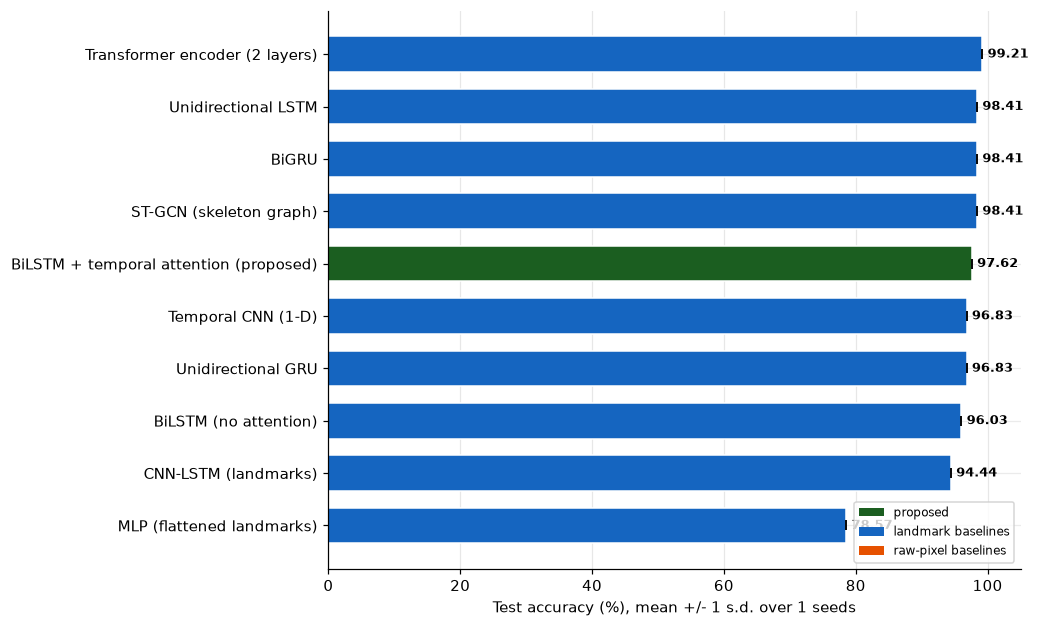

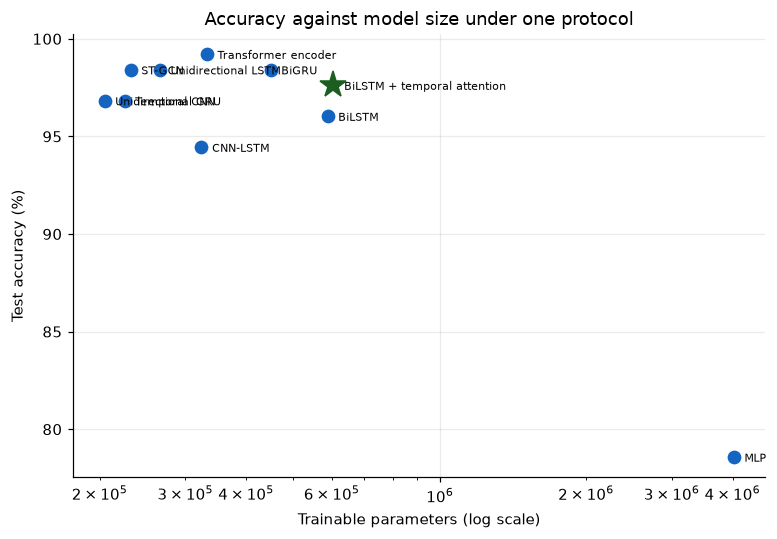


Strongest baseline: Transformer encoder (2 layers) (99.21%)
Proposed margin   : -1.59 pp


In [17]:
RESULTS = {}

print('=' * 78)
print(f'PROPOSED: {PROPOSED}')
print('=' * 78)
# save_model=True so Sections 20, 23, 24, 27 and 28 can load the trained weights instead
# of retraining the best seed just to get a model object back.
RESULTS[PROPOSED] = run_multi_seed(build_proposed, DATA, 'proposed', save_model=True)

for name, fn in LANDMARK_MODELS.items():
    print(f'\n--- {name}')
    RESULTS[name] = run_multi_seed(fn, DATA, name)

if RUN_RAW_FRAME_BASELINES and RAW_FRAMES is not None:
    for name, fn in RAW_MODELS.items():
        print(f'\n--- {name}   (raw pixels; slower)')
        rd = raw_frame_data(seed=0)
        RESULTS[name] = run_multi_seed(lambda f=fn: f(N_CLASSES), rd, name,
                                       seeds=RAW_SEEDS)

# --------------------------------------------------------- Table 7
INPUT_DESC = {
    PROPOSED: f'{FEAT_DIM}-d landmarks',
    'MLP (flattened landmarks)': f'{SEQ_LEN} x {FEAT_DIM} flattened',
    'Temporal CNN (1-D)': f'{FEAT_DIM}-d landmarks',
    'CNN-LSTM (landmarks)': f'{FEAT_DIM}-d landmarks',
    'Unidirectional LSTM': f'{FEAT_DIM}-d landmarks',
    'Unidirectional GRU': f'{FEAT_DIM}-d landmarks',
    'BiGRU': f'{FEAT_DIM}-d landmarks',
    'BiLSTM (no attention)': f'{FEAT_DIM}-d landmarks',
    'Transformer encoder (2 layers)': f'{FEAT_DIM}-d landmarks',
    'ST-GCN (skeleton graph)': f'{N_NODES}-node skeleton graph',
    'Frame-wise CNN (raw 64x64)': f'raw {FRAME_HW} x {FRAME_HW} frames',
    'CNN-LSTM hybrid (raw 64x64)': f'raw {FRAME_HW} x {FRAME_HW} frames',
}
FAMILY = {
    PROPOSED: 'Recurrent + attention',
    'MLP (flattened landmarks)': 'Feed-forward',
    'Temporal CNN (1-D)': 'Convolutional',
    'CNN-LSTM (landmarks)': 'Convolutional + recurrent',
    'Unidirectional LSTM': 'Recurrent',
    'Unidirectional GRU': 'Recurrent',
    'BiGRU': 'Recurrent',
    'BiLSTM (no attention)': 'Recurrent',
    'Transformer encoder (2 layers)': 'Self-attention',
    'ST-GCN (skeleton graph)': 'Graph convolutional',
    'Frame-wise CNN (raw 64x64)': 'Convolutional (pixels)',
    'CNN-LSTM hybrid (raw 64x64)': 'Convolutional + recurrent (pixels)',
}

rows = []
for name, r in RESULTS.items():
    rows.append({
        'Model': name,
        'Family': FAMILY.get(name, ''),
        'Input': INPUT_DESC.get(name, ''),
        'Test accuracy (%)': fmt_pm(r['accuracy_mean'], r['accuracy_std']),
        'Macro F1 (%)': fmt_pm(r['macro_f1_mean'], r['macro_f1_std']),
        'Balanced acc. (%)': fmt_pm(r['balanced_accuracy_mean'], r['balanced_accuracy_std']),
        'Macro AUC': f"{r['macro_auc_mean']:.4f}",
        'Cohen kappa': f"{r['cohen_kappa_mean']:.4f}",
        'Parameters': f"{r['params']:,}",
        'Epochs (mean)': f"{r['epochs_run_mean']:.0f}",
        'Train time (s, mean)': f"{r['train_time_s_mean']:.0f}",
        '_sort': r['accuracy_mean'],
    })
baseline_tbl = (pd.DataFrame(rows).sort_values('_sort', ascending=False)
                .drop(columns='_sort').reset_index(drop=True))
save_table(baseline_tbl, 'table07_baseline_comparison',
    'MANUSCRIPT TABLE 7 / REVIEWER A COMMENT 7. Every architecture the reviewer named -- '
    'MLP, CNN, CNN-LSTM, unidirectional LSTM and GRU, BiGRU, BiLSTM, Transformer encoder, '
    'and a skeleton graph network -- trained under one protocol on one corpus with one '
    'split. This is the only table in the paper that supports a comparative claim; the '
    'cross-study positioning table does not.', 'A7, A9')

full_metrics = []
for name, r in RESULTS.items():
    for run in r['runs']:
        full_metrics.append({'Model': name, 'Seed': run['seed'],
                             **{k: v for k, v in run.items()
                                if isinstance(v, (int, float, str)) and k != 'history'}})
pd.DataFrame(full_metrics).to_csv(f'{OUT_DIR}/tables/all_runs_metrics.csv', index=False)
register('table', 'all_runs_metrics', ['tables/all_runs_metrics.csv'],
         'Every metric of every individual training run: accuracy, balanced accuracy, macro '
         'precision/recall/F1, weighted F1, kappa, MCC, macro AUC, macro AP, top-2 accuracy, '
         'log loss, epochs, best epoch, wall-clock time and parameter count. The complete '
         'record behind every aggregate in the paper.', 'A7, A9')

# --------------------------------------------------------- Figure 5
names = list(baseline_tbl.Model)[::-1]
means = [RESULTS[n]['accuracy_mean'] * 100 for n in names]
stds  = [RESULTS[n]['accuracy_std'] * 100 for n in names]
cols  = [C_MAIN if n == PROPOSED else (C_WARN if 'raw' in INPUT_DESC.get(n, '') else C_ALT)
         for n in names]
fig, ax = plt.subplots(figsize=(9.5, 0.42 * len(names) + 1.6))
ax.barh(names, means, xerr=stds, color=cols, capsize=3.5, edgecolor='white', height=0.68)
for i, (m_, s_) in enumerate(zip(means, stds)):
    ax.text(m_ + s_ + 0.8, i, f'{m_:.2f}', va='center', fontsize=8.5, fontweight='bold')
ax.set_xlabel(f'Test accuracy (%), mean +/- 1 s.d. over {len(SEEDS)} seeds')
ax.set_xlim(0, 105); ax.grid(axis='x', alpha=0.3); ax.set_axisbelow(True)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=C_MAIN, label='proposed'),
                   Patch(facecolor=C_ALT, label='landmark baselines'),
                   Patch(facecolor=C_WARN, label='raw-pixel baselines')],
          loc='lower right', fontsize=8, frameon=True)
plt.tight_layout()
save_fig(fig, 'fig05_baseline_comparison',
         'Manuscript Figure 5. Test accuracy of every architecture under the identical '
         'protocol; bars are the mean over seeds, error bars one standard deviation.', 'A7')

# --------------------------------------------------------- accuracy vs cost
fig, ax = plt.subplots(figsize=(7.2, 5))
for name, r in RESULTS.items():
    is_prop = name == PROPOSED
    ax.errorbar(r['params'], r['accuracy_mean'] * 100, yerr=r['accuracy_std'] * 100,
                fmt='*' if is_prop else 'o', ms=18 if is_prop else 8,
                color=C_MAIN if is_prop else C_ALT, capsize=3, zorder=3 if is_prop else 2)
    ax.annotate(name.split(' (')[0], (r['params'], r['accuracy_mean'] * 100),
                textcoords='offset points', xytext=(7, -3), fontsize=7.5)
ax.set_xscale('log'); ax.set_xlabel('Trainable parameters (log scale)')
ax.set_ylabel('Test accuracy (%)')
ax.set_title('Accuracy against model size under one protocol')
plt.tight_layout()
save_fig(fig, 'fig_accuracy_vs_parameters',
         'Accuracy against parameter count. Supports the Introduction argument (A1) that a '
         'compact landmark model is the appropriate response to a small corpus: the '
         'high-capacity pixel models sit below the compact landmark models.', 'A1, A7, B10')

best_bl = max((n for n in RESULTS if n != PROPOSED),
              key=lambda n: RESULTS[n]['accuracy_mean'])
record('proposed_accuracy_mean', round(RESULTS[PROPOSED]['accuracy_mean'] * 100, 2),
       'Abstract, Section 4.2, Table 7, Conclusions: headline accuracy (mean over seeds)')
record('proposed_accuracy_std', round(RESULTS[PROPOSED]['accuracy_std'] * 100, 2),
       'Table 7: cross-seed standard deviation of the proposed model')
record('proposed_macro_f1_mean', round(RESULTS[PROPOSED]['macro_f1_mean'] * 100, 2),
       'Table 7 and Table 8 macro-average row')
record('proposed_best_accuracy', round(RESULTS[PROPOSED]['best']['accuracy'] * 100, 2),
       'Section 4.2: single-run checkpointed best model, if a single figure is quoted')
record('strongest_baseline', best_bl, 'Section 4.3: the model the proposed one is compared to')
record('strongest_baseline_accuracy', round(RESULTS[best_bl]['accuracy_mean'] * 100, 2),
       'Section 4.3 and Conclusions')
record('margin_over_best_baseline_pp',
       round((RESULTS[PROPOSED]['accuracy_mean'] - RESULTS[best_bl]['accuracy_mean']) * 100, 2),
       'Section 4.3: margin in percentage points over the strongest same-corpus baseline')
print(f'\nStrongest baseline: {best_bl} '
      f'({RESULTS[best_bl]["accuracy_mean"]*100:.2f}%)')
print(f'Proposed margin   : '
      f'{(RESULTS[PROPOSED]["accuracy_mean"]-RESULTS[best_bl]["accuracy_mean"])*100:+.2f} pp')

## 15. Learning curves — manuscript Figure 4

Per-epoch accuracy and loss for the proposed model across every seed, with the held-out test
performance marked. Every run's full history is already on disk in `outputs/histories/`, so
the curve of any model in the comparison can be redrawn from the exported CSVs.

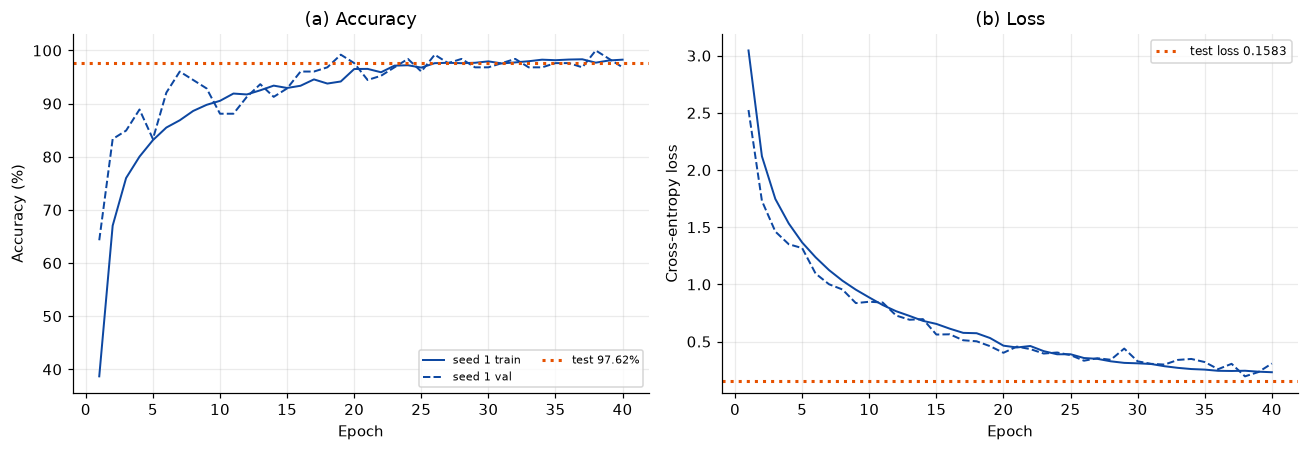


--- table_convergence_summary   [A7]
Convergence behaviour of every architecture: when early stopping fired, peak validation accuracy,
and the train-validation gap that the overfitting discussion in Section 4.2 rests on.


,Model,Epochs to best (mean),Epochs run (mean),Best val accuracy (%),Final train accuracy (%),Train-val gap (pp),"Wall clock (s, mean)"
0,BiLSTM + temporal attention (proposed),38.0,40.0,100.00,98.27,-1.73,1713.0
1,MLP (flattened landmarks),38.0,40.0,84.13,64.74,-19.39,543.0
2,Temporal CNN (1-D),37.0,40.0,100.00,99.83,-0.17,331.0
3,CNN-LSTM (landmarks),38.0,40.0,97.62,98.90,1.28,666.0
4,Unidirectional LSTM,40.0,40.0,97.62,93.28,-4.33,1070.0
5,Unidirectional GRU,36.0,40.0,97.62,97.75,0.13,1040.0
6,BiGRU,33.0,40.0,100.00,98.19,-1.81,1287.0
7,BiLSTM (no attention),39.0,40.0,96.83,96.07,-0.76,1729.0
8,Transformer encoder (2 layers),40.0,40.0,99.21,99.80,0.60,774.0
9,ST-GCN (skeleton graph),40.0,40.0,100.00,100.00,0.00,19651.0


-1.73

In [18]:
prop = RESULTS[PROPOSED]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for k, run in enumerate(prop['runs']):
    h = run['history']
    ep = np.arange(1, len(h['accuracy']) + 1)
    axes[0].plot(ep, np.array(h['accuracy']) * 100, color=C_SEQ[k], lw=1.3,
                 label=f'seed {run["seed"]} train')
    axes[0].plot(ep, np.array(h['val_accuracy']) * 100, color=C_SEQ[k], lw=1.3, ls='--',
                 label=f'seed {run["seed"]} val')
    axes[1].plot(ep, h['loss'], color=C_SEQ[k], lw=1.3)
    axes[1].plot(ep, h['val_loss'], color=C_SEQ[k], lw=1.3, ls='--')
axes[0].axhline(prop['best']['accuracy'] * 100, color=C_WARN, ls=':', lw=2,
                label=f'test {prop["best"]["accuracy"]*100:.2f}%')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('(a) Accuracy'); axes[0].legend(fontsize=7, ncol=2, loc='lower right')
axes[1].axhline(prop['best']['log_loss'], color=C_WARN, ls=':', lw=2,
                label=f'test loss {prop["best"]["log_loss"]:.4f}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Cross-entropy loss')
axes[1].set_title('(b) Loss'); axes[1].legend(fontsize=8)
plt.tight_layout()
save_fig(fig, 'fig04_learning_curves',
         'Manuscript Figure 4. Training (solid) and validation (dashed) trajectories of the '
         'proposed model for every seed; dotted lines mark held-out test performance. The '
         'narrow train-validation gap is the evidence for the regularization claim in '
         'Section 4.2.', 'A7')

conv = pd.DataFrame([{'Model': n,
                      'Epochs to best (mean)': round(np.mean([r['best_epoch']
                                                              for r in v['runs']]), 1),
                      'Epochs run (mean)': round(v['epochs_run_mean'], 1),
                      'Best val accuracy (%)': round(np.mean([r['best_val_accuracy']
                                                              for r in v['runs']]) * 100, 2),
                      'Final train accuracy (%)': round(np.mean([r['final_train_accuracy']
                                                                 for r in v['runs']]) * 100, 2),
                      'Train-val gap (pp)': round((np.mean([r['final_train_accuracy']
                                                            for r in v['runs']])
                                                   - np.mean([r['best_val_accuracy']
                                                              for r in v['runs']])) * 100, 2),
                      'Wall clock (s, mean)': round(v['train_time_s_mean'], 0)}
                     for n, v in RESULTS.items()])
save_table(conv, 'table_convergence_summary',
           'Convergence behaviour of every architecture: when early stopping fired, peak '
           'validation accuracy, and the train-validation gap that the overfitting '
           'discussion in Section 4.2 rests on.', 'A7')
record('proposed_best_epoch',
       int(np.mean([r['best_epoch'] for r in prop['runs']])),
       'Figure 4 caption: the epoch at which early stopping restored the best weights')
record('proposed_train_val_gap_pp',
       float(conv[conv.Model == PROPOSED]['Train-val gap (pp)'].iloc[0]),
       'Section 4.2: the train-validation gap behind the regularization claim')

## 16. Evaluation of the proposed model — **Reviewer B comments 13, 8 and 9**

Four things happen here.

**The confusion matrix is reported as absolute counts with the percentage in parentheses**
(`17 (94.4%)`), which is what Reviewer B comment 13 asks for: with 18 test clips per class a
single error moves the percentage by 5.56 points, so a percentage-only matrix overstates its
own precision.

**Per-class metrics** reuse exactly the same test partition, so Table 8's support column and
the confusion matrix row sums agree by construction.

**ROC and precision-recall curves, kappa, MCC, balanced accuracy and top-2 accuracy** are
added because the manuscript currently reports only accuracy, precision, recall and F1 —
adequate measures, but not enough to characterize a 7-class problem on 126 samples.

**A confidence-threshold sweep** quantifies the trade-off between coverage and accuracy.
Algorithm 1 in the manuscript contains a threshold `τ` whose value was never specified and
never justified; this sweep is what lets you specify it, and it is also the concrete answer
to the deployment concern that a misclassification is spoken back as fluent, confident
speech.

All of these describe the **recognition stage only**. The synthesis stage is not evaluated
here and cannot be (B8, B9).

Proposed model, seed 1 (checkpointed best run)

              precision    recall  f1-score   support

       nenda     1.0000    0.9444    0.9714        18
       njema     1.0000    1.0000    1.0000        18
        mama     0.9474    1.0000    0.9730        18
       hedhi     0.9474    1.0000    0.9730        18
        kula     0.9474    1.0000    0.9730        18
        baba     1.0000    0.9444    0.9714        18
      habari     1.0000    0.9444    0.9714        18

    accuracy                         0.9762       126
   macro avg     0.9774    0.9762    0.9762       126
weighted avg     0.9774    0.9762    0.9762       126


--- table08_per_class_metrics   [B13]
Manuscript Table 8. Per-class precision, recall and F1 on the held-out test partition, with the
absolute correct/error counts alongside, so the percentages can be read against the 18-clip support
they rest on (Reviewer B comment 13).


,Class (gloss),Precision (%),Recall (%),F1-score (%),Support,Correct,Errors
0,nenda (go),100.00,94.44,97.14,18,17,1
1,njema (good),100.00,100.00,100.00,18,18,0
2,mama (mother),94.74,100.00,97.30,18,18,0
3,hedhi (menstruation),94.74,100.00,97.30,18,18,0
4,kula (eat),94.74,100.00,97.30,18,18,0
5,baba (father),100.00,94.44,97.14,18,17,1
6,habari (hi),100.00,94.44,97.14,18,17,1
7,Macro average,97.74,97.62,97.62,126,123,3



--- table08b_per_class_metrics_multiseed   [B13, A9]
Per-class metrics as mean +/- s.d. over 1 seeds. Preferable to the single-run table above wherever
the manuscript can accommodate it, because a single run on 18 clips per class is not a stable
estimate.


,Class (gloss),Precision (%),Recall (%),F1-score (%),Support
0,nenda (go),100.00 +/- 0.00,94.44 +/- 0.00,97.14 +/- 0.00,18
1,njema (good),100.00 +/- 0.00,100.00 +/- 0.00,100.00 +/- 0.00,18
2,mama (mother),94.74 +/- 0.00,100.00 +/- 0.00,97.30 +/- 0.00,18
3,hedhi (menstruation),94.74 +/- 0.00,100.00 +/- 0.00,97.30 +/- 0.00,18
4,kula (eat),94.74 +/- 0.00,100.00 +/- 0.00,97.30 +/- 0.00,18
5,baba (father),100.00 +/- 0.00,94.44 +/- 0.00,97.14 +/- 0.00,18
6,habari (hi),100.00 +/- 0.00,94.44 +/- 0.00,97.14 +/- 0.00,18


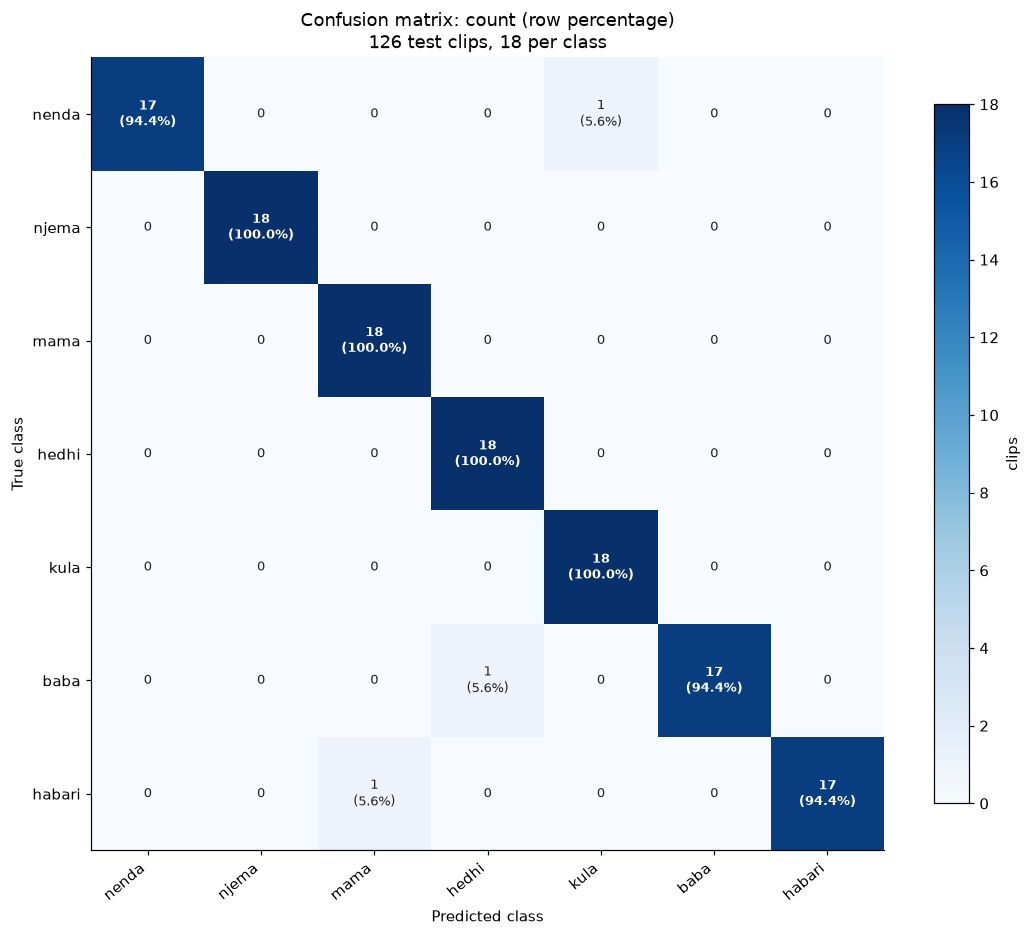


--- table_confusion_matrix_counts   [B13]
The confusion matrix as text in the "17 (94.4%)" format, ready to paste into the manuscript.


,True \ Predicted,nenda,njema,mama,hedhi,kula,baba,habari
0,nenda,17\n(94.4%),0,0,0,1\n(5.6%),0,0
1,njema,0,18\n(100.0%),0,0,0,0,0
2,mama,0,0,18\n(100.0%),0,0,0,0
3,hedhi,0,0,0,18\n(100.0%),0,0,0
4,kula,0,0,0,0,18\n(100.0%),0,0
5,baba,0,0,0,1\n(5.6%),0,17\n(94.4%),0
6,habari,0,0,1\n(5.6%),0,0,0,17\n(94.4%)



--- table_confusion_pairs   [B4, B13]
Every confused class pair, ranked. Replaces the assertion in Section 4.4 that confusions occur
"between gestures with similar intermediate hand shapes" with the list of pairs that actually
confuse, which §21 then relates to the measured gesture characteristics.


,True class,Predicted as,Count over all seeds
0,nenda,kula,1
1,baba,hedhi,1
2,habari,mama,1



--- table_overall_metrics_proposed   [B8, B9]
Every aggregate metric for the proposed recognition model, as the checkpointed best run and as mean
+/- s.d. over seeds. These figures characterize the RECOGNITION stage only; the speech-synthesis
stage is a pretrained component and is not evaluated anywhere in this study (Reviewer B comments 8
and 9).


,Metric,Best run,Mean over 1 seeds,Std
0,Accuracy (%),97.6190,97.6190,0.0
1,Balanced accuracy (%),97.6190,97.6190,0.0
2,Macro precision (%),97.7444,97.7444,0.0
3,Macro recall (%),97.6190,97.6190,0.0
4,Macro F1 (%),97.6172,97.6172,0.0
5,Top-2 accuracy (%),98.4127,98.4127,0.0
6,Cohen kappa,0.9722,0.9722,0.0
7,Matthews correlation,0.9724,0.9724,0.0
8,Macro ROC AUC,0.9985,0.9985,0.0
9,Cross-entropy loss,0.1583,0.1583,0.0


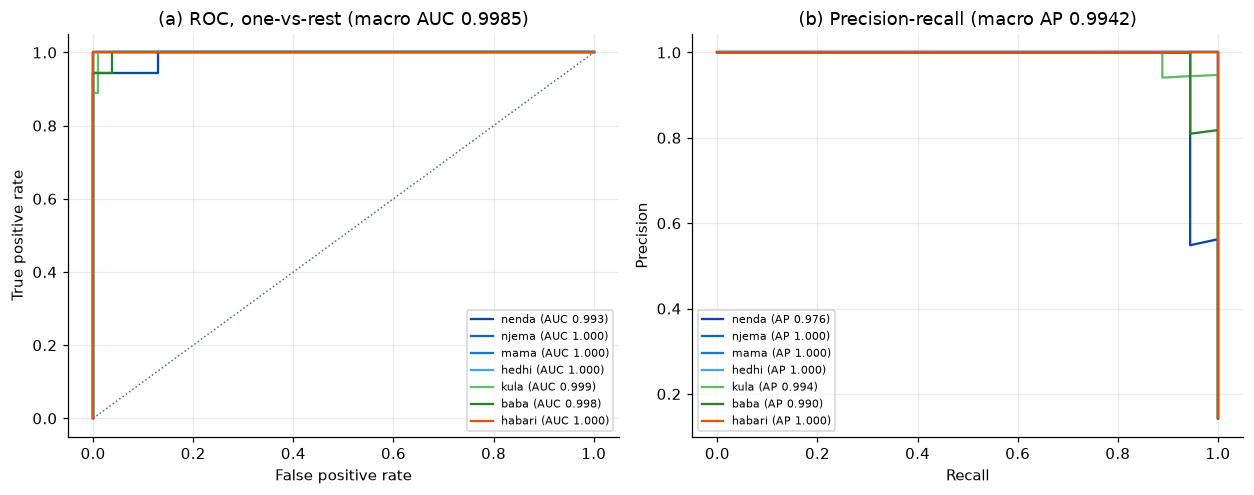


--- table_calibration_bins   [B14]
Reliability of the softmax confidence. Expected calibration error = 0.0164. Relevant because
Algorithm 1 gates speech output on a confidence threshold, which is only meaningful if the
confidence is calibrated.


,Confidence bin,Samples,Mean confidence,Accuracy,Gap
0,"(0.7, 0.8]",3,0.7559,0.6667,-0.0892
1,"(0.8, 0.9]",1,0.8985,1.0000,0.1015
2,"(0.9, 1.0]",122,0.9975,0.9836,-0.0139



--- table_confidence_threshold_sweep   [B14]
Coverage against accuracy as the confidence threshold tau of Algorithm 1 varies. The row where
"Errors spoken" first reaches zero is the value to quote when arguing that suppressing low-
confidence output is a viable safeguard; the coverage column is the price paid for it.


,Threshold tau,Coverage (%),Clips answered,Accuracy on answered (%),Errors spoken,Clips withheld
0,0.000,100.00,126,97.62,3,0
1,0.025,100.00,126,97.62,3,0
2,0.050,100.00,126,97.62,3,0
3,0.075,100.00,126,97.62,3,0
4,0.100,100.00,126,97.62,3,0
5,0.125,100.00,126,97.62,3,0
6,0.150,100.00,126,97.62,3,0
7,0.175,100.00,126,97.62,3,0
8,0.200,100.00,126,97.62,3,0
9,0.225,100.00,126,97.62,3,0


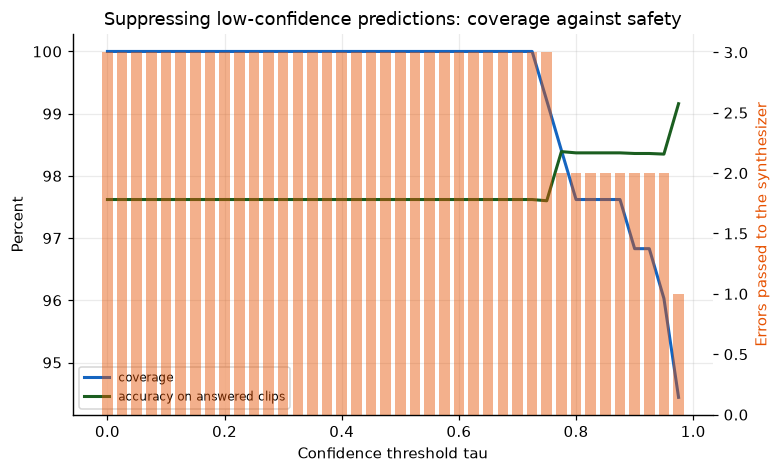


Wrote per-sample predictions for 10 architectures.


In [19]:
best = prop['best']
pred, proba = best['pred'], best['proba']
print(f'Proposed model, seed {best["seed"]} (checkpointed best run)\n')
print(classification_report(yte, pred, labels=np.arange(N_CLASSES),
                            target_names=CLASS_LIST, digits=4, zero_division=0))

# -------------------------------------------------- Table 8: per-class metrics
p, r, f1, sup = precision_recall_fscore_support(yte, pred, labels=np.arange(N_CLASSES),
                                                zero_division=0)
cm = confusion_matrix(yte, pred, labels=np.arange(N_CLASSES))
t8 = pd.DataFrame({
    'Class (gloss)': [f'{c} ({GLOSS_EN.get(c, "")})' for c in CLASS_LIST],
    'Precision (%)': (p * 100).round(2),
    'Recall (%)': (r * 100).round(2),
    'F1-score (%)': (f1 * 100).round(2),
    'Support': sup,
    'Correct': cm.diagonal(),
    'Errors': sup - cm.diagonal(),
})
t8.loc[len(t8)] = ['Macro average', round(p.mean() * 100, 2), round(r.mean() * 100, 2),
                   round(f1.mean() * 100, 2), sup.sum(), cm.diagonal().sum(),
                   sup.sum() - cm.diagonal().sum()]
save_table(t8, 'table08_per_class_metrics',
           'Manuscript Table 8. Per-class precision, recall and F1 on the held-out test '
           'partition, with the absolute correct/error counts alongside, so the percentages '
           'can be read against the 18-clip support they rest on (Reviewer B comment 13).',
           'B13')

# per-class metrics averaged over seeds, which is the more defensible version
pc_rows = []
for ci, c in enumerate(CLASS_LIST):
    accs = []
    for run in prop['runs']:
        pp, rr, ff, ss = precision_recall_fscore_support(
            yte, run['pred'], labels=np.arange(N_CLASSES), zero_division=0)
        accs.append((pp[ci], rr[ci], ff[ci]))
    a = np.array(accs)
    pc_rows.append({'Class (gloss)': f'{c} ({GLOSS_EN.get(c, "")})',
                    'Precision (%)': fmt_pm(a[:, 0].mean(), a[:, 0].std()),
                    'Recall (%)': fmt_pm(a[:, 1].mean(), a[:, 1].std()),
                    'F1-score (%)': fmt_pm(a[:, 2].mean(), a[:, 2].std()),
                    'Support': int(sup[ci])})
save_table(pd.DataFrame(pc_rows), 'table08b_per_class_metrics_multiseed',
           f'Per-class metrics as mean +/- s.d. over {len(SEEDS)} seeds. Preferable to the '
           'single-run table above wherever the manuscript can accommodate it, because a '
           'single run on 18 clips per class is not a stable estimate.', 'B13, A9')

# ------------------------------------------- B13: counts-with-percentage matrix
cm_pct = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1) * 100
annot = np.array([[f'{cm[i,j]}\n({cm_pct[i,j]:.1f}%)' if cm[i, j] else '0'
                   for j in range(N_CLASSES)] for i in range(N_CLASSES)])
fig, ax = plt.subplots(figsize=(1.12 * N_CLASSES + 2.2, 1.0 * N_CLASSES + 1.8))
im = ax.imshow(cm, cmap='Blues', vmin=0)
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, annot[i, j], ha='center', va='center', fontsize=8.5,
                fontweight='bold' if i == j else 'normal',
                color='white' if cm[i, j] > cm.max() * 0.6 else '#212121')
ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(CLASS_LIST, rotation=40, ha='right')
ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(CLASS_LIST)
ax.set_xlabel('Predicted class'); ax.set_ylabel('True class')
ax.set_title(f'Confusion matrix: count (row percentage)\n'
             f'{len(yte)} test clips, {len(yte)//N_CLASSES} per class')
ax.grid(False)
plt.colorbar(im, shrink=0.8, label='clips')
plt.tight_layout()
save_fig(fig, 'fig06_confusion_matrix_counts',
         'Manuscript Figure 6, in the format Reviewer B comment 13 requested: absolute '
         'counts with the row percentage in parentheses. With 18 clips per class one error '
         'is 5.56 percentage points, so counts carry the information and percentages alone '
         'do not.', 'B13')

cm_out = pd.DataFrame(annot, index=CLASS_LIST, columns=CLASS_LIST)
cm_out.index.name = 'True \\ Predicted'
save_table(cm_out.reset_index(), 'table_confusion_matrix_counts',
           'The confusion matrix as text in the "17 (94.4%)" format, ready to paste into '
           'the manuscript.', 'B13')
pd.DataFrame(cm, index=CLASS_LIST, columns=CLASS_LIST).to_csv(
    f'{OUT_DIR}/tables/confusion_matrix_raw_counts.csv')

# aggregate confusion over all seeds
cm_sum = sum(confusion_matrix(yte, run['pred'], labels=np.arange(N_CLASSES))
             for run in prop['runs'])
pd.DataFrame(cm_sum, index=CLASS_LIST, columns=CLASS_LIST).to_csv(
    f'{OUT_DIR}/tables/confusion_matrix_summed_over_seeds.csv')
register('table', 'confusion_matrix_summed_over_seeds',
         ['tables/confusion_matrix_summed_over_seeds.csv'],
         f'Confusion counts summed over {len(SEEDS)} seeds ({len(yte)*len(SEEDS)} decisions). '
         'A more stable picture of which class pairs actually confuse than any single run.',
         'B13')

off = [(CLASS_LIST[i], CLASS_LIST[j], int(cm_sum[i, j]))
       for i in range(N_CLASSES) for j in range(N_CLASSES)
       if i != j and cm_sum[i, j] > 0]
if off:
    save_table(pd.DataFrame(sorted(off, key=lambda t: -t[2]),
                            columns=['True class', 'Predicted as', 'Count over all seeds']),
               'table_confusion_pairs',
               'Every confused class pair, ranked. Replaces the assertion in Section 4.4 '
               'that confusions occur "between gestures with similar intermediate hand '
               'shapes" with the list of pairs that actually confuse, which §21 then '
               'relates to the measured gesture characteristics.', 'B4, B13')
else:
    print('\nNo off-diagonal mass: the model made no errors on this test partition.')

# ------------------------------------------------ overall metrics, all seeds
overall = pd.DataFrame([{
    'Metric': k,
    'Best run': round(best[m] * (100 if k.endswith('(%)') else 1), 4),
    f'Mean over {len(SEEDS)} seeds': round(prop[f'{m}_mean'] * (100 if k.endswith('(%)') else 1), 4),
    'Std': round(prop[f'{m}_std'] * (100 if k.endswith('(%)') else 1), 4),
} for k, m in [('Accuracy (%)', 'accuracy'), ('Balanced accuracy (%)', 'balanced_accuracy'),
               ('Macro precision (%)', 'macro_precision'), ('Macro recall (%)', 'macro_recall'),
               ('Macro F1 (%)', 'macro_f1'), ('Top-2 accuracy (%)', 'top2_accuracy'),
               ('Cohen kappa', 'cohen_kappa'), ('Matthews correlation', 'mcc'),
               ('Macro ROC AUC', 'macro_auc'), ('Cross-entropy loss', 'log_loss')]])
save_table(overall, 'table_overall_metrics_proposed',
           'Every aggregate metric for the proposed recognition model, as the checkpointed '
           'best run and as mean +/- s.d. over seeds. These figures characterize the '
           'RECOGNITION stage only; the speech-synthesis stage is a pretrained component '
           'and is not evaluated anywhere in this study (Reviewer B comments 8 and 9).',
           'B8, B9')

# --------------------------------------------------------- ROC and PR curves
onehot = np.eye(N_CLASSES)[yte]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
for ci, c in enumerate(CLASS_LIST):
    fpr, tpr, _ = roc_curve(onehot[:, ci], proba[:, ci])
    axes[0].plot(fpr, tpr, color=C_SEQ[ci % len(C_SEQ)], lw=1.5,
                 label=f'{c} (AUC {roc_auc_score(onehot[:, ci], proba[:, ci]):.3f})')
    pr, rc, _ = precision_recall_curve(onehot[:, ci], proba[:, ci])
    axes[1].plot(rc, pr, color=C_SEQ[ci % len(C_SEQ)], lw=1.5,
                 label=f'{c} (AP {average_precision_score(onehot[:, ci], proba[:, ci]):.3f})')
axes[0].plot([0, 1], [0, 1], ls=':', color=C_GREY, lw=1)
axes[0].set_xlabel('False positive rate'); axes[0].set_ylabel('True positive rate')
axes[0].set_title(f'(a) ROC, one-vs-rest (macro AUC {best["macro_auc"]:.4f})')
axes[0].legend(fontsize=7, loc='lower right')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title(f'(b) Precision-recall (macro AP {best["macro_ap"]:.4f})')
axes[1].legend(fontsize=7, loc='lower left')
plt.tight_layout()
save_fig(fig, 'fig_roc_pr_curves',
         'One-vs-rest ROC and precision-recall curves per class. Threshold-free evidence '
         'that complements the single operating point the confusion matrix reports.', 'B13')

# ---------------------------------- calibration and the confidence threshold
def expected_calibration_error(y_true, proba, n_bins=10):
    conf = proba.max(1); correct = (proba.argmax(1) == y_true).astype(float)
    edges = np.linspace(0, 1, n_bins + 1)
    ece, rows = 0.0, []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.sum():
            acc, cf = correct[m].mean(), conf[m].mean()
            ece += m.mean() * abs(acc - cf)
            rows.append({'Confidence bin': f'({lo:.1f}, {hi:.1f}]', 'Samples': int(m.sum()),
                         'Mean confidence': round(float(cf), 4),
                         'Accuracy': round(float(acc), 4),
                         'Gap': round(float(acc - cf), 4)})
    return float(ece), pd.DataFrame(rows)

ece, cal_tbl = expected_calibration_error(yte, proba)
save_table(cal_tbl, 'table_calibration_bins',
           f'Reliability of the softmax confidence. Expected calibration error = {ece:.4f}. '
           'Relevant because Algorithm 1 gates speech output on a confidence threshold, '
           'which is only meaningful if the confidence is calibrated.', 'B14')
record('expected_calibration_error', round(ece, 4),
       'Section 4.7.2: whether the confidence threshold in Algorithm 1 is trustworthy')

taus = np.round(np.arange(0.0, 1.0, 0.025), 3)
sweep = []
conf = proba.max(1)
for t in taus:
    keep = conf >= t
    sweep.append({'Threshold tau': t,
                  'Coverage (%)': round(float(keep.mean() * 100), 2),
                  'Clips answered': int(keep.sum()),
                  'Accuracy on answered (%)': round(float(
                      (pred[keep] == yte[keep]).mean() * 100), 2) if keep.any() else np.nan,
                  'Errors spoken': int((pred[keep] != yte[keep]).sum()) if keep.any() else 0,
                  'Clips withheld': int((~keep).sum())})
sweep = pd.DataFrame(sweep)
save_table(sweep, 'table_confidence_threshold_sweep',
           'Coverage against accuracy as the confidence threshold tau of Algorithm 1 varies. '
           'The row where "Errors spoken" first reaches zero is the value to quote when '
           'arguing that suppressing low-confidence output is a viable safeguard; the '
           'coverage column is the price paid for it.', 'B14')

fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.plot(sweep['Threshold tau'], sweep['Coverage (%)'], color=C_ALT, lw=2, label='coverage')
ax.plot(sweep['Threshold tau'], sweep['Accuracy on answered (%)'], color=C_MAIN, lw=2,
        label='accuracy on answered clips')
ax2 = ax.twinx()
ax2.bar(sweep['Threshold tau'], sweep['Errors spoken'], width=0.018, color=C_WARN,
        alpha=0.45, label='errors passed to speech')
ax2.set_ylabel('Errors passed to the synthesizer', color=C_WARN)
ax2.grid(False)
ax.set_xlabel('Confidence threshold tau'); ax.set_ylabel('Percent')
ax.set_title('Suppressing low-confidence predictions: coverage against safety')
ax.legend(loc='lower left', fontsize=8)
plt.tight_layout()
save_fig(fig, 'fig_confidence_threshold',
         'The operating curve behind the confidence threshold in Algorithm 1: how much '
         'coverage must be given up to stop errors reaching the speech stage.', 'B14')

# ------------------------------------------------- per-sample prediction dump
pred_dump = pd.DataFrame({
    'clip_id': ids_raw[te_i], 'filename': f_raw[te_i], 'signer': g_raw[te_i],
    'true_class': [CLASS_LIST[i] for i in yte],
    'predicted_class': [CLASS_LIST[i] for i in pred],
    'correct': (pred == yte), 'confidence': proba.max(1).round(6),
})
for ci, c in enumerate(CLASS_LIST):
    pred_dump[f'p_{c}'] = proba[:, ci].round(6)
pred_dump.to_csv(f'{OUT_DIR}/predictions/test_predictions_proposed.csv', index=False)
for name, r in RESULTS.items():
    for run in r['runs']:
        if run.get('proba') is None:
            continue
        pd.DataFrame({'clip_id': ids_raw[te_i],
                      'true_class': [CLASS_LIST[i] for i in yte],
                      'predicted_class': [CLASS_LIST[i] for i in run['pred']],
                      'confidence': np.asarray(run['proba']).max(1).round(6)}).to_csv(
            f'{OUT_DIR}/predictions/{run_key(name, run["seed"])}.csv', index=False)
register('record', 'test_predictions',
         ['predictions/test_predictions_proposed.csv', 'predictions/'],
         'Clip-level predictions with the full class posterior for the proposed model, and '
         'predicted labels for every run of every architecture. Lets any reviewer '
         'recompute every metric in the paper from scratch.', 'A9, A14')
print(f'\nWrote per-sample predictions for {len(RESULTS)} architectures.')

## 17. Statistical significance — **Reviewer A comment 9**

The reviewer's point is that a gap between two averages does not establish superiority.
Three tests address it, all on the same test clips:

* **McNemar's exact test** on the paired correct/incorrect decisions of the proposed model
  against *every* baseline, with **Holm–Bonferroni** correction because there are many
  comparisons.
* **Bootstrap confidence intervals** on the accuracy of each model and on the paired
  difference from the proposed model — the interval on the *difference* is the quantity that
  matters, and it is reported directly.
* **Paired tests across seeds** on the per-seed accuracies.

With 126 test clips these intervals are wide. That is the honest result, and reporting it is
what makes the comparative claim defensible rather than decorative.

In [20]:
from statsmodels.stats.contingency_tables import mcnemar
from scipy import stats as sstats

correct_prop = (pred == yte)

mc_rows = []
for name, r in RESULTS.items():
    if name == PROPOSED:
        continue
    cb = (r['best']['pred'] == yte)
    tab = [[int((correct_prop & cb).sum()), int((correct_prop & ~cb).sum())],
           [int((~correct_prop & cb).sum()), int((~correct_prop & ~cb).sum())]]
    n_disc = tab[0][1] + tab[1][0]
    res = mcnemar(tab, exact=(n_disc < 25), correction=True)
    mc_rows.append({
        'Comparator': name,
        'Both correct': tab[0][0], 'Proposed only': tab[0][1],
        'Comparator only': tab[1][0], 'Both wrong': tab[1][1],
        'Discordant pairs': n_disc,
        'Test': 'exact binomial' if n_disc < 25 else 'chi-square with continuity correction',
        'p-value (raw)': res.pvalue,
    })
mc = pd.DataFrame(mc_rows).sort_values('p-value (raw)').reset_index(drop=True)

# Holm-Bonferroni over the family of comparisons
m = len(mc)
adj, running = [], 0.0
for k, praw in enumerate(mc['p-value (raw)']):
    running = max(running, min(1.0, praw * (m - k)))
    adj.append(running)
mc['p-value (Holm-adjusted)'] = np.round(adj, 6)
mc['Significant at 0.05'] = np.where(mc['p-value (Holm-adjusted)'] < 0.05, 'yes', 'no')
mc['p-value (raw)'] = mc['p-value (raw)'].round(6)
save_table(mc, 'table_mcnemar_tests',
           'REVIEWER A COMMENT 9. McNemar exact tests of the proposed model against every '
           'baseline on the identical test clips, with Holm-Bonferroni correction for the '
           'family of comparisons. Only the rows marked "yes" support a claim of '
           'superiority; for the rest the paper should say the difference is not '
           'statistically distinguishable on this test set.', 'A9')
json.dump(mc.to_dict('records'), open(f'{OUT_DIR}/mcnemar_tests.json', 'w'),
          indent=2, default=str)

# ------------------------------------------------------- bootstrap intervals
rng = np.random.default_rng(GLOBAL_SEED)
n = len(yte)
boot_idx = rng.integers(0, n, size=(N_BOOTSTRAP, n))

def boot_acc(correct_mask):
    return correct_mask[boot_idx].mean(axis=1)

boot_rows = []
acc_prop_boot = boot_acc(correct_prop)
for name, r in RESULTS.items():
    cmask = (r['best']['pred'] == yte)
    b = boot_acc(cmask)
    lo, hi = np.percentile(b, [2.5, 97.5])
    row = {'Model': name,
           'Accuracy (%)': round(float(cmask.mean() * 100), 2),
           '95% CI lower (%)': round(float(lo * 100), 2),
           '95% CI upper (%)': round(float(hi * 100), 2),
           'CI width (pp)': round(float((hi - lo) * 100), 2)}
    if name != PROPOSED:
        d = acc_prop_boot - b
        dlo, dhi = np.percentile(d, [2.5, 97.5])
        row.update({'Difference from proposed (pp)': round(float(d.mean() * 100), 2),
                    'Difference 95% CI (pp)': f'[{dlo*100:.2f}, {dhi*100:.2f}]',
                    'CI excludes zero': 'yes' if (dlo > 0 or dhi < 0) else 'no'})
    else:
        row.update({'Difference from proposed (pp)': 0.0,
                    'Difference 95% CI (pp)': '-', 'CI excludes zero': '-'})
    boot_rows.append(row)
boot_tbl = pd.DataFrame(boot_rows).sort_values('Accuracy (%)', ascending=False)
save_table(boot_tbl, 'table_bootstrap_confidence_intervals',
           f'Percentile bootstrap ({N_BOOTSTRAP:,} resamples of the {n} test clips) on each '
           'model accuracy, and on the paired difference from the proposed model. The '
           'difference interval is the decisive column: where it contains zero, the '
           'manuscript must not claim an advantage.', 'A9')

# ------------------------------------------------------ seed-level paired tests
seed_rows = []
a_prop = np.array(prop['accuracy_values'], float)
for name, r in RESULTS.items():
    if name == PROPOSED:
        continue
    a_bl = np.array(r['accuracy_values'], float)
    row = {'Comparator': name,
           'Proposed (mean %)': round(float(a_prop.mean() * 100), 2),
           'Comparator (mean %)': round(float(a_bl.mean() * 100), 2),
           'Mean difference (pp)': round(float((a_prop.mean() - a_bl.mean()) * 100), 2),
           'Seeds': f'{len(a_prop)} vs {len(a_bl)}' if len(a_prop) != len(a_bl)
                    else len(a_prop)}
    # Paired tests need one observation per matched seed. The raw-pixel baselines may have
    # been run over fewer seeds, in which case only the unpaired means are comparable.
    if len(a_prop) == len(a_bl) and len(a_prop) >= 3 and np.ptp(a_prop - a_bl) > 0:
        t, pt = sstats.ttest_rel(a_prop, a_bl)
        try:
            w, pw = sstats.wilcoxon(a_prop, a_bl)
        except Exception:
            pw = np.nan
        sd = (a_prop - a_bl).std(ddof=1)
        row.update({'Paired t p-value': round(float(pt), 5),
                    'Wilcoxon p-value': (round(float(pw), 5) if pw == pw else np.nan),
                    "Cohen's d_z": round(float((a_prop - a_bl).mean() / sd), 3) if sd else np.nan})
    else:
        row.update({'Paired t p-value': np.nan, 'Wilcoxon p-value': np.nan,
                    "Cohen's d_z": np.nan})
    seed_rows.append(row)
if seed_rows:
    save_table(pd.DataFrame(seed_rows).sort_values('Mean difference (pp)', ascending=False),
               'table_seed_level_tests',
               f'Paired tests across the {len(SEEDS)} initialization seeds. With so few '
               'seeds these p-values have very little power and are reported for '
               'completeness; the McNemar tests on the paired clip-level decisions are the '
               'stronger evidence.', 'A9')

sig = mc[mc['Significant at 0.05'] == 'yes']
print(f'\nBaselines the proposed model beats at Holm-adjusted p < 0.05: '
      f'{len(sig)} of {len(mc)}')
if len(sig):
    for _, row in sig.iterrows():
        print(f'   {row["Comparator"]}: p_adj = {row["p-value (Holm-adjusted)"]:.4f}')
else:
    print('   none. State in Section 4.3 that the ranking is not statistically separable on '
          '126 test clips, and rely on the cross-validation estimate instead.')
record('n_baselines_significantly_beaten', int(len(sig)),
       'Section 4.3: how many baselines the proposed model separates from at p<0.05')
_ci = boot_tbl[boot_tbl.Model == PROPOSED].iloc[0]
record('proposed_accuracy_ci',
       f'[{_ci["95% CI lower (%)"]}, {_ci["95% CI upper (%)"]}]',
       'Abstract and Section 4.2: the 95% bootstrap interval to quote alongside the point '
       'accuracy')


--- table_mcnemar_tests   [A9]
REVIEWER A COMMENT 9. McNemar exact tests of the proposed model against every baseline on the
identical test clips, with Holm-Bonferroni correction for the family of comparisons. Only the rows
marked "yes" support a claim of superiority; for the rest the paper should say the difference is not
statistically distinguishable on this test set.


,Comparator,Both correct,Proposed only,Comparator only,Both wrong,Discordant pairs,Test,p-value (raw),p-value (Holm-adjusted),Significant at 0.05
0,MLP (flattened landmarks),98,25,1,2,26,chi-square with continuity correction,0.000006,0.000058,yes
1,CNN-LSTM (landmarks),118,5,1,2,6,exact binomial,0.218750,1.000000,no
2,Transformer encoder (2 layers),123,0,2,1,2,exact binomial,0.500000,1.000000,no
3,BiLSTM (no attention),120,3,1,2,4,exact binomial,0.625000,1.000000,no
4,Temporal CNN (1-D),121,2,1,2,3,exact binomial,1.000000,1.000000,no
5,Unidirectional LSTM,122,1,2,1,3,exact binomial,1.000000,1.000000,no
6,Unidirectional GRU,121,2,1,2,3,exact binomial,1.000000,1.000000,no
7,BiGRU,122,1,2,1,3,exact binomial,1.000000,1.000000,no
8,ST-GCN (skeleton graph),122,1,2,1,3,exact binomial,1.000000,1.000000,no



--- table_bootstrap_confidence_intervals   [A9]
Percentile bootstrap (2,000 resamples of the 126 test clips) on each model accuracy, and on the
paired difference from the proposed model. The difference interval is the decisive column: where it
contains zero, the manuscript must not claim an advantage.


,Model,Accuracy (%),95% CI lower (%),95% CI upper (%),CI width (pp),Difference from proposed (pp),Difference 95% CI (pp),CI excludes zero
8,Transformer encoder (2 layers),99.21,97.62,100.00,2.38,-1.54,"[-3.97, 0.00]",no
4,Unidirectional LSTM,98.41,96.03,100.00,3.97,-0.77,"[-3.17, 1.59]",no
6,BiGRU,98.41,96.03,100.00,3.97,-0.77,"[-3.19, 1.59]",no
9,ST-GCN (skeleton graph),98.41,96.03,100.00,3.97,-0.72,"[-3.97, 1.59]",no
0,BiLSTM + temporal attention (proposed),97.62,94.44,100.00,5.56,0.00,-,-
2,Temporal CNN (1-D),96.83,92.86,99.21,6.35,0.85,"[-1.59, 3.97]",no
5,Unidirectional GRU,96.83,93.65,99.21,5.56,0.80,"[-1.59, 3.17]",no
7,BiLSTM (no attention),96.03,92.06,99.21,7.14,1.62,"[-1.59, 4.76]",no
3,CNN-LSTM (landmarks),94.44,89.68,98.41,8.73,3.21,"[-0.02, 7.14]",no
1,MLP (flattened landmarks),78.57,71.43,84.92,13.49,19.05,"[11.90, 26.19]",yes



--- table_seed_level_tests   [A9]
Paired tests across the 1 initialization seeds. With so few seeds these p-values have very little
power and are reported for completeness; the McNemar tests on the paired clip-level decisions are
the stronger evidence.


,Comparator,Proposed (mean %),Comparator (mean %),Mean difference (pp),Seeds,Paired t p-value,Wilcoxon p-value,Cohen's d_z
0,MLP (flattened landmarks),97.62,78.57,19.05,1,NaN,NaN,NaN
2,CNN-LSTM (landmarks),97.62,94.44,3.17,1,NaN,NaN,NaN
6,BiLSTM (no attention),97.62,96.03,1.59,1,NaN,NaN,NaN
1,Temporal CNN (1-D),97.62,96.83,0.79,1,NaN,NaN,NaN
4,Unidirectional GRU,97.62,96.83,0.79,1,NaN,NaN,NaN
3,Unidirectional LSTM,97.62,98.41,-0.79,1,NaN,NaN,NaN
5,BiGRU,97.62,98.41,-0.79,1,NaN,NaN,NaN
8,ST-GCN (skeleton graph),97.62,98.41,-0.79,1,NaN,NaN,NaN
7,Transformer encoder (2 layers),97.62,99.21,-1.59,1,NaN,NaN,NaN



Baselines the proposed model beats at Holm-adjusted p < 0.05: 1 of 9
   MLP (flattened landmarks): p_adj = 0.0001


'[94.44, 100.0]'

## 18. Repeated cross-validation — **Reviewer A comment 9**

The reviewer's point is that a single train/val/test split may favour one model by chance.
This section runs repeated stratified $k$-fold cross-validation on the original clips
(augmenting each fold's training set independently) for the proposed model, the strongest
baseline and the unablated reference.


In [21]:
CV = {}
if RUN_CROSS_VALIDATION:
    cv_models = {PROPOSED: build_proposed,
                 best_bl: (LANDMARK_MODELS.get(best_bl) or RAW_MODELS.get(best_bl)),
                 'BiLSTM (no attention)': build_bilstm_plain}
    cv_models = {k: v for k, v in cv_models.items() if v is not None and k in RESULTS}
    rskf = RepeatedStratifiedKFold(n_splits=CV_FOLDS, n_repeats=CV_REPEATS,
                                   random_state=SPLIT_SEED)
    folds = list(rskf.split(np.zeros(len(y_idx)), y_idx))
    print(f'{CV_FOLDS}-fold x {CV_REPEATS} cross-validation = {len(folds)} folds, '
          f'{len(cv_models)} models = {len(folds)*len(cv_models)} runs\n')

    cv_rows = []
    for mname, mfn in cv_models.items():
        if mname in RAW_MODELS:
            print(f'--- skipping {mname}: raw-pixel models are too slow to cross-validate')
            continue
        print(f'--- {mname}')
        accs, f1s = [], []
        for k, (trv, te) in enumerate(folds):
            tr2, va2 = train_test_split(trv, test_size=0.15, stratify=y_idx[trv],
                                        random_state=SPLIT_SEED + k)
            Xa, ya, _, _, _ = augment(X_raw[tr2][:, :, PRIMARY], y_idx[tr2], g_raw[tr2],
                                      seed=AUG_SEED + k)
            nm = Normalizer().fit(Xa)
            d = {'Xtr': nm.transform_inplace(Xa), 'ytr': ya,
                 'Xva': nm.transform(X_raw[va2][:, :, PRIMARY]), 'yva': y_idx[va2],
                 'Xte': nm.transform(X_raw[te][:, :, PRIMARY]), 'yte': y_idx[te],
                 'dim': FEAT_DIM}
            r = train_once(mfn, d, SEEDS[0], f'cv_{mname}_fold{k}')
            accs.append(r['accuracy']); f1s.append(r['macro_f1'])
            cv_rows.append({'Model': mname, 'Fold': k + 1,
                            'Repeat': k // CV_FOLDS + 1,
                            'Test clips': len(te),
                            'Accuracy (%)': round(r['accuracy'] * 100, 2),
                            'Macro F1 (%)': round(r['macro_f1'] * 100, 2)})
            del d, Xa
            gc.collect()
        a = np.array(accs)
        CV[mname] = {'accs': a, 'f1s': np.array(f1s)}
        se = a.std(ddof=1) / math.sqrt(len(a)) if len(a) > 1 else 0.0
        print(f'    mean {a.mean()*100:.2f}% +/- {a.std()*100:.2f}  '
              f'(95% CI +/- {1.96*se*100:.2f} pp)')

    if cv_rows:
        save_table(pd.DataFrame(cv_rows), 'table_cross_validation_folds',
                   'Every cross-validation fold result, per model. The raw material behind '
                   'the summary below.', 'A9')
        summ = []
        for mname, v in CV.items():
            a, f = v['accs'], v['f1s']
            se = a.std(ddof=1) / math.sqrt(len(a)) if len(a) > 1 else 0.0
            summ.append({'Model': mname, 'Folds': len(a),
                         'Accuracy (%)': fmt_pm(a.mean(), a.std()),
                         'Macro F1 (%)': fmt_pm(f.mean(), f.std()),
                         '95% CI on the mean (pp)':
                             f'[{(a.mean()-1.96*se)*100:.2f}, {(a.mean()+1.96*se)*100:.2f}]',
                         'Min fold (%)': round(a.min() * 100, 2),
                         'Max fold (%)': round(a.max() * 100, 2)})
        save_table(pd.DataFrame(summ).sort_values('Model'),
                   'table_cross_validation_summary',
                   'REVIEWER A COMMENT 9. Cross-validated accuracy over the whole corpus, '
                   'which does not depend on one lucky test partition. Where the confidence '
                   'intervals of two models overlap, the manuscript should not rank them.',
                   'A9')

        if PROPOSED in CV and len(CV) > 1:
            comp = [m for m in CV if m != PROPOSED]
            cv_tests = []
            for m in comp:
                a, b = CV[PROPOSED]['accs'], CV[m]['accs']
                if len(a) == len(b) and len(a) > 1:
                    t, pt = sstats.ttest_rel(a, b)
                    try:
                        _, pw = sstats.wilcoxon(a, b)
                    except Exception:
                        pw = np.nan
                    cv_tests.append({'Comparator': m,
                                     'Proposed (%)': round(a.mean() * 100, 2),
                                     'Comparator (%)': round(b.mean() * 100, 2),
                                     'Difference (pp)': round((a - b).mean() * 100, 2),
                                     'Paired t p-value': round(float(pt), 5),
                                     'Wilcoxon p-value': (round(float(pw), 5)
                                                          if pw == pw else np.nan)})
            if cv_tests:
                save_table(pd.DataFrame(cv_tests), 'table_cross_validation_tests',
                           'Paired tests on the fold-wise cross-validation accuracies. Each '
                           'fold is one paired observation, so these have real power, '
                           'unlike the seed-level tests.', 'A9')
        fig, ax = plt.subplots(figsize=(6.8, 4.2))
        keys = list(CV)
        bp = boxplot(ax, [CV[k]['accs'] * 100 for k in keys],
                     [k.replace(' (proposed)', '') for k in keys],
                     patch_artist=True, widths=0.55)
        for patch, k in zip(bp['boxes'], keys):
            patch.set_facecolor(C_MAIN if k == PROPOSED else C_ALT); patch.set_alpha(0.8)
        for i, k in enumerate(keys):
            ax.scatter(np.full(len(CV[k]['accs']), i + 1) +
                       np.random.uniform(-0.07, 0.07, len(CV[k]['accs'])),
                       CV[k]['accs'] * 100, color='#212121', s=14, zorder=3, alpha=0.7)
        ax.set_ylabel('Fold accuracy (%)')
        ax.set_title(f'{CV_FOLDS}-fold x {CV_REPEATS} cross-validation over the whole corpus')
        plt.xticks(rotation=18, ha='right')
        plt.tight_layout()
        save_fig(fig, 'fig_cross_validation',
                 'Distribution of cross-validated fold accuracies. Shows the spread a single '
                 'held-out partition hides.', 'A9')
        if PROPOSED in CV:
            record('cv_accuracy_mean', round(float(CV[PROPOSED]['accs'].mean() * 100), 2),
                   'Section 4.3: cross-validated accuracy, the figure to lead with when '
                   'making a comparative claim')
            record('cv_accuracy_std', round(float(CV[PROPOSED]['accs'].std() * 100), 2),
                   'Section 4.3: fold-to-fold spread')
else:
    print('Cross-validation disabled (RUN_CROSS_VALIDATION = False or PRESET = quick).')

Cross-validation disabled (RUN_CROSS_VALIDATION = False or PRESET = quick).


## 19. Ablation study — **Reviewer A comments 4, 5, 10** and **Reviewer B comments 6, 16**

Seventeen variants, each differing from the full model in exactly one decision. The set is
built to answer specific comments rather than to be exhaustive:

| Group | Variants | Comment answered |
|---|---|---|
| Pooling / attention | mean, max, last hidden state, Luong general, scaled dot product | **A5** — the attention choice is measured, not asserted |
| Directionality | unidirectional stack of matched capacity | **A4** |
| Depth | one layer, three layers | **A4** — "why two layers" |
| Width | 64/32, 256/128 | **A4** — "why 128 and 64" |
| Regularization | no batch normalization, no dropout, no L2 | **A4** |
| Feature stream | hands only, pose only, + full face, + compact face | **A10**, **B16** |
| Normalization | per-sequence, per-frame, body-anchored | **B6** |
| Length standardization | uniform resampling instead of zero-padding | **B6** |
| Augmentation | none | A1, A6 |

The two face variants are the important addition. They turn the face-exclusion argument in
Section 3.2.6 from an assertion about parameter budgets into a measurement — which is
exactly what **Reviewer A comment 10** asks for.

The length-standardization row matters more than it looks. If §7 reported that most of the
60-frame window is zero padding, then pad-versus-resample is a substantive preprocessing
choice, not a formality, and the manuscript should justify `T = 60` with this number rather
than leaving it unexplained.

Per-class deltas are also recorded, because §21 needs them to relate feature importance to
the measured gesture characteristics (**B4**, **B16**).

--- Full model (reference)


    seed 1: acc=97.62%  macroF1=97.62%  (40 epochs, best @38, 2193s, 604,551 params)


--- Attention -> mean pooling


    seed 1: acc=96.03%  macroF1=96.00%  (40 epochs, best @39, 1099s, 587,911 params)


--- Attention -> max pooling


...

    seed 1: acc=95.24%  macroF1=95.35%  (40 epochs, best @35, 1549s, 604,551 params)


--- No data augmentation


    seed 1: acc=90.48%  macroF1=90.39%  (40 epochs, best @40, 362s, 604,551 params)



--- table09_ablation_study   [A4, A5, A10, B6, B16]
MANUSCRIPT TABLE 9, extended. Each variant differs from the full model in exactly one decision,
under the identical protocol, averaged over seeds. The width, depth, attention-variant,
normalization and face rows are new: they are what turn the design justifications in Section 3.5
(Reviewer A comment 4), the attention specification (A5), the face exclusion (A10) and the
normalization scope (B6) from claims into measurements.


,Ablated variant,Input dim,Test accuracy (%),Std (%),Macro F1 (%),Delta vs full (pp),Parameters,Interpretation
0,Full model (reference),258,97.62,0.0,97.62,0.00,"604,551","All components active: 2-layer BiLSTM 128/64, ..."
1,Narrower: 64/32 units,258,97.62,0.0,97.64,0.00,"229,127",Half the published width. Justifies the 128/64...
2,Attention -> max pooling,258,97.62,0.0,97.59,0.00,"587,911",Hard selection of one frame per feature rather...
3,Attention: Luong general score,258,97.62,0.0,97.59,0.00,"604,423",e_t = q^T W h_t instead of the additive score ...
4,Pose only (132-d),132,97.62,0.0,97.59,0.00,"475,527",Removes handshape entirely; keeps body posture...
5,No dropout,258,97.62,0.0,97.59,0.00,"604,551",Isolates the contribution of the dropout sched...
6,Normalization: body_anchored,258,96.83,0.0,96.80,-0.79,"604,551","REVIEWER B COMMENT 6. Same model, normalizatio..."
7,Plus compact face (378-d),378,96.83,0.0,96.80,-0.79,"727,431","REVIEWER A COMMENT 10. Adds 40 selected lip, b..."
8,Wider: 256/128 units,258,96.83,0.0,96.80,-0.79,"1,822,343",Double the published width. Justifies the 128/...
9,No batch normalization,258,96.83,0.0,96.82,-0.79,"602,503","Slower, noisier convergence of recurrent activ..."


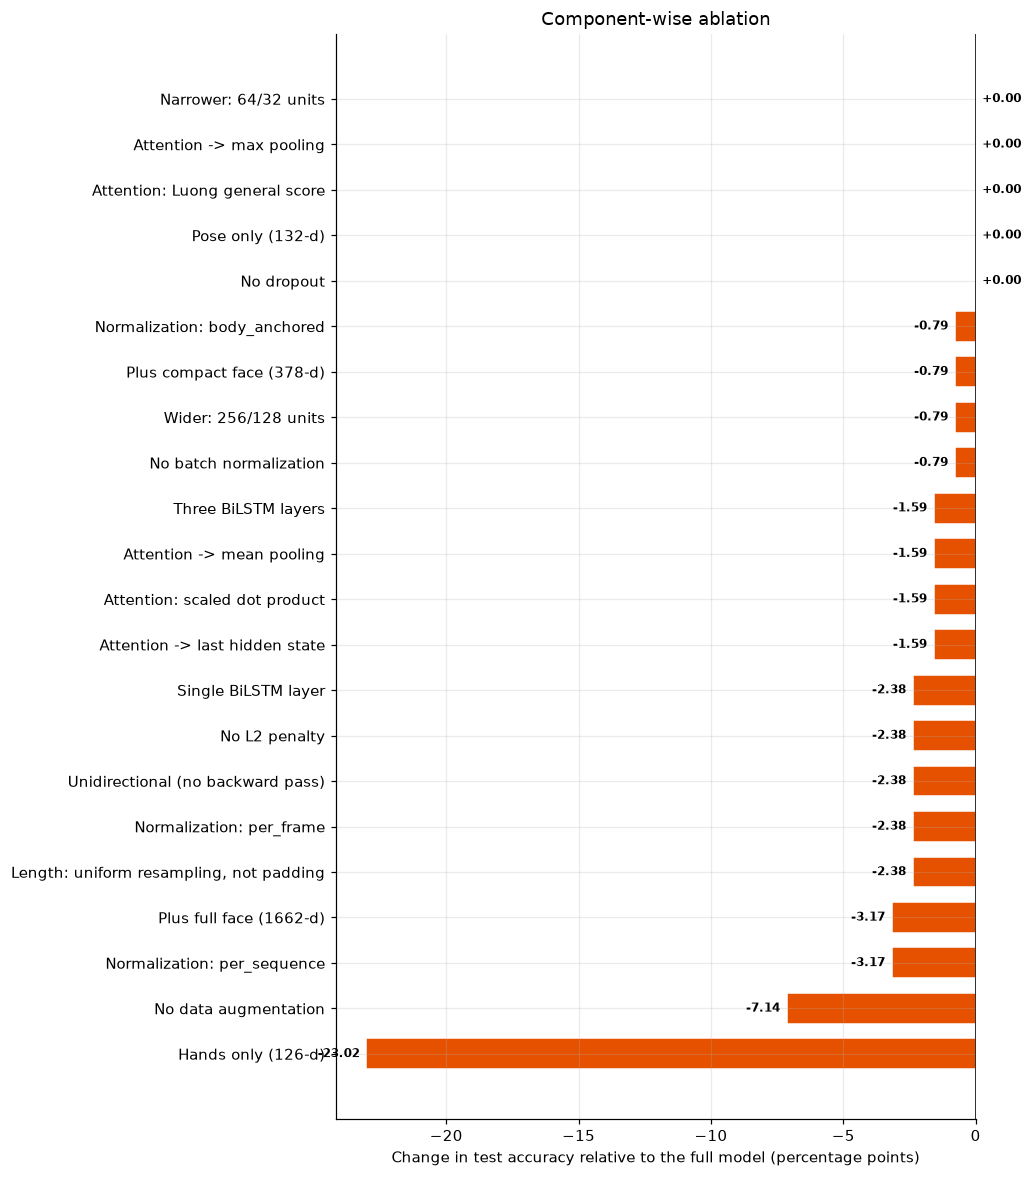


A10 -- adding the full 468-landmark face stream: -3.17 pp

A10 -- adding the compact 40-landmark face stream: -0.79 pp
Report these as measured effects. If a face variant is not worse, the manuscript cannot justify the
exclusion on accuracy grounds and should justify it on cost grounds only, quoting the parameter and
latency differences from Sections 23 and 24.


In [22]:
ABL, ABL_PERCLASS = {}, {}

def ablate(name, build_fn, view='full_258', aug=True, norm_mode=None, X=None,
           purpose=''):
    """Train one ablation variant. Exactly one thing differs from the full model."""
    Xsrc = X_raw if X is None else X
    if view == 'full_258' and aug and norm_mode is None and X is None:
        d = DATA
    else:
        Xv = _slice_view(Xsrc[tr_i], view)
        if aug:
            Xa, ya, _, _, _ = augment(Xv, y_idx[tr_i], g_raw[tr_i])
        else:
            Xa, ya = Xv, y_idx[tr_i]
        nm = Normalizer(norm_mode or NORMALIZATION).fit(Xa)
        dim = int(Xa.shape[-1])
        Xtr = nm.transform_inplace(Xa)      # Xa is ours; normalize without a second copy
        d = {'Xtr': Xtr, 'ytr': ya,
             'Xva': nm.transform(_slice_view(Xsrc[va_i], view)), 'yva': y_idx[va_i],
             'Xte': nm.transform(_slice_view(Xsrc[te_i], view)), 'yte': y_idx[te_i],
             'dim': dim, 'view': view}
    print(f'--- {name}')
    r = run_multi_seed(build_fn, d, f'abl_{name}', seeds=ABL_SEEDS)
    r['purpose'] = purpose
    r['dim'] = d['dim']
    ABL[name] = r
    pcf = []
    for run in r['runs']:
        _, rec_, _, _ = precision_recall_fscore_support(
            yte, run['pred'], labels=np.arange(N_CLASSES), zero_division=0)
        pcf.append(rec_)
    ABL_PERCLASS[name] = np.mean(pcf, axis=0)
    if d is not DATA:
        d.clear()
        del d
        gc.collect()
    return r

ablate('Full model (reference)', build_proposed,
       purpose='All components active: 2-layer BiLSTM 128/64, additive temporal attention, '
               'batch normalization, dropout, L2, 258-d features, 7x augmentation.')

# ---- attention and pooling (A5) ----------------------------------------
ablate('Attention -> mean pooling',
       lambda d, n: build_proposed(d, n, pooling='mean'),
       purpose='All frames weighted equally; stroke frames diluted by preparation and '
               'retraction.')
ablate('Attention -> max pooling',
       lambda d, n: build_proposed(d, n, pooling='max'),
       purpose='Hard selection of one frame per feature rather than a soft distribution.')
ablate('Attention -> last hidden state',
       lambda d, n: build_proposed(d, n, pooling='last'),
       purpose='Sequence compressed to its endpoint; equivalent to a plain BiLSTM.')
ablate('Attention: Luong general score',
       lambda d, n: build_proposed(d, n, score_type='general'),
       purpose='e_t = q^T W h_t instead of the additive score of Eq. (11).')
ablate('Attention: scaled dot product',
       lambda d, n: build_proposed(d, n, score_type='dot_scaled'),
       purpose='e_t = (q . h_t)/sqrt(d); the cheapest scoring function.')

# ---- architecture (A4) --------------------------------------------------
ablate('Unidirectional (no backward pass)',
       lambda d, n: build_proposed(d, n, bidirectional=False),
       purpose='Frames lack the context of the retraction that follows them.')
ablate('Single BiLSTM layer',
       lambda d, n: build_proposed(d, n, n_layers=1),
       purpose='One layer must map raw landmark geometry straight to a classifiable '
               'representation.')
ablate('Three BiLSTM layers',
       lambda d, n: build_proposed(d, n, n_layers=3, units=(128, 64, 64)),
       purpose='Tests whether the corpus supports a third layer. Justifies stopping at two.')
ablate('Narrower: 64/32 units',
       lambda d, n: build_proposed(d, n, units=(64, 32)),
       purpose='Half the published width. Justifies the 128/64 choice from below.')
ablate('Wider: 256/128 units',
       lambda d, n: build_proposed(d, n, units=(256, 128)),
       purpose='Double the published width. Justifies the 128/64 choice from above.')

# ---- regularization (A4) ------------------------------------------------
ablate('No batch normalization',
       lambda d, n: build_proposed(d, n, use_bn=False),
       purpose='Slower, noisier convergence of recurrent activations.')
ablate('No dropout',
       lambda d, n: build_proposed(d, n, dropout=0.0, dense_drops=[0.0, 0.0]),
       purpose='Isolates the contribution of the dropout schedule in Table 6.')
ablate('No L2 penalty',
       lambda d, n: build_proposed(d, n, l2=0.0),
       purpose='Isolates the contribution of the 1e-3 weight decay in Table 6.')

# ---- feature streams (A10, B16) ----------------------------------------
ablate('Hands only (126-d)', build_proposed, view='hands_only',
       purpose='Removes torso and arm trajectory context; keeps handshape and finger '
               'configuration.')
ablate('Pose only (132-d)', build_proposed, view='pose_only',
       purpose='Removes handshape entirely; keeps body posture and gross arm trajectory.')
if INCLUDE_FACE:
    ablate('Plus full face (1662-d)', build_proposed, view='with_face',
           purpose='REVIEWER A COMMENT 10. Adds all 468 MediaPipe face landmarks. Measures '
                   'whether the non-manual channel helps on this vocabulary, instead of '
                   'arguing the exclusion on parameter-budget grounds.')
    ablate('Plus compact face (378-d)', build_proposed, view='with_face_compact',
           purpose='REVIEWER A COMMENT 10. Adds 40 selected lip, brow, eye and outline '
                   'landmarks: the non-manual information at a fraction of the cost, so '
                   'the face question is separated from the dimensionality question.')

# ---- preprocessing (B6) and augmentation -------------------------------
for nm_mode in ('per_sequence', 'per_frame', 'body_anchored'):
    ablate(f'Normalization: {nm_mode}', build_proposed, norm_mode=nm_mode,
           purpose=f'REVIEWER B COMMENT 6. Same model, normalization scope changed to '
                   f'{nm_mode}. Justifies the default empirically.')
try:
    X_resampled = np.stack([standardize_length(SEQS[c], SEQ_LEN, 'resample')
                            for c in inv_kept.clip_id])
    ablate('Length: uniform resampling, not padding', build_proposed, X=X_resampled,
           purpose='Every clip is resampled onto exactly T frames instead of being '
                   'zero-padded or truncated, so the window carries no padding at all. '
                   'The alternative to the published pad/truncate scheme, and the one that '
                   'matters most if the corpus is mostly padding.')
    del X_resampled
    gc.collect()
except Exception as e:
    print(f'Resampling ablation skipped ({type(e).__name__}: {e}); '
          f'it needs the raw variable-length sequences in SEQS.')

ablate('No data augmentation', build_proposed, aug=False,
       purpose=f'Trains on the {len(tr_i)} original training clips only. The single largest '
               f'component in a corpus of this size.')

# --------------------------------------------------------------- the table
ref = ABL['Full model (reference)']['accuracy_mean']
abl_rows = []
for k, v in ABL.items():
    abl_rows.append({
        'Ablated variant': k,
        'Input dim': v['dim'],
        'Test accuracy (%)': round(v['accuracy_mean'] * 100, 2),
        'Std (%)': round(v['accuracy_std'] * 100, 2),
        'Macro F1 (%)': round(v['macro_f1_mean'] * 100, 2),
        'Delta vs full (pp)': round((v['accuracy_mean'] - ref) * 100, 2),
        'Parameters': f"{v['params']:,}",
        'Interpretation': v['purpose'],
    })
abl_tbl = (pd.DataFrame(abl_rows)
           .sort_values('Delta vs full (pp)', ascending=False).reset_index(drop=True))
save_table(abl_tbl, 'table09_ablation_study',
    'MANUSCRIPT TABLE 9, extended. Each variant differs from the full model in exactly one '
    'decision, under the identical protocol, averaged over seeds. The width, depth, '
    'attention-variant, normalization and face rows are new: they are what turn the design '
    'justifications in Section 3.5 (Reviewer A comment 4), the attention specification '
    '(A5), the face exclusion (A10) and the normalization scope (B6) from claims into '
    'measurements.', 'A4, A5, A10, B6, B16')

fig, ax = plt.subplots(figsize=(9.5, 0.4 * len(abl_tbl) + 1.6))
d = abl_tbl[abl_tbl['Ablated variant'] != 'Full model (reference)'].iloc[::-1]
cols = [C_MAIN if x > 0 else C_WARN for x in d['Delta vs full (pp)']]
ax.barh(d['Ablated variant'], d['Delta vs full (pp)'], color=cols, edgecolor='white',
        height=0.68)
ax.axvline(0, color='#212121', lw=1.2)
for i, x in enumerate(d['Delta vs full (pp)']):
    ax.text(x + (0.25 if x >= 0 else -0.25), i, f'{x:+.2f}', va='center',
            ha='left' if x >= 0 else 'right', fontsize=8, fontweight='bold')
ax.set_xlabel('Change in test accuracy relative to the full model (percentage points)')
ax.set_title('Component-wise ablation')
plt.tight_layout()
save_fig(fig, 'fig08_ablation',
         'Manuscript Figure 8. Accuracy change when each single design decision is changed. '
         'Negative bars are components the full model needs; positive bars are decisions '
         'the measurement does not support and that the manuscript should revisit.',
         'A4, A5, A10, B6')

pc = pd.DataFrame(ABL_PERCLASS, index=CLASS_LIST).T * 100
pc.round(2).to_csv(f'{OUT_DIR}/tables/table_ablation_per_class_recall.csv')
register('table', 'table_ablation_per_class_recall',
         ['tables/table_ablation_per_class_recall.csv'],
         'Per-class recall under every ablation variant. Needed to relate feature '
         'importance to individual gestures rather than only to the corpus average, which '
         'is what Reviewer B comments 4 and 16 require.', 'B4, B16')

for key, label in [('Plus full face (1662-d)', 'full 468-landmark face stream'),
                   ('Plus compact face (378-d)', 'compact 40-landmark face stream')]:
    if key in ABL:
        dlt = (ABL[key]['accuracy_mean'] - ref) * 100
        record(f'delta_{"full" if "full" in key else "compact"}_face_pp', round(dlt, 2),
               f'Section 3.2.6 (A10): measured effect of adding the {label}')
        print(f'\nA10 -- adding the {label}: {dlt:+.2f} pp')
print(textwrap.fill(
    'Report these as measured effects. If a face variant is not worse, the manuscript '
    'cannot justify the exclusion on accuracy grounds and should justify it on cost '
    'grounds only, quoting the parameter and latency differences from Sections 23 and 24.',
    100))
for key in ('Hands only (126-d)', 'Pose only (132-d)'):
    if key in ABL:
        record(f'delta_{key.split()[0].lower()}_only_pp',
               round((ABL[key]['accuracy_mean'] - ref) * 100, 2),
               'Section 4.5 (B16): measured feature importance, NOT a linguistic claim')

## 20. Temporal attention behaviour — **Reviewer A comment 5**

The ablation shows a large gap between attention, mean pooling and the last hidden state, so
the mechanism has to be inspectable as well as specified. This section extracts the actual
`α` distribution over the 60 frames for every test clip using the trained weights and the
same equations as the layer, and reports:

* per-class saliency curves with the peak frame marked (manuscript Figure 7),
* the mean attention profile per class with a dispersion band,
* attention concentration per class (peak weight and entropy), which quantifies "the
  network focuses on the stroke" instead of asserting it,
* a projection of the learned context vectors, which shows class separation *after*
  attention has done its work.

    seed 1: acc=97.62%  macroF1=97.62%   [cached]


Sequence fed to attention: (126, 60, 128)  (clips, 60 frames, 128 = 2 x 64 units)
alpha sums to 1.0: True
Total weight on padded frames: 0.00e+00  (must be ~0)


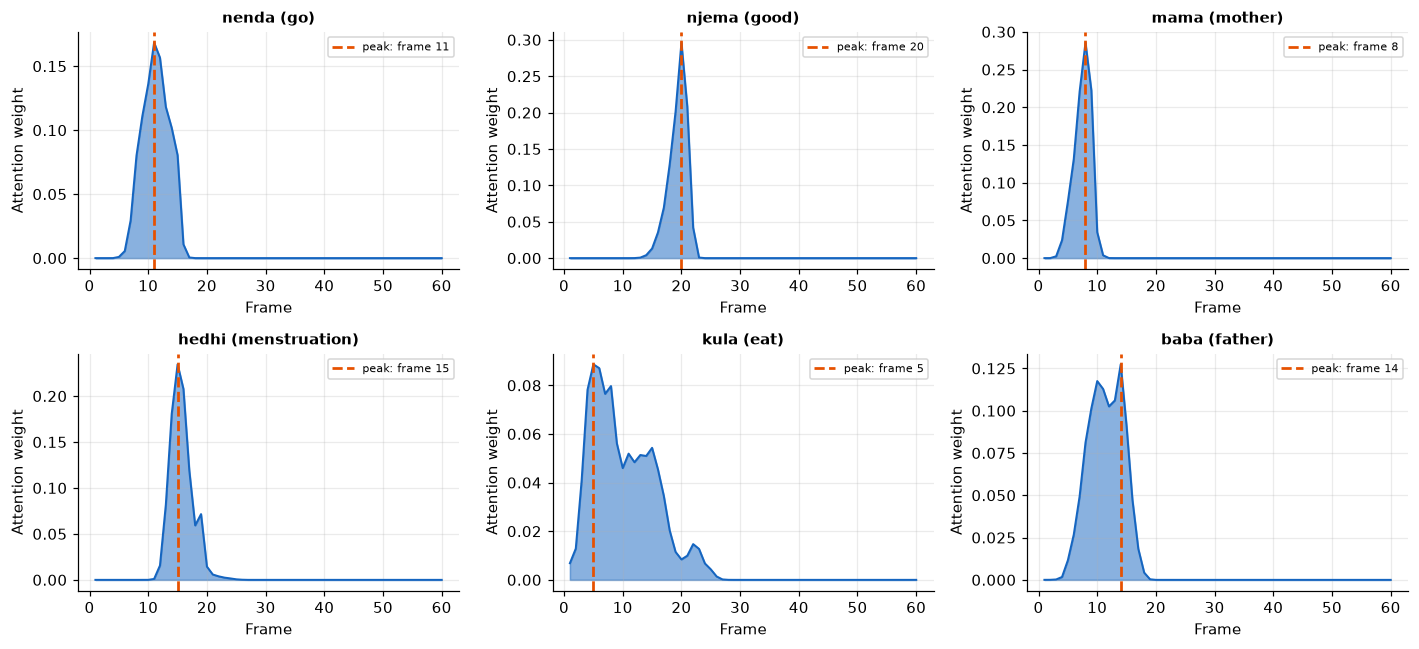

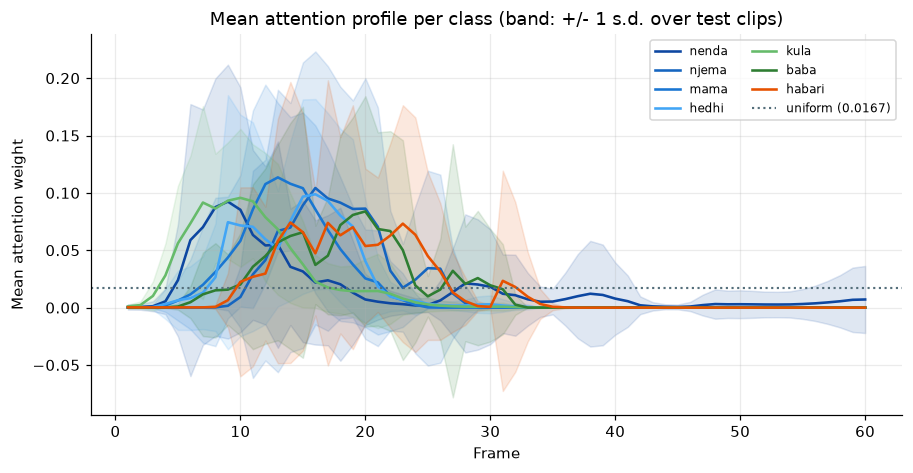


--- table_attention_concentration   [A5]
Attention concentration per class. Uniform attention over 60 frames has entropy 4.0943 nats and a
peak weight of 0.0167, so the ratio column reads as 1.0 for no selectivity and falls towards 0 as
attention sharpens. "Mass in top 10 frames" is the share of the distribution on the ten most salient
frames -- the number to quote in Section 4.6 instead of a qualitative description.


,Class,Clips,Peak frame (mean),Peak frame (std),Peak weight (mean),Mass in top 10 frames,Entropy (nats),Entropy / uniform
0,nenda,18,16.3,13.8,0.2783,0.9477,2.0235,0.4942
1,njema,18,17.9,3.9,0.3218,0.9968,1.6910,0.4130
2,mama,18,14.6,3.2,0.1946,0.9835,2.1042,0.5139
3,hedhi,18,14.0,3.4,0.2280,0.9675,2.0946,0.5116
4,kula,18,10.3,4.5,0.1640,0.8715,2.4734,0.6041
5,baba,18,19.1,5.4,0.2666,0.9682,1.9897,0.4860
6,habari,18,19.4,5.7,0.3000,0.9850,1.8278,0.4464
7,ALL,126,,,0.2505,0.9600,2.0292,0.4956


Python(73196) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


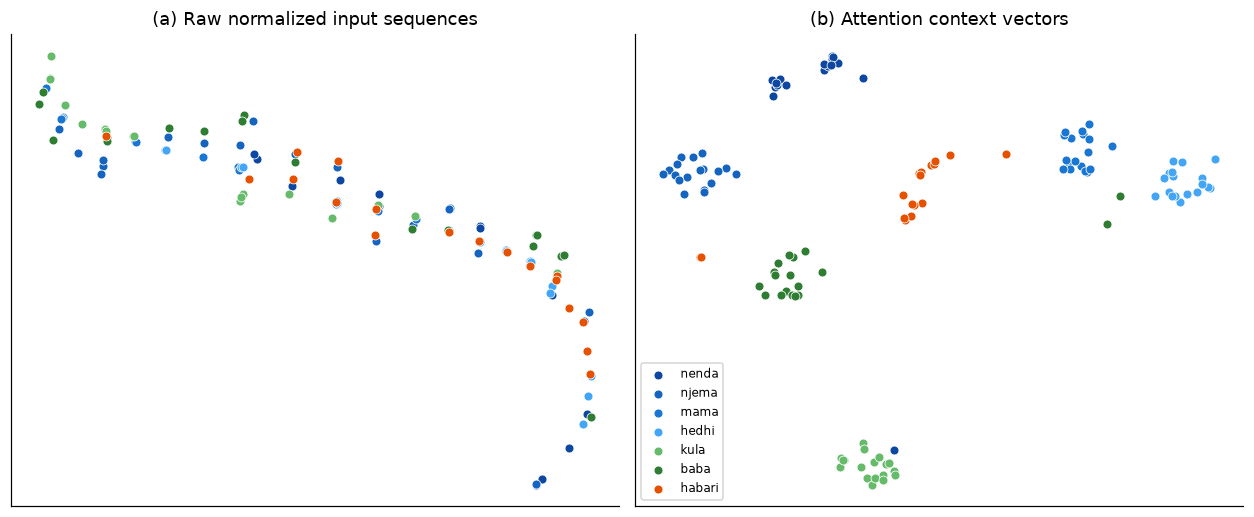

In [23]:
# Load the trained weights of the best seed from the run registry. Section 14 saved them
# with save_model=True, so this does not retrain and the weights are exactly the ones behind
# the confusion matrix and the per-class metrics.
att_run = train_once(build_proposed, DATA, prop['best_seed'], 'proposed',
                     keep_model=True, save_model=True)
pmodel = att_run['model']
att_layer = pmodel.get_layer('temporal_attention')

# The sequence that feeds attention is the output of the last Bidirectional layer.
seq_layer = [l for l in pmodel.layers if isinstance(l, layers.Bidirectional)][-1]
encoder = keras.Model(pmodel.inputs, seq_layer.output, name='encoder')
H = np.asarray(encoder.predict(DATA['Xte'], verbose=0))
print(f'Sequence fed to attention: {H.shape}  '
      f'(clips, {SEQ_LEN} frames, {H.shape[-1]} = 2 x 64 units)')

# Recompute alpha with the layer's own scoring function and the same padding mask.
live_mask = np.any(DATA['Xte'] != 0, axis=2)
alpha = att_layer.weights_for(tf.constant(H), tf.constant(live_mask)).numpy()
context = np.asarray(att_layer(tf.constant(H), tf.constant(live_mask)))
np.save(f'{OUT_DIR}/attention_weights_test.npy', alpha)
np.save(f'{OUT_DIR}/attention_context_vectors_test.npy', context)
register('record', 'attention_weights',
         ['attention_weights_test.npy', 'attention_context_vectors_test.npy'],
         'The learned attention distribution over the 60 frames for every test clip, and '
         'the resulting context vectors. Lets any reader reproduce Figure 7 and verify that '
         'alpha sums to one and gives padded frames zero weight.', 'A5')
print(f'alpha sums to 1.0: {np.allclose(alpha.sum(1), 1.0)}')
pad_mass = float(alpha[~live_mask].sum()) if (~live_mask).any() else 0.0
print(f'Total weight on padded frames: {pad_mass:.2e}  (must be ~0)')

# ---------------------------------------- Figure 7: per-class saliency curves
n_show = min(6, N_CLASSES)
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, ci in zip(axes.ravel(), range(n_show)):
    idxs = np.where(yte == ci)[0]
    if not len(idxs):
        ax.axis('off'); continue
    a = alpha[idxs[0]]
    ax.fill_between(range(1, SEQ_LEN + 1), a, alpha=0.5, color=C_ALT)
    ax.plot(range(1, SEQ_LEN + 1), a, color=C_ALT, lw=1.3)
    ax.axvline(a.argmax() + 1, color=C_WARN, ls='--', lw=1.8,
               label=f'peak: frame {a.argmax()+1}')
    live_n = int(live_mask[idxs[0]].sum())
    if live_n < SEQ_LEN:
        ax.axvspan(live_n + 0.5, SEQ_LEN + 0.5, color=C_GREY, alpha=0.12)
        ax.text(live_n + (SEQ_LEN - live_n) / 2, a.max() * 0.85, 'padding',
                ha='center', fontsize=7, color=C_GREY)
    ax.set_title(f'{CLASS_LIST[ci]} ({GLOSS_EN.get(CLASS_LIST[ci], "")})',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Frame'); ax.set_ylabel('Attention weight')
    ax.legend(fontsize=7)
for ax in axes.ravel()[n_show:]:
    ax.axis('off')
plt.tight_layout()
save_fig(fig, 'fig07_attention_weights',
         'Manuscript Figure 7. Learned attention distribution over the 60 frames for one '
         'test clip of each class; the dashed line marks the highest-weight frame and the '
         'shaded region marks zero-padded frames, which receive no weight.', 'A5')

# ------------------------------------------- mean profile with dispersion band
fig, ax = plt.subplots(figsize=(8.4, 4.4))
for ci, c in enumerate(CLASS_LIST):
    idxs = np.where(yte == ci)[0]
    if not len(idxs):
        continue
    mu, sd = alpha[idxs].mean(0), alpha[idxs].std(0)
    x = np.arange(1, SEQ_LEN + 1)
    ax.plot(x, mu, color=C_SEQ[ci % len(C_SEQ)], lw=1.7, label=c)
    ax.fill_between(x, mu - sd, mu + sd, color=C_SEQ[ci % len(C_SEQ)], alpha=0.13)
ax.axhline(1.0 / SEQ_LEN, color=C_GREY, ls=':', lw=1.4,
           label=f'uniform ({1/SEQ_LEN:.4f})')
ax.set_xlabel('Frame'); ax.set_ylabel('Mean attention weight')
ax.set_title('Mean attention profile per class (band: +/- 1 s.d. over test clips)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
save_fig(fig, 'fig_attention_mean_profiles',
         'Class-averaged attention profiles against the uniform baseline. The evidence for '
         'the claim in Section 4.6 that attention mass concentrates on an interval rather '
         'than spreading evenly.', 'A5')

# ------------------------------------------------- concentration statistics
uniform_entropy = math.log(SEQ_LEN)
rows = []
for ci, c in enumerate(CLASS_LIST):
    idxs = np.where(yte == ci)[0]
    if not len(idxs):
        continue
    a = alpha[idxs]
    ent = -(a * np.log(a + 1e-12)).sum(1)
    mass10 = np.sort(a, axis=1)[:, -10:].sum(1)
    rows.append({'Class': c, 'Clips': len(idxs),
                 'Peak frame (mean)': round(float((a.argmax(1) + 1).mean()), 1),
                 'Peak frame (std)': round(float((a.argmax(1) + 1).std()), 1),
                 'Peak weight (mean)': round(float(a.max(1).mean()), 4),
                 'Mass in top 10 frames': round(float(mass10.mean()), 4),
                 'Entropy (nats)': round(float(ent.mean()), 4),
                 'Entropy / uniform': round(float(ent.mean() / uniform_entropy), 4)})
att_stats = pd.DataFrame(rows)
att_stats.loc[len(att_stats)] = ['ALL', len(yte), '', '',
                                 round(float(alpha.max(1).mean()), 4),
                                 round(float(np.sort(alpha, 1)[:, -10:].sum(1).mean()), 4),
                                 round(float((-(alpha * np.log(alpha + 1e-12))
                                              .sum(1)).mean()), 4),
                                 round(float((-(alpha * np.log(alpha + 1e-12)).sum(1)).mean()
                                             / uniform_entropy), 4)]
save_table(att_stats, 'table_attention_concentration',
           f'Attention concentration per class. Uniform attention over {SEQ_LEN} frames has '
           f'entropy {uniform_entropy:.4f} nats and a peak weight of {1/SEQ_LEN:.4f}, so the '
           f'ratio column reads as 1.0 for no selectivity and falls towards 0 as attention '
           f'sharpens. "Mass in top 10 frames" is the share of the distribution on the ten '
           f'most salient frames -- the number to quote in Section 4.6 instead of a '
           f'qualitative description.', 'A5')
record('attention_entropy_ratio', float(att_stats['Entropy / uniform'].iloc[-1]),
       'Section 4.6: how much more selective than uniform the learned attention is')
record('attention_top10_mass', float(att_stats['Mass in top 10 frames'].iloc[-1]),
       'Section 4.6: share of attention mass on the ten most salient frames')

# ------------------------------------------- context-vector projection (t-SNE)
try:
    from sklearn.manifold import TSNE
    from sklearn.decomposition import PCA
    per = max(5, min(30, len(context) // 4))
    emb = TSNE(n_components=2, perplexity=per, init='pca',
               random_state=GLOBAL_SEED).fit_transform(context)
    flat_in = DATA['Xte'].reshape(len(DATA['Xte']), -1)
    emb_in = TSNE(n_components=2, perplexity=per, init='pca',
                  random_state=GLOBAL_SEED).fit_transform(
                      PCA(n_components=min(50, flat_in.shape[1]),
                          random_state=GLOBAL_SEED).fit_transform(flat_in))
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
    for ax, e, ttl in [(axes[0], emb_in, '(a) Raw normalized input sequences'),
                       (axes[1], emb, '(b) Attention context vectors')]:
        for ci, c in enumerate(CLASS_LIST):
            m = yte == ci
            ax.scatter(e[m, 0], e[m, 1], s=34, color=C_SEQ[ci % len(C_SEQ)], label=c,
                       edgecolor='white', linewidth=0.5)
        ax.set_title(ttl); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    axes[1].legend(fontsize=8, loc='best')
    plt.tight_layout()
    save_fig(fig, 'fig_context_vector_projection',
             't-SNE of the test clips before and after the network. Panel (b) is the '
             '128-dimensional context vector produced by temporal attention: the class '
             'structure the classification head actually sees.', 'A5')
except Exception as e:
    print(f'Projection skipped: {e}')

## 21. Gesture characterization — **Reviewer B comments 4 and 16**

Reviewer B asks for the linguistic and visual characteristics of the selected gestures —
handshape, orientation, movement, location, and the role of pose and non-manual cues — and
asks that they be correlated with the ablation results.

Asserting phonological descriptions would not be evidence. Instead every characteristic is
**measured from the landmark corpus**:

| Sign parameter | Measured proxy |
|---|---|
| Handedness | fraction of frames in which each hand is detected, and both together |
| Location | wrist height relative to the shoulder line and to the nose; horizontal offset from the body midline |
| Movement | mean frame-to-frame wrist displacement, total path length, and the number of direction reversals (a repetition proxy) |
| Handshape | mean finger spread and finger curl, from the hand landmark geometry |
| Orientation | angle of the wrist-to-middle-knuckle axis |
| Non-manual activity | variance of the compact face landmark set over the clip |

Those are observable facts you can state in Section 3.2.6. The final table correlates them
with the per-class recall loss under the hands-only and pose-only ablations — which is the
correlation the reviewer asks for, and which keeps the conclusion empirical rather than
linguistic (**B16**).


--- table_gesture_characteristics   [B4]
REVIEWER B COMMENT 4. Visual and articulatory characteristics of every gesture, MEASURED from the
landmark corpus rather than described informally. Heights and offsets are in shoulder-width units,
so they are comparable across signers and camera distances; positive height means the hand sits
above the reference landmark. "Finger curl" is the mean fingertip-to-wrist distance divided by the
mean knuckle-to-wrist distance, so it is near 1 for a closed fist and above 2 for extended fingers.
"Direction reversals" counts vertical velocity sign changes and is a proxy for repeated movement.
These are the facts Section 3.2.6 can state; the full phonological annotation with Deaf consultants
remains future work.


,Class (gloss),Clips,Handedness,Dominant hand,Left hand present (%),Right hand present (%),Both hands present (%),Height vs shoulders,Height vs nose,Lateral offset,Frame-to-frame motion,Path length,Direction reversals,Finger spread,Finger curl,Wrist orientation (deg),Non-manual activity
0,nenda (go),120,one-handed,left,17.9,11.4,4.5,-0.858,-1.697,0.354,0.1854,0.925,1.6,0.2643,1.929,109.5,0.0194
1,njema (good),119,one-handed,left,49.0,43.9,28.2,-1.219,-2.268,0.326,0.2138,2.549,4.8,0.2586,1.718,93.2,0.0155
2,mama (mother),120,one-handed,right,0.8,4.0,0.0,-1.142,-2.015,0.283,0.3879,0.584,0.3,0.2093,1.542,58.1,0.0211
3,hedhi (menstruation),120,one-handed,right,0.6,10.9,0.0,-0.886,-1.732,0.369,0.4024,1.352,1.4,0.2288,1.624,54.6,0.0308
4,kula (eat),119,one-handed,left,1.6,0.5,0.0,-1.509,-2.087,0.223,0.0371,0.116,2.0,0.1395,1.584,85.1,0.0444
5,baba (father),120,one-handed,left,49.8,40.3,23.1,-1.790,-2.830,0.274,0.1651,1.390,7.1,0.1777,1.717,99.1,0.0175
6,habari (hi),119,one-handed,right,8.4,24.0,5.4,-0.771,-1.674,0.270,0.2237,1.618,2.4,0.2258,1.898,70.0,0.0159



--- table_characteristics_vs_ablation   [B4, B16]
REVIEWER B COMMENTS 4 AND 16. Per-class measured characteristics beside per-class recall under each
feature-stream ablation. This is the correlation the reviewer asks for, and it is the right place to
be careful: these columns show which gestures in THIS corpus depend on which stream. They do not
establish that hand configuration is linguistically dominant in Swahili Sign Language -- seven
manual glosses from two signers cannot support that conclusion, and the face stream was excluded
from the primary representation altogether.


,Class (gloss),Handedness,Height vs shoulders,Frame-to-frame motion,Finger spread,"Recall, full model (%)","Recall, hands only (%)","Recall, pose only (%)",Loss without pose (pp),Loss without hands (pp)
0,nenda (go),one-handed,-0.858,0.1854,0.2643,94.44,88.89,94.44,-5.55,0.00
1,njema (good),one-handed,-1.219,0.2138,0.2586,100.00,88.89,100.00,-11.11,0.00
2,mama (mother),one-handed,-1.142,0.3879,0.2093,100.00,44.44,100.00,-55.56,0.00
3,hedhi (menstruation),one-handed,-0.886,0.4024,0.2288,100.00,66.67,100.00,-33.33,0.00
4,kula (eat),one-handed,-1.509,0.0371,0.1395,100.00,77.78,100.00,-22.22,0.00
5,baba (father),one-handed,-1.790,0.1651,0.1777,94.44,77.78,88.89,-16.66,-5.55
6,habari (hi),one-handed,-0.771,0.2237,0.2258,94.44,77.78,100.00,-16.66,5.56


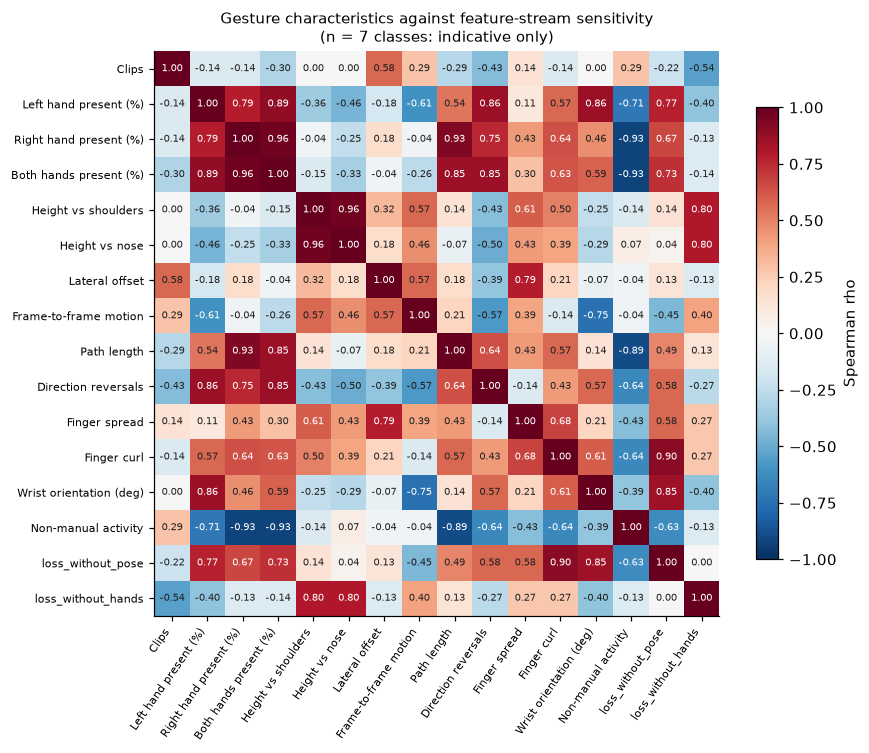

In [24]:
NOSE, L_WR, R_WR = 0, 15, 16
TIPS, MCPS = [4, 8, 12, 16, 20], [2, 5, 9, 13, 17]

def hand_geometry(hand_xyz):
    """(21, 3) hand landmarks -> spread, curl, orientation angle."""
    wrist = hand_xyz[0]
    tips = hand_xyz[TIPS]
    spread = float(np.mean([np.linalg.norm(tips[i] - tips[j])
                            for i in range(len(tips)) for j in range(i + 1, len(tips))]))
    tip_d = np.linalg.norm(tips - wrist, axis=1).mean()
    mcp_d = np.linalg.norm(hand_xyz[MCPS] - wrist, axis=1).mean()
    curl = float(tip_d / (mcp_d + 1e-8))          # ~1 closed fist, >2 extended fingers
    axis = hand_xyz[9] - wrist
    angle = float(math.degrees(math.atan2(axis[1], axis[0] + 1e-8)))
    return spread, curl, angle

char_rows = []
for ci, cls in enumerate(CLASS_LIST):
    idxs = np.where(y_idx == ci)[0]
    acc = defaultdict(list)
    for i in idxs:
        seq = X_raw[i]
        live = np.any(seq != 0, axis=1)
        if not live.any():
            continue
        s = seq[live]
        pose = s[:, :POSE_DIM].reshape(len(s), 33, 4)
        lh = s[:, POSE_DIM:POSE_DIM + HAND_DIM].reshape(len(s), 21, 3)
        rh = s[:, POSE_DIM + HAND_DIM:FEAT_DIM].reshape(len(s), 21, 3)
        lh_on = np.any(lh.reshape(len(s), -1) != 0, axis=1)
        rh_on = np.any(rh.reshape(len(s), -1) != 0, axis=1)
        acc['lh'].append(lh_on.mean()); acc['rh'].append(rh_on.mean())
        acc['both'].append((lh_on & rh_on).mean())

        sh_y   = (pose[:, L_SH, 1] + pose[:, R_SH, 1]) / 2
        sh_x   = (pose[:, L_SH, 0] + pose[:, R_SH, 0]) / 2
        nose_y = pose[:, NOSE, 1]
        sh_w   = np.linalg.norm(pose[:, L_SH, :2] - pose[:, R_SH, :2], axis=1).mean() or 1.0

        wr, dom_on = [], None
        if rh_on.mean() >= lh_on.mean() and rh_on.any():
            wr, dom_on, dom = rh[rh_on], rh_on, 'right'
        elif lh_on.any():
            wr, dom_on, dom = lh[lh_on], lh_on, 'left'
        if len(wr):
            wrist = wr[:, 0, :]
            acc['height_sh'].append(float((sh_y[dom_on] - wrist[:, 1]).mean() / sh_w))
            acc['height_nose'].append(float((nose_y[dom_on] - wrist[:, 1]).mean() / sh_w))
            acc['lateral'].append(float(np.abs(wrist[:, 0] - sh_x[dom_on]).mean() / sh_w))
            if len(wrist) > 1:
                step = np.linalg.norm(np.diff(wrist[:, :2], axis=0), axis=1)
                acc['motion'].append(float(step.mean() / sh_w))
                acc['path'].append(float(step.sum() / sh_w))
                vy = np.diff(wrist[:, 1])
                acc['reversals'].append(float((np.diff(np.sign(vy)) != 0).sum()))
            g = np.array([hand_geometry(f) for f in wr])
            acc['spread'].append(float(g[:, 0].mean() / sh_w))
            acc['curl'].append(float(g[:, 1].mean()))
            acc['orient'].append(float(np.abs(g[:, 2]).mean()))
            acc['dom_right'].append(1.0 if dom == 'right' else 0.0)
        if INCLUDE_FACE:
            fc = s[:, _FACE_COLS]
            if np.any(fc):
                acc['face_var'].append(float(fc.std(axis=0).mean() / sh_w))

    def mv(k, dp=3):
        return round(float(np.mean(acc[k])), dp) if acc[k] else np.nan

    two_handed = np.mean(acc['both']) > 0.5 if acc['both'] else False
    char_rows.append({
        'Class (gloss)': f'{cls} ({GLOSS_EN.get(cls, "")})',
        'Clips': len(idxs),
        'Handedness': 'two-handed' if two_handed else 'one-handed',
        'Dominant hand': ('right' if (acc['dom_right'] and np.mean(acc['dom_right']) > 0.5)
                          else 'left'),
        'Left hand present (%)': round(float(np.mean(acc['lh']) * 100), 1),
        'Right hand present (%)': round(float(np.mean(acc['rh']) * 100), 1),
        'Both hands present (%)': round(float(np.mean(acc['both']) * 100), 1),
        'Height vs shoulders': mv('height_sh'),
        'Height vs nose': mv('height_nose'),
        'Lateral offset': mv('lateral'),
        'Frame-to-frame motion': mv('motion', 4),
        'Path length': mv('path'),
        'Direction reversals': mv('reversals', 1),
        'Finger spread': mv('spread', 4),
        'Finger curl': mv('curl'),
        'Wrist orientation (deg)': mv('orient', 1),
        'Non-manual activity': mv('face_var', 4),
    })
char_tbl = pd.DataFrame(char_rows)
save_table(char_tbl, 'table_gesture_characteristics',
    'REVIEWER B COMMENT 4. Visual and articulatory characteristics of every gesture, '
    'MEASURED from the landmark corpus rather than described informally. Heights and '
    'offsets are in shoulder-width units, so they are comparable across signers and camera '
    'distances; positive height means the hand sits above the reference landmark. '
    '"Finger curl" is the mean fingertip-to-wrist distance divided by the mean '
    'knuckle-to-wrist distance, so it is near 1 for a closed fist and above 2 for extended '
    'fingers. "Direction reversals" counts vertical velocity sign changes and is a proxy '
    'for repeated movement. These are the facts Section 3.2.6 can state; the full '
    'phonological annotation with Deaf consultants remains future work.', 'B4')

# ------------------------------- correlate characteristics with the ablation
if 'Hands only (126-d)' in ABL_PERCLASS and 'Pose only (132-d)' in ABL_PERCLASS:
    full_rec = ABL_PERCLASS['Full model (reference)']
    corr_tbl = pd.DataFrame({
        'Class (gloss)': char_tbl['Class (gloss)'],
        'Handedness': char_tbl['Handedness'],
        'Height vs shoulders': char_tbl['Height vs shoulders'],
        'Frame-to-frame motion': char_tbl['Frame-to-frame motion'],
        'Finger spread': char_tbl['Finger spread'],
        'Recall, full model (%)': (full_rec * 100).round(2),
        'Recall, hands only (%)': (ABL_PERCLASS['Hands only (126-d)'] * 100).round(2),
        'Recall, pose only (%)': (ABL_PERCLASS['Pose only (132-d)'] * 100).round(2),
    })
    corr_tbl['Loss without pose (pp)'] = (corr_tbl['Recall, hands only (%)']
                                          - corr_tbl['Recall, full model (%)']).round(2)
    corr_tbl['Loss without hands (pp)'] = (corr_tbl['Recall, pose only (%)']
                                           - corr_tbl['Recall, full model (%)']).round(2)
    save_table(corr_tbl, 'table_characteristics_vs_ablation',
        'REVIEWER B COMMENTS 4 AND 16. Per-class measured characteristics beside per-class '
        'recall under each feature-stream ablation. This is the correlation the reviewer '
        'asks for, and it is the right place to be careful: these columns show which '
        'gestures in THIS corpus depend on which stream. They do not establish that hand '
        'configuration is linguistically dominant in Swahili Sign Language -- seven manual '
        'glosses from two signers cannot support that conclusion, and the face stream was '
        'excluded from the primary representation altogether.', 'B4, B16')

    num = char_tbl.select_dtypes(include=[np.number]).copy()
    num['loss_without_pose'] = corr_tbl['Loss without pose (pp)'].values
    num['loss_without_hands'] = corr_tbl['Loss without hands (pp)'].values
    cm_corr = num.corr(method='spearman')
    fig, ax = plt.subplots(figsize=(8.2, 6.8))
    im = ax.imshow(cm_corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(cm_corr))); ax.set_yticks(range(len(cm_corr)))
    ax.set_xticklabels(cm_corr.columns, rotation=55, ha='right', fontsize=7.5)
    ax.set_yticklabels(cm_corr.index, fontsize=7.5)
    for i in range(len(cm_corr)):
        for j in range(len(cm_corr)):
            v = cm_corr.values[i, j]
            if v == v:
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6.5,
                        color='white' if abs(v) > 0.6 else '#212121')
    ax.grid(False)
    plt.colorbar(im, shrink=0.8, label='Spearman rho')
    ax.set_title(f'Gesture characteristics against feature-stream sensitivity\n'
                 f'(n = {N_CLASSES} classes: indicative only)', fontsize=10)
    plt.tight_layout()
    save_fig(fig, 'fig_characteristics_correlation',
             'Spearman correlations among the measured gesture characteristics and the '
             'per-class loss from removing each feature stream. With only seven classes '
             'these coefficients are indicative, not inferential, and the manuscript should '
             'say so.', 'B4, B16')
    cm_corr.round(4).to_csv(f'{OUT_DIR}/tables/table_characteristics_correlation.csv')

## 22. Signer-independent evaluation — **Reviewer B comment 15**

The manuscript currently states that leave-one-signer-out "was not run because, with two
contributors, the held-out population would consist of a single individual and the resulting
estimate would carry no useful precision."

That is a fair caveat but a weak answer, and the reviewer explicitly asks for the experiment
"if feasible". It is feasible: with two signers it gives two folds, each training on one
signer and testing on the other, repeated over seeds. The estimate is imprecise, and the
notebook says so — but an imprecise measured number is worth far more to the revision than a
declaration that the measurement is impossible.

What this produces:

* accuracy and macro F1 per held-out signer, mean ± s.d. over seeds,
* the **gap** between signer-dependent and signer-independent performance, which is the
  honest bound on how much the headline figure depends on having seen the signer,
* a per-class breakdown and a cross-signer confusion matrix, showing *which* gestures fail
  to transfer.


--- Held-out signer: Britney   (train on ['Grace']: 357 clips, test: 418 clips)


    seed 1: acc=56.70%  macroF1=47.73%  (40 epochs, best @40, 1129s, 604,551 params)



--- Held-out signer: Grace   (train on ['Britney']: 356 clips, test: 419 clips)


    seed 1: acc=54.89%  macroF1=51.62%  (40 epochs, best @39, 972s, 604,551 params)



--- table_signer_independent   [B15]
REVIEWER B COMMENT 15. Leave-one-signer-out results: each fold trains on one signer and tests on the
other. With 2 signers this is a 2-fold estimate and its precision is correspondingly poor, which the
manuscript must state. It is nonetheless a measured signer-independent number, which the current
text says does not exist.


,Held-out signer,Trained on,Train clips (original),Train sequences (augmented),Test clips,Accuracy (%),Macro F1 (%),Balanced accuracy (%)
0,Britney,Grace,357,2499,418,56.70 +/- 0.00,47.73 +/- 0.00,56.65 +/- 0.00
1,Grace,Britney,356,2492,419,54.89 +/- 0.00,51.62 +/- 0.00,55.00 +/- 0.00
2,Mean over folds,,,,,55.80,49.67,



Signer-DEPENDENT   (both signers in every partition): 97.62%
Signer-INDEPENDENT (leave-one-signer-out)            : 55.80%
Gap                                                  : +41.82 pp

--- table_protocol_comparison   [B15]
The two protocols side by side. This table is what Section 4.1 should carry: it states precisely
what the headline number does and does not establish, and gives the signer-independent counterpart
rather than only a caveat.


,Protocol,What it measures,Folds / seeds,Accuracy (%),Macro F1 (%)
0,Signer-dependent (sample-level stratified split),generalization to unseen repetitions by known ...,1 split x 1 seeds,97.62 +/- 0.00,97.62
1,Signer-independent (leave-one-signer-out),generalization to an unseen signer,2 folds x 1 seeds,55.80,49.67



--- table_signer_independent_per_class   [B15]
Which gestures survive the change of signer and which do not. The transfer-loss column identifies
the classes whose articulation differs most between the two signers, which is concrete guidance for
what an enlarged corpus should prioritize.


,Class,"Recall, Britney held out (%)","Recall, Grace held out (%)","Recall, signer-dependent (%)",Mean signer-independent (%),Transfer loss (pp)
0,nenda,0.00,0.00,94.44,0.00,-94.44
1,njema,91.53,38.33,100.00,64.93,-35.07
2,mama,63.33,78.33,100.00,70.83,-29.17
3,hedhi,41.67,3.33,100.00,22.50,-77.50
4,kula,100.00,100.00,100.00,100.00,0.00
5,baba,100.00,73.33,94.44,86.66,-7.78
6,habari,0.00,91.67,94.44,45.84,-48.60


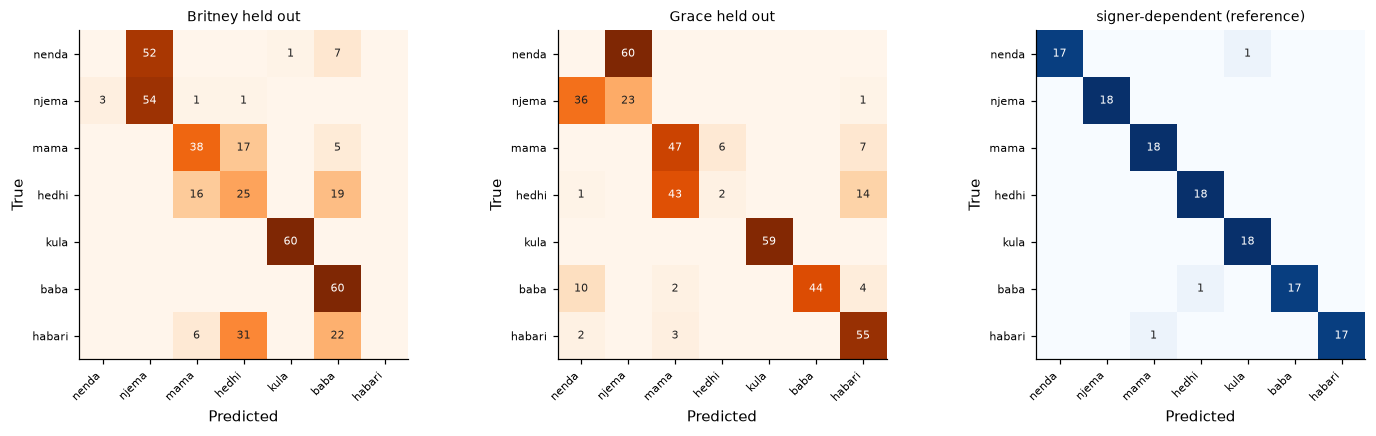

In [25]:
LOSO = {}
loso_rows, loso_percls, loso_cms = [], {}, {}

if len(SIGNERS) < 2:
    print('Only one signer in the corpus; leave-one-signer-out is not applicable.')
else:
    for held in SIGNERS:
        te_mask = (g_raw == held)
        pool = np.where(~te_mask)[0]
        held_idx = np.where(te_mask)[0]
        if len(pool) < 20 or len(np.unique(y_idx[held_idx])) < N_CLASSES:
            print(f'Skipping {held}: the remaining data does not cover every class.')
            continue

        # Dynamically determine the validation split size for stratified_split
        # The original VAL_FRAC (0.15) applied to `pool` (28 samples) yields 4.2, rounded to 5 samples.
        # This is less than N_CLASSES (7), causing the ValueError.
        # Ensure the number of samples for the validation set (va2) is at least N_CLASSES
        # for stratified splitting, but also leave enough for the training set (tr2).
        # Minimum samples needed for tr2 and va2 combined for stratified split is 2 * N_CLASSES.
        if len(pool) < 2 * N_CLASSES:
            print(f"Warning: Not enough samples in pool ({len(pool)}) to create stratified train/validation sets for {N_CLASSES} classes. Skipping {held}.")
            continue

        # Calculate the number of samples for the validation set (va2)
        # It must be at least N_CLASSES to allow for stratification.
        # We'll use the original VAL_FRAC to calculate a target, but ensure it meets the minimum.
        target_val_samples = int(len(pool) * VAL_FRAC)
        # Ensure va2 has at least N_CLASSES samples for stratification, and tr2 also has at least N_CLASSES
        actual_val_samples = min(max(N_CLASSES, target_val_samples), len(pool) - N_CLASSES) # Ensure tr2 has at least N_CLASSES samples

        if actual_val_samples < N_CLASSES:
            print(f"Warning: Cannot create a valid stratified validation set for {held}. Skipping.")
            continue

        tr2, va2 = train_test_split(pool, test_size=actual_val_samples, stratify=y_idx[pool],
                                    random_state=SPLIT_SEED)
        Xa, ya, _, _, _ = augment(X_raw[tr2][:, :, PRIMARY], y_idx[tr2], g_raw[tr2])
        nm = Normalizer().fit(Xa)
        d = {'Xtr': nm.transform_inplace(Xa), 'ytr': ya,
             'Xva': nm.transform(X_raw[va2][:, :, PRIMARY]), 'yva': y_idx[va2],
             'Xte': nm.transform(X_raw[held_idx][:, :, PRIMARY]), 'yte': y_idx[held_idx],
             'dim': FEAT_DIM}
        train_from = [s for s in SIGNERS if s != held]
        print(f'\n--- Held-out signer: {held}   ' # Missing backslash before newline
              f'(train on {train_from}: {len(tr2)} clips, test: {len(held_idx)} clips)')
        agg = run_multi_seed(build_proposed, d, f'loso_{held}', seeds=LOSO_SEEDS,
                             class_weight=None)
        LOSO[held] = agg
        loso_rows.append({
            'Held-out signer': held,
            'Trained on': ', '.join(train_from),
            'Train clips (original)': len(tr2),
            'Train sequences (augmented)': len(ya),
            'Test clips': len(held_idx),
            'Accuracy (%)': fmt_pm(agg['accuracy_mean'], agg['accuracy_std']),
            'Macro F1 (%)': fmt_pm(agg['macro_f1_mean'], agg['macro_f1_std']),
            'Balanced accuracy (%)': fmt_pm(agg['balanced_accuracy_mean'],
                                            agg['balanced_accuracy_std']),
            '_acc': agg['accuracy_mean'], '_f1': agg['macro_f1_mean'],
        })
        _, rc, _, _ = precision_recall_fscore_support(
            d['yte'], agg['best']['pred'], labels=np.arange(N_CLASSES), zero_division=0)
        loso_percls[held] = rc
        loso_cms[held] = confusion_matrix(d['yte'], agg['best']['pred'],
                                          labels=np.arange(N_CLASSES))
        del d, Xa
        gc.collect()

if loso_rows:
    loso = pd.DataFrame(loso_rows)
    mean_acc = float(np.mean([r['_acc'] for r in loso_rows]))
    mean_f1  = float(np.mean([r['_f1'] for r in loso_rows]))
    loso = loso.drop(columns=['_acc', '_f1'])
    loso.loc[len(loso)] = ['Mean over folds', '', '', '', '',
                           f'{mean_acc*100:.2f}', f'{mean_f1*100:.2f}', '']
    save_table(loso, 'table_signer_independent',
        'REVIEWER B COMMENT 15. Leave-one-signer-out results: each fold trains on one '
        f'signer and tests on the other. With {len(SIGNERS)} signers this is a '
        f'{len(SIGNERS)}-fold estimate and its precision is correspondingly poor, which the '
        'manuscript must state. It is nonetheless a measured signer-independent number, '
        'which the current text says does not exist.', 'B15')

    dep = RESULTS[PROPOSED]['accuracy_mean'] * 100
    ind = mean_acc * 100
    gap = dep - ind
    print(f'\nSigner-DEPENDENT   (both signers in every partition): {dep:.2f}%') # Missing backslash before newline
    print(f'Signer-INDEPENDENT (leave-one-signer-out)            : {ind:.2f}%')
    print(f'Gap                                                  : {gap:+.2f} pp')
    record('signer_dependent_accuracy', round(dep, 2),
           'Abstract and Section 4.2: the headline figure, scoped to unseen repetitions by '
           'known signers')
    record('signer_independent_accuracy', round(ind, 2),
           'Section 4.1 and 4.7.1 (B15): leave-one-signer-out accuracy, to be reported '
           'alongside the headline figure')
    record('signer_generalization_gap_pp', round(gap, 2),
           'Section 4.7.1 (B15): how much of the headline figure depends on having seen '
           'the signer during training')

    comp = pd.DataFrame({
        'Protocol': ['Signer-dependent (sample-level stratified split)',
                     'Signer-independent (leave-one-signer-out)'],
        'What it measures': ['generalization to unseen repetitions by known signers',
                             'generalization to an unseen signer'],
        'Folds / seeds': [f'1 split x {len(SEEDS)} seeds',
                          f'{len(loso_rows)} folds x {len(LOSO_SEEDS)} seeds'],
        'Accuracy (%)': [f'{dep:.2f} +/- {RESULTS[PROPOSED]["accuracy_std"]*100:.2f}',
                         f'{ind:.2f}'],
        'Macro F1 (%)': [f'{RESULTS[PROPOSED]["macro_f1_mean"]*100:.2f}',
                         f'{mean_f1*100:.2f}'],
    })
    save_table(comp, 'table_protocol_comparison',
        'The two protocols side by side. This table is what Section 4.1 should carry: it '
        'states precisely what the headline number does and does not establish, and gives '
        'the signer-independent counterpart rather than only a caveat.', 'B15')

    if loso_percls:
        pc = pd.DataFrame({f'Recall, {k} held out (%)': (v * 100).round(2)
                           for k, v in loso_percls.items()}, index=CLASS_LIST)
        if 'Full model (reference)' in ABL_PERCLASS:
            _ref_rec = ABL_PERCLASS['Full model (reference)']
        elif PROPOSED in RESULTS:
            _, _rec_ref, _, _ = precision_recall_fscore_support(
                d['yte'] if 'd' in globals() else yte,
                RESULTS[PROPOSED]['best']['pred'],
                labels=np.arange(N_CLASSES), zero_division=0)
            _ref_rec = _rec_ref
        else:
            _ref_rec = np.zeros(N_CLASSES)
        pc['Recall, signer-dependent (%)'] = (_ref_rec * 100).round(2)
        pc['Mean signer-independent (%)'] = pc[[c for c in pc.columns
                                                if 'held out' in c]].mean(axis=1).round(2)
        pc['Transfer loss (pp)'] = (pc['Mean signer-independent (%)']
                                    - pc['Recall, signer-dependent (%)']).round(2)
        save_table(pc.reset_index().rename(columns={'index': 'Class'}),
                   'table_signer_independent_per_class',
                   'Which gestures survive the change of signer and which do not. The '
                   'transfer-loss column identifies the classes whose articulation differs '
                   'most between the two signers, which is concrete guidance for what an '
                   'enlarged corpus should prioritize.', 'B15')

        fig, axes = plt.subplots(1, len(loso_cms) + 1,
                                 figsize=(4.4 * (len(loso_cms) + 1), 4.0))
        axes = np.atleast_1d(axes)
        for ax, (held, c) in zip(axes, loso_cms.items()):
            ax.imshow(c, cmap='Oranges')
            for i in range(N_CLASSES):
                for j in range(N_CLASSES):
                    if c[i, j]:
                        ax.text(j, i, int(c[i, j]), ha='center', va='center', fontsize=7,
                                color='white' if c[i, j] > c.max() * 0.6 else '#212121')
            ax.set_xticks(range(N_CLASSES))
            ax.set_xticklabels(CLASS_LIST, rotation=45, ha='right', fontsize=7)
            ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(CLASS_LIST, fontsize=7)
            ax.set_title(f'{held} held out', fontsize=9); ax.grid(False)
            ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax = axes[-1]
        ax.imshow(cm, cmap='Blues')
        for i in range(N_CLASSES):
            for j in range(N_CLASSES):
                if cm[i, j]:
                    ax.text(j, i, int(cm[i, j]), ha='center', va='center', fontsize=7,
                            color='white' if cm[i, j] > cm.max() * 0.6 else '#212121')
        ax.set_xticks(range(N_CLASSES))
        ax.set_xticklabels(CLASS_LIST, rotation=45, ha='right', fontsize=7)
        ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(CLASS_LIST, fontsize=7)
        ax.set_title('signer-dependent (reference)', fontsize=9); ax.grid(False)
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        plt.tight_layout()
        save_fig(fig, 'fig_signer_independent_confusion',
                 'Cross-signer confusion counts for each held-out signer, beside the '
                 'signer-dependent matrix. Shows that the drop is concentrated in specific '
                 'gestures rather than spread evenly.', 'B15')


## 23. Parameter and complexity audit — **Reviewer B comment 10**

The reviewer is right twice over. The layer table in the manuscript implies far more
parameters than the 177,607 quoted — BiLSTM-1 alone is listed at 396,288 — and the "weight
sharing" footnote describes nothing that exists in this architecture.

This section prints the true layer-by-layer counts of the model as built, an analytic
multiply-accumulate estimate, and the serialized model size, so Section 3.5 and Table 10 can
simply state measured values. The `Published Table 5` column makes the discrepancy explicit
rather than quietly correcting it.

In [26]:
def primary_input_shape(layer):
    """Shape of a layer's first input, robust to Keras 3 handing back [tensor, mask]."""
    for node in getattr(layer, '_inbound_nodes', []) or []:
        try:
            return tuple(node.input_tensors[0].shape)
        except Exception:
            pass
    bsd = getattr(layer, '_build_shapes_dict', None)
    if isinstance(bsd, dict) and bsd:
        v = next(iter(bsd.values()))
        if isinstance(v, (list, tuple)):
            return tuple(v)
    try:
        t = layer.input
        if isinstance(t, (list, tuple)):
            t = t[0]
        return tuple(t.shape)
    except Exception:
        return ()

def primary_output_shape(layer):
    try:
        t = layer.output
        if isinstance(t, (list, tuple)):
            t = t[0]
        return tuple(t.shape)
    except Exception:
        try:
            return tuple(layer.output_shape)
        except Exception:
            return ()

def layer_macs(layer):
    """Analytic multiply-accumulate estimate for one layer, per forward pass of one clip.

    Counts the dominant matrix products only: recurrent gate projections, dense and
    convolution kernels, attention scoring and graph propagation. Element-wise activations,
    normalization and dropout are ignored, so this is a lower bound on arithmetic cost and
    an accurate ranking of where the cost sits.
    """
    try:
        cls = layer.__class__.__name__
        ish, osh = primary_input_shape(layer), primary_output_shape(layer)

        if cls == 'Bidirectional':
            inner = layer.forward_layer
            g = 4 if inner.__class__.__name__ == 'LSTM' else 3
            u, d = int(inner.units), int(ish[-1])
            T = int(ish[1])
            return 2 * T * g * (d * u + u * u + u)

        if cls in ('LSTM', 'GRU', 'SimpleRNN'):
            g = {'LSTM': 4, 'GRU': 3, 'SimpleRNN': 1}[cls]
            u, d, T = int(layer.units), int(ish[-1]), int(ish[1])
            return T * g * (d * u + u * u + u)

        if cls == 'Dense':
            steps = 1
            for s in osh[1:-1]:
                if s:
                    steps *= int(s)
            return steps * int(ish[-1]) * int(layer.units)

        if cls == 'Conv1D':
            return int(osh[1]) * int(layer.filters) * int(layer.kernel_size[0]) * int(ish[-1])

        if cls == 'Conv2D':
            return (int(osh[1]) * int(osh[2]) * int(layer.filters)
                    * int(layer.kernel_size[0]) * int(layer.kernel_size[1]) * int(ish[-1]))

        if cls == 'TemporalAttention':
            d, T = int(ish[-1]), int(ish[1])
            if layer.score_type == 'additive':
                return T * (d * d + d)            # W h_t, then v^T u_t
            if layer.score_type == 'general':
                return T * (d * d + d)
            return T * d                           # scaled dot product

        if cls == 'GraphConv':
            V, c, u = int(ish[2]), int(ish[-1]), int(layer.units)
            T = int(ish[1])
            return T * (V * V * c + V * c * u)     # A H, then H W

        if cls == 'MultiHeadAttention':
            d, T = int(ish[-1]), int(ish[1])
            return T * 4 * d * d + T * T * d       # Q/K/V/O projections + score matrix

        if cls == 'TimeDistributed':
            T = int(ish[1])
            inner = layer.layer
            sub = 0
            if hasattr(inner, 'layers'):
                for il in inner.layers:
                    sub += layer_macs(il)
            return T * sub

        if cls == 'Flatten':
            return 0
    except Exception:
        pass
    return 0

def out_shape(layer):
    s = primary_output_shape(layer)
    return str(s) if s else 'n/a'

PUBLISHED_T5 = {                       # manuscript Table 5, for the discrepancy column
    'BiLSTM-1 (128 units/direction)': 396288, 'BiLSTM-2 (64 units/direction)': 164352,
    'Temporal attention': 16577, 'Dense-1 (128)': 16512, 'Dense-2 (64)': 8256,
    'Dense softmax': 455,
}

rows, total_macs = [], 0
for l in pmodel.layers:
    macs = layer_macs(l)
    total_macs += macs
    rows.append({'No.': len(rows) + 1, 'Layer': l.name, 'Type': l.__class__.__name__,
                 'Output shape': out_shape(l), 'Parameters': int(l.count_params()),
                 'MACs per clip': int(macs)})
param_tbl = pd.DataFrame(rows)
param_tbl.loc[len(param_tbl)] = ['', 'TOTAL', '', '', int(pmodel.count_params()),
                                 int(total_macs)]
save_table(param_tbl, 'table05_parameter_audit',
    'MANUSCRIPT TABLE 5, corrected. Layer-by-layer parameter counts of the proposed model '
    'AS BUILT, plus an analytic multiply-accumulate estimate per 60-frame clip. The '
    'published table lists per-layer counts that sum to roughly 600k while the text quotes '
    '177,607 and attributes the difference to "weight sharing", which describes nothing in '
    'this architecture. Quote the total below and delete that footnote.', 'B10',
    float_fmt='%d')

trainable = int(sum(np.prod(w.shape) for w in pmodel.trainable_weights))
non_train = int(pmodel.count_params()) - trainable
keras_path = f'{OUT_DIR}/models/proposed_model.keras'
pmodel.save(keras_path)
size_mb = os.path.getsize(keras_path) / 1e6
weights_mb = pmodel.count_params() * 4 / 1e6

summary = pd.DataFrame([
    {'Quantity': 'Total parameters', 'Measured': f'{pmodel.count_params():,}',
     'Published / claimed': '177,607'},
    {'Quantity': 'Trainable parameters', 'Measured': f'{trainable:,}',
     'Published / claimed': '177,607'},
    {'Quantity': 'Non-trainable (batch-norm statistics)', 'Measured': f'{non_train:,}',
     'Published / claimed': 'not stated'},
    {'Quantity': 'BiLSTM-1 parameters', 'Measured':
        f'{int(param_tbl[param_tbl.Type=="Bidirectional"].Parameters.iloc[0]):,}',
     'Published / claimed': '396,288'},
    {'Quantity': 'Attention parameters', 'Measured': f'{att_layer.count_params():,}',
     'Published / claimed': '16,577'},
    {'Quantity': 'MACs per 60-frame clip', 'Measured': f'{total_macs/1e6:.2f} M',
     'Published / claimed': 'not stated'},
    {'Quantity': 'Weights at float32', 'Measured': f'{weights_mb:.2f} MB',
     'Published / claimed': 'not stated'},
    {'Quantity': 'Serialized .keras file', 'Measured': f'{size_mb:.2f} MB',
     'Published / claimed': 'not stated'},
])
save_table(summary, 'table_parameter_reconciliation',
    'REVIEWER B COMMENT 10, stated plainly. The measured column is what the architecture in '
    'Table 5 actually costs; the published column is what the manuscript currently claims. '
    'Replace the figure in the abstract, Table 5, Table 10, Table 11 and Section 4.7.2 with '
    'the measured total.', 'B10')
record('proposed_parameters', int(pmodel.count_params()),
       'Abstract, Table 5, Table 10, Table 11, Section 4.7.2: the true parameter count')
record('proposed_macs_per_clip_M', round(total_macs / 1e6, 2),
       'Section 4.7.2: computational cost per clip, if a complexity figure is quoted')
record('proposed_model_size_mb', round(size_mb, 2),
       'Table 10: deployed model size')
if abs(pmodel.count_params() - 177607) > 1000:
    print(f'\n! The measured total is {pmodel.count_params():,}, not 177,607 '
          f'(a factor of {pmodel.count_params()/177607:.2f}).')
    print('  Correct the abstract, Table 5, Table 10, Table 11 and Section 4.7.2, and '
          'delete the weight-sharing footnote.')

cost = pd.DataFrame([{'Model': n, 'Parameters': r['params'],
                      'Accuracy (%)': round(r['accuracy_mean'] * 100, 2),
                      'Std (%)': round(r['accuracy_std'] * 100, 2),
                      'Accuracy per 100k parameters':
                          round(r['accuracy_mean'] * 100 / max(r['params'] / 1e5, 1e-9), 2),
                      'Train time (s)': round(r['train_time_s_mean'], 0)}
                     for n, r in RESULTS.items()]).sort_values('Parameters')
save_table(cost, 'table_parameters_vs_accuracy',
           'Parameter count against accuracy for every architecture. The efficiency column '
           'is the quantitative version of the lightweight-design argument in Section '
           '4.7.2.', 'B10, A1', float_fmt='%d')


--- table05_parameter_audit   [B10]
MANUSCRIPT TABLE 5, corrected. Layer-by-layer parameter counts of the proposed model AS BUILT, plus
an analytic multiply-accumulate estimate per 60-frame clip. The published table lists per-layer
counts that sum to roughly 600k while the text quotes 177,607 and attributes the difference to
"weight sharing", which describes nothing in this architecture. Quote the total below and delete
that footnote.


,No.,Layer,Type,Output shape,Parameters,MACs per clip
0,1,landmark_sequence,InputLayer,"(None, 60, 258)",0,0
1,2,masking,Masking,"(None, 60, 258)",0,0
2,3,bidirectional,Bidirectional,"(None, 60, 256)",396288,23777280
3,4,batch_normalization,BatchNormalization,"(None, 60, 256)",1024,0
4,5,bidirectional_1,Bidirectional,"(None, 60, 128)",164352,9861120
5,6,temporal_attention,TemporalAttention,"(None, 128)",16640,990720
6,7,batch_normalization_1,BatchNormalization,"(None, 128)",512,0
7,8,dense,Dense,"(None, 128)",16512,16384
8,9,dropout,Dropout,"(None, 128)",0,0
9,10,batch_normalization_2,BatchNormalization,"(None, 128)",512,0



--- table_parameter_reconciliation   [B10]
REVIEWER B COMMENT 10, stated plainly. The measured column is what the architecture in Table 5
actually costs; the published column is what the manuscript currently claims. Replace the figure in
the abstract, Table 5, Table 10, Table 11 and Section 4.7.2 with the measured total.


,Quantity,Measured,Published / claimed
0,Total parameters,"604,551","177,607"
1,Trainable parameters,"603,527","177,607"
2,Non-trainable (batch-norm statistics),"1,024",not stated
3,BiLSTM-1 parameters,"396,288","396,288"
4,Attention parameters,"16,640","16,577"
5,MACs per 60-frame clip,34.65 M,not stated
6,Weights at float32,2.42 MB,not stated
7,Serialized .keras file,7.35 MB,not stated



! The measured total is 604,551, not 177,607 (a factor of 3.40).
  Correct the abstract, Table 5, Table 10, Table 11 and Section 4.7.2, and delete the weight-sharing footnote.

--- table_parameters_vs_accuracy   [B10, A1]
Parameter count against accuracy for every architecture. The efficiency column is the quantitative
version of the lightweight-design argument in Section 4.7.2.


,Model,Parameters,Accuracy (%),Std (%),Accuracy per 100k parameters,Train time (s)
5,Unidirectional GRU,204551,96.83,0.0,47.34,1040.0
2,Temporal CNN (1-D),224839,96.83,0.0,43.06,331.0
9,ST-GCN (skeleton graph),231417,98.41,0.0,42.53,19651.0
4,Unidirectional LSTM,265863,98.41,0.0,37.02,1070.0
3,CNN-LSTM (landmarks),323591,94.44,0.0,29.19,666.0
8,Transformer encoder (2 layers),332039,99.21,0.0,29.88,774.0
6,BiGRU,448903,98.41,0.0,21.92,1287.0
7,BiLSTM (no attention),587911,96.03,0.0,16.33,1729.0
0,BiLSTM + temporal attention (proposed),604551,97.62,0.0,16.15,1713.0
1,MLP (flattened landmarks),4022279,78.57,0.0,1.95,543.0


,Model,Parameters,Accuracy (%),Std (%),Accuracy per 100k parameters,Train time (s)
5,Unidirectional GRU,204551,96.83,0.0,47.34,1040.0
2,Temporal CNN (1-D),224839,96.83,0.0,43.06,331.0
9,ST-GCN (skeleton graph),231417,98.41,0.0,42.53,19651.0
4,Unidirectional LSTM,265863,98.41,0.0,37.02,1070.0
3,CNN-LSTM (landmarks),323591,94.44,0.0,29.19,666.0
8,Transformer encoder (2 layers),332039,99.21,0.0,29.88,774.0
6,BiGRU,448903,98.41,0.0,21.92,1287.0
7,BiLSTM (no attention),587911,96.03,0.0,16.33,1729.0
0,BiLSTM + temporal attention (proposed),604551,97.62,0.0,16.15,1713.0
1,MLP (flattened landmarks),4022279,78.57,0.0,1.95,543.0


## 24. Runtime benchmark — **Reviewer B comment 14**

The reviewer asks that real-time claims be softened or benchmarked. This measures them.

Landmark extraction throughput, model inference latency at batch size 1 with p50/p95/p99
percentiles, and the end-to-end cost of one clip, each on **both** the GPU and the CPU —
because the manuscript's deployment argument is about CPU-only commodity hardware, and a
Colab GPU number would not support it.

The last rows state the real-time verdict against the 33.3 ms per-frame budget of a 30 fps
stream. Whatever it says, quote it with the device named. A Colab T4 is not a low-cost
laptop and is not a phone.

I0000 00:00:1790249110.039409 1121567 gl_context.cc:369] GL version: 2.1 (2.1 INTEL-24.5.8), renderer: Intel(R) UHD Graphics 630


W0000 00:00:1790249110.348131 3027030 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1790249110.430227 3027030 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1790249110.443138 3027027 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1790249110.445704 3027025 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1790249110.448737 3027024 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1790249110.489832 3027027 inference_feedback_manager.cc:114] Feedback manager 

W0000 00:00:1790249110.598284 3027025 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1790249110.616211 3027024 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.



--- table_runtime_benchmark   [B14]
REVIEWER B COMMENT 14. Measured latency of every stage, with percentiles, on this runtime. Landmark
extraction dominates: it is a CPU-bound per-frame cost, whereas classification runs once per clip.
Two rules for the manuscript: quote the CPU figures, because the deployment argument in Section
4.7.2 is about commodity hardware; and name the device, because a Colab GPU is neither a phone nor a
low-cost laptop. Only claim real-time operation if the per-frame verdict row says "within budget" on
the TARGET device.


,Stage,Unit,Mean,p50,p95,p99,Derived
0,MediaPipe Holistic landmark extraction (CPU),ms per frame,71.43,68.91,86.35,93.83,14.0 fps sustained
1,"Recognition inference, batch 1 (CPU)",ms per 60-frame clip,1301.74,1285.66,1407.88,1503.47,"i386, 8 logical cores"
2,"Recognition throughput, batch 64",clips per second,48.3,,,,20.70 ms per clip amortized
3,"End-to-end, one 60-frame clip (CPU: extraction...",ms,5587.6,,,,5.59 s; the clip itself lasts 2.00 s at 30 fps
4,Real-time factor (extraction time / clip durat...,ratio,2.794,,,,below 1.0 means the pipeline keeps up with the...
5,Per-frame budget at 30 fps (33.3 ms),verdict,,,,,EXCEEDED by 38.1 ms per frame


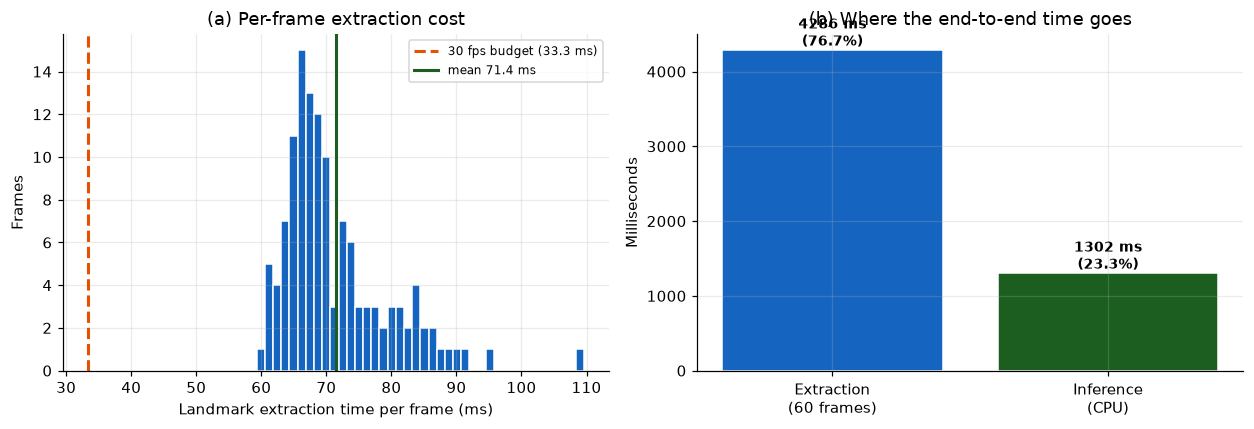

11699

In [27]:
def latency_percentiles(predict_fn, x, n=60, warmup=10):
    for _ in range(warmup):
        predict_fn(x)
    ts = []
    for _ in range(n):
        t0 = time.perf_counter()
        predict_fn(x)
        ts.append((time.perf_counter() - t0) * 1000)
    a = np.array(ts)
    return {'mean': a.mean(), 'p50': np.percentile(a, 50), 'p95': np.percentile(a, 95),
            'p99': np.percentile(a, 99), 'min': a.min(), 'max': a.max()}

bench_rows = []

# ---------------------------------------- landmark extraction throughput (CPU)
sample = inv_kept.sample(min(5, len(inv_kept)), random_state=0)
frames_buf, ext_ms = [], []
for r in sample.itertuples():
    cap = cv2.VideoCapture(r.path)
    buf = []
    while True:
        ok, fr = cap.read()
        if not ok:
            break
        buf.append(cv2.cvtColor(fr, cv2.COLOR_BGR2RGB))
    cap.release()
    frames_buf.append(buf)
with mp_holistic.Holistic(static_image_mode=False, model_complexity=MODEL_COMPLEXITY,
                          refine_face_landmarks=False,
                          min_detection_confidence=MIN_DET_CONF,
                          min_tracking_confidence=MIN_TRK_CONF) as h:
    for buf in frames_buf:
        for fr in buf[:5]:
            h.process(fr)                                   # warm up
    for buf in frames_buf:
        for fr in buf:
            t0 = time.perf_counter()
            h.process(fr)
            ext_ms.append(getattr(h, 'last_compute_ms', None) or (time.perf_counter() - t0) * 1000)
if not ext_ms:
    raise RuntimeError(
        'No frames could be decoded for the timing probe, so the extraction throughput '
        'cannot be measured. Check that RAW_VIDEO_DIR still points at readable video; the '
        'landmark cache alone is not enough for this section.')
ext = np.array(ext_ms)
bench_rows.append({'Stage': 'MediaPipe Holistic landmark extraction (CPU)',
                   'Unit': 'ms per frame',
                   'Mean': round(ext.mean(), 2), 'p50': round(np.percentile(ext, 50), 2),
                   'p95': round(np.percentile(ext, 95), 2),
                   'p99': round(np.percentile(ext, 99), 2),
                   'Derived': f'{1000/ext.mean():.1f} fps sustained'})

# ------------------------------------------------- inference latency, GPU/CPU
x1 = DATA['Xte'][:1]
if GPUS:
    lat_gpu = latency_percentiles(lambda x: pmodel.predict(x, verbose=0), x1)
    bench_rows.append({'Stage': 'Recognition inference, batch 1 (GPU)',
                       'Unit': 'ms per 60-frame clip',
                       'Mean': round(lat_gpu['mean'], 2), 'p50': round(lat_gpu['p50'], 2),
                       'p95': round(lat_gpu['p95'], 2), 'p99': round(lat_gpu['p99'], 2),
                       'Derived': ENV['gpu_name'] or 'GPU'})
with tf.device('/CPU:0'):
    cpu_model = keras.models.clone_model(pmodel)
    cpu_model.set_weights(pmodel.get_weights())
    lat_cpu = latency_percentiles(lambda x: cpu_model(x, training=False).numpy(), x1)
bench_rows.append({'Stage': 'Recognition inference, batch 1 (CPU)',
                   'Unit': 'ms per 60-frame clip',
                   'Mean': round(lat_cpu['mean'], 2), 'p50': round(lat_cpu['p50'], 2),
                   'p95': round(lat_cpu['p95'], 2), 'p99': round(lat_cpu['p99'], 2),
                   'Derived': f'{ENV["processor"]}, {ENV["cpu_count"]} logical cores'})

thr_x = DATA['Xte']
t0 = time.perf_counter()
pmodel.predict(thr_x, batch_size=64, verbose=0)
thr = len(thr_x) / (time.perf_counter() - t0)
bench_rows.append({'Stage': 'Recognition throughput, batch 64', 'Unit': 'clips per second',
                   'Mean': round(thr, 1), 'p50': '', 'p95': '', 'p99': '',
                   'Derived': f'{1000/thr:.2f} ms per clip amortized'})

e2e = ext.mean() * SEQ_LEN + lat_cpu['mean']
bench_rows.append({'Stage': 'End-to-end, one 60-frame clip (CPU: extraction + inference)',
                   'Unit': 'ms', 'Mean': round(e2e, 1), 'p50': '', 'p95': '', 'p99': '',
                   'Derived': f'{e2e/1000:.2f} s; the clip itself lasts '
                              f'{SEQ_LEN/30:.2f} s at 30 fps'})
bench_rows.append({'Stage': 'Real-time factor (extraction time / clip duration)',
                   'Unit': 'ratio', 'Mean': round(e2e / (SEQ_LEN / 30 * 1000), 3),
                   'p50': '', 'p95': '', 'p99': '',
                   'Derived': 'below 1.0 means the pipeline keeps up with the stream'})
budget = 1000 / 30
bench_rows.append({'Stage': f'Per-frame budget at 30 fps ({budget:.1f} ms)',
                   'Unit': 'verdict', 'Mean': '', 'p50': '', 'p95': '', 'p99': '',
                   'Derived': ('within budget'
                               if ext.mean() < budget else
                               f'EXCEEDED by {ext.mean()-budget:.1f} ms per frame')})
save_table(pd.DataFrame(bench_rows), 'table_runtime_benchmark',
    'REVIEWER B COMMENT 14. Measured latency of every stage, with percentiles, on this '
    'runtime. Landmark extraction dominates: it is a CPU-bound per-frame cost, whereas '
    'classification runs once per clip. Two rules for the manuscript: quote the CPU figures, '
    'because the deployment argument in Section 4.7.2 is about commodity hardware; and name '
    'the device, because a Colab GPU is neither a phone nor a low-cost laptop. Only claim '
    'real-time operation if the per-frame verdict row says "within budget" on the TARGET '
    'device.', 'B14')

record('extraction_ms_per_frame', round(float(ext.mean()), 2),
       'Section 4.7.2 (B14): the cost that determines whether the pipeline is interactive')
record('extraction_fps', round(float(1000 / ext.mean()), 1),
       'Section 4.7.2 (B14): sustained landmark-extraction frame rate')
record('inference_ms_cpu', round(float(lat_cpu['mean']), 2),
       'Section 4.7.2 (B14): classifier latency per clip on CPU')
record('end_to_end_ms_cpu', round(float(e2e), 1),
       'Section 4.7.2 (B14): end-to-end delay for one clip on CPU')
record('real_time_verdict', str(bench_rows[-1]['Derived']),
       'Section 4.7.1 (B14): whether the term "real-time" is defensible at all')

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
axes[0].hist(ext, bins=40, color=C_ALT, edgecolor='white')
axes[0].axvline(budget, color=C_WARN, ls='--', lw=2, label=f'30 fps budget ({budget:.1f} ms)')
axes[0].axvline(ext.mean(), color=C_MAIN, lw=2, label=f'mean {ext.mean():.1f} ms')
axes[0].set_xlabel('Landmark extraction time per frame (ms)'); axes[0].set_ylabel('Frames')
axes[0].set_title('(a) Per-frame extraction cost'); axes[0].legend(fontsize=8)
stages = ['Extraction\n(60 frames)', 'Inference\n(CPU)']
vals = [ext.mean() * SEQ_LEN, lat_cpu['mean']]
axes[1].bar(stages, vals, color=[C_ALT, C_MAIN], edgecolor='white')
for i, v in enumerate(vals):
    axes[1].text(i, v, f'{v:.0f} ms\n({v/sum(vals)*100:.1f}%)', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')
axes[1].set_ylabel('Milliseconds')
axes[1].set_title('(b) Where the end-to-end time goes')
plt.tight_layout()
save_fig(fig, 'fig_runtime_benchmark',
         'Measured runtime. Panel (b) is the point for the deployment discussion: the '
         'classifier is a small fraction of the cost, so the parameter count is not what '
         'determines interactivity.', 'B14')
del cpu_model
gc.collect()

## 25. Speech synthesis stage — **Reviewer B comments 1, 7, 8, 9**

Reviewer B's point runs through four comments: MMS-VITS is a **pretrained downstream
component**, not part of the methodological contribution, and its operational configuration
is currently under-described.

This section documents it completely and keeps the boundary explicit:

* the exact checkpoint, its architecture, parameter count and sampling rate;
* that **no fine-tuning, adaptation or speaker conditioning was applied** — the checkpoint is
  used exactly as released;
* the label-to-Swahili-text mapping, which is a fixed lookup table with no language model
  and no text generation, so it is deterministic and lossless;
* the text normalization actually applied;
* every generation parameter read off the model config rather than assumed;
* measured synthesis latency and real-time factor;
* one audio file per class, plus a full end-to-end demonstration on a real test clip.

And it states what is **not** claimed: the recognition accuracy belongs to the BiLSTM with
temporal attention; the synthesizer was evaluated by its original authors and not in this
study, so no intelligibility or naturalness result is reported.

In [28]:
TTS_OK = False
if RUN_TTS:
    try:
        import torch, transformers
        from transformers import VitsModel, AutoTokenizer
        from scipy.io.wavfile import write as wav_write
        from IPython.display import Audio, display as ipy_display

        CHECKPOINT = 'facebook/mms-tts-swh'
        tts_tok = AutoTokenizer.from_pretrained(CHECKPOINT)
        tts_model = VitsModel.from_pretrained(CHECKPOINT).eval()
        SR = int(tts_model.config.sampling_rate)
        cfg = tts_model.config

        tts_cfg = {
            'reviewer_comments': ['B1', 'B7', 'B8', 'B9'],
            'role_in_the_system': 'downstream, pretrained speech-synthesis backend. It '
                'receives a label the classifier has already produced and cannot change '
                'any recognition figure reported in this paper.',
            'checkpoint': CHECKPOINT,
            'architecture': 'VITS (conditional VAE with adversarial training, Kim et al. '
                            '2021), as released by the Massively Multilingual Speech project',
            'language_code': 'swh (Swahili)',
            'fine_tuned': False,
            'adapted_to_sign_language_vocabulary': False,
            'speaker_conditioning': 'none; the checkpoint provides a single voice',
            'transformers_version': transformers.__version__,
            'torch_version': torch.__version__,
            'sampling_rate_hz': SR,
            'parameters': int(sum(p.numel() for p in tts_model.parameters())),
            'vocab_size': int(cfg.vocab_size),
            'generation_parameters': {
                'noise_scale': float(getattr(cfg, 'noise_scale', float('nan'))),
                'noise_scale_duration': float(getattr(cfg, 'noise_scale_duration',
                                                      float('nan'))),
                'speaking_rate': float(getattr(cfg, 'speaking_rate', float('nan'))),
                'flow_size': int(getattr(cfg, 'flow_size', 0)),
                'hidden_size': int(getattr(cfg, 'hidden_size', 0)),
                'note': 'read from the released configuration; no value was overridden',
            },
            'inference': 'single forward pass, torch.no_grad(), float32, CPU; the waveform '
                         'is written straight to a 16-bit PCM buffer and played back',
            'text_normalization': 'lowercase, then strip every character outside the '
                                  'Swahili alphabet and whitespace',
            'evaluation_in_this_study': 'none. No intelligibility or naturalness measurement '
                                        'is claimed. A listening study with Swahili-speaking '
                                        'participants is stated as future work.',
            'error_propagation': 'the stages are sequential and the synthesizer cannot '
                                 'detect an implausible input, so a misclassification is '
                                 'rendered as fluent, confident speech. See the '
                                 'confidence-threshold sweep for the mitigation.',
        }
        print(json.dumps(tts_cfg, indent=2))
        json.dump(tts_cfg, open(f'{OUT_DIR}/tts_config.json', 'w'), indent=2)
        register('record', 'tts_config', ['tts_config.json'],
                 'Complete operational configuration of the MMS-VITS speech stage: '
                 'checkpoint, architecture, parameter count, sampling rate, generation '
                 'parameters, normalization, and an explicit statement that no fine-tuning '
                 'or evaluation was performed.', 'B1, B7, B8, B9')

        # ---- label -> Swahili text lookup (deterministic, no language model) ----
        LABEL_TO_TEXT = {c: c for c in CLASS_LIST}
        LABEL_TO_PHRASE = {
            'habari': 'habari', 'baba': 'baba', 'mama': 'mama', 'kula': 'kula',
            'nenda': 'nenda', 'njema': 'njema', 'hedhi': 'hedhi', 'siku': 'siku',
        }
        LABEL_TO_TEXT.update({k: v for k, v in LABEL_TO_PHRASE.items() if k in CLASS_LIST})
        mapping_tbl = pd.DataFrame([
            {'Class index': CLASS_TO_IDX[c], 'Gesture label': c,
             'English meaning': GLOSS_EN.get(c, ''),
             'Swahili text passed to the synthesizer': LABEL_TO_TEXT[c]}
            for c in CLASS_LIST])
        save_table(mapping_tbl, 'table_label_to_speech_mapping',
                   'The fixed lookup table that converts a class index into Swahili text. '
                   'No language model and no text generation are involved, so the mapping '
                   'is deterministic and lossless -- which is what Section 3.7 asserts and '
                   'this table verifies.', 'B7')
        json.dump(LABEL_TO_TEXT, open(f'{OUT_DIR}/label_to_text.json', 'w'), indent=2)

        SWAHILI_ALPHABET = set('abcdefghijklmnopqrstuvwxyz ')
        def normalize_text(s):
            return ''.join(ch for ch in s.lower().strip() if ch in SWAHILI_ALPHABET)

        rows = []
        for c in CLASS_LIST:
            text = normalize_text(LABEL_TO_TEXT[c])
            enc = tts_tok(text, return_tensors='pt')
            t0 = time.perf_counter()
            with torch.no_grad():
                wave = tts_model(**enc).waveform
            ms = (time.perf_counter() - t0) * 1000
            audio = wave.squeeze().cpu().numpy()
            path = f'{OUT_DIR}/audio/{c}.wav'
            wav_write(path, SR, (np.clip(audio, -1, 1) * 32767).astype(np.int16))
            dur = len(audio) / SR
            rows.append({'Class': c, 'Swahili text': text,
                         'Tokens': int(enc['input_ids'].shape[-1]),
                         'Audio duration (s)': round(dur, 3),
                         'Synthesis latency (ms)': round(ms, 1),
                         'Real-time factor': round(ms / 1000 / dur, 4),
                         'File': f'audio/{c}.wav'})
            print(f'  {c:10s} -> "{text}"  {dur:.2f}s  ({ms:.0f} ms)')
        tts_tbl = pd.DataFrame(rows)
        save_table(tts_tbl, 'table_speech_synthesis',
                   'Measured behaviour of the pretrained speech stage per class: token '
                   'count, audio duration, synthesis latency and real-time factor on CPU. '
                   'These are properties of a released model used unchanged, not results '
                   'of this study (Reviewer B comments 8 and 9).', 'B7, B14')
        register('record', 'audio', [f'audio/{c}.wav' for c in CLASS_LIST],
                 'One synthesized Swahili utterance per gesture class, produced by the '
                 'documented checkpoint and configuration.', 'B7')
        record('tts_parameters', tts_cfg['parameters'],
               'Section 3.7: size of the pretrained synthesizer, for contrast with the '
               'recognition model. Makes the point that the large component is the one '
               'this study did not train.')
        record('tts_mean_latency_ms', round(float(tts_tbl['Synthesis latency (ms)'].mean()), 1),
               'Section 4.7.2: synthesis latency, if end-to-end interaction cost is quoted')
        ipy_display(Audio(f'{OUT_DIR}/audio/{CLASS_LIST[0]}.wav'))

        # ---- full pipeline demonstration on real test clips ----------------
        print('\nEnd-to-end demonstration (video -> landmarks -> label -> Swahili speech):')
        demo_rows = []
        for k in range(min(3, len(yte))):
            pr = proba[k]
            pc_ = CLASS_LIST[pr.argmax()]
            demo_rows.append({'Test clip': ids_raw[te_i][k], 'Signer': g_raw[te_i][k],
                              'True class': CLASS_LIST[yte[k]], 'Predicted': pc_,
                              'Confidence': round(float(pr.max()), 4),
                              'Correct': bool(pr.argmax() == yte[k]),
                              'Spoken text': normalize_text(LABEL_TO_TEXT[pc_]),
                              'Audio': f'audio/{pc_}.wav'})
            print(f"  {ids_raw[te_i][k]:28s} true={CLASS_LIST[yte[k]]:8s} "
                  f"pred={pc_:8s} conf={pr.max():.3f}")
        save_table(pd.DataFrame(demo_rows), 'table_end_to_end_demonstration',
                   'The complete pipeline exercised on real test clips: the recognition '
                   'decision, its confidence, and the Swahili string handed to the '
                   'synthesizer. Note that an incorrect row is still spoken confidently, '
                   'which is the error-propagation property Section 4.7.2 discusses.',
                   'B7, B8')
        ipy_display(Audio(f'{OUT_DIR}/audio/{demo_rows[0]["Predicted"]}.wav'))
        TTS_OK = True
    except Exception as e:
        print(f'Speech synthesis stage skipped: {type(e).__name__}: {e}')
        print('Set RUN_TTS = False to silence this, or check the transformers install.')
else:
    print('Speech synthesis disabled (RUN_TTS = False).')

Some weights of the model checkpoint at facebook/mms-tts-swh were not used when initializing VitsModel: ['flow.flows.0.wavenet.in_layers.0.weight_g', 'flow.flows.0.wavenet.in_layers.0.weight_v', 'flow.flows.0.wavenet.in_layers.1.weight_g', 'flow.flows.0.wavenet.in_layers.1.weight_v', 'flow.flows.0.wavenet.in_layers.2.weight_g', 'flow.flows.0.wavenet.in_layers.2.weight_v', 'flow.flows.0.wavenet.in_layers.3.weight_g', 'flow.flows.0.wavenet.in_layers.3.weight_v', 'flow.flows.0.wavenet.res_skip_layers.0.weight_g', 'flow.flows.0.wavenet.res_skip_layers.0.weight_v', 'flow.flows.0.wavenet.res_skip_layers.1.weight_g', 'flow.flows.0.wavenet.res_skip_layers.1.weight_v', 'flow.flows.0.wavenet.res_skip_layers.2.weight_g', 'flow.flows.0.wavenet.res_skip_layers.2.weight_v', 'flow.flows.0.wavenet.res_skip_layers.3.weight_g', 'flow.flows.0.wavenet.res_skip_layers.3.weight_v', 'flow.flows.1.wavenet.in_layers.0.weight_g', 'flow.flows.1.wavenet.in_layers.0.weight_v', 'flow.flows.1.wavenet.in_layers.1.wei

Some weights of VitsModel were not initialized from the model checkpoint at facebook/mms-tts-swh and are newly initialized: ['flow.flows.0.wavenet.in_layers.0.parametrizations.weight.original0', 'flow.flows.0.wavenet.in_layers.0.parametrizations.weight.original1', 'flow.flows.0.wavenet.in_layers.1.parametrizations.weight.original0', 'flow.flows.0.wavenet.in_layers.1.parametrizations.weight.original1', 'flow.flows.0.wavenet.in_layers.2.parametrizations.weight.original0', 'flow.flows.0.wavenet.in_layers.2.parametrizations.weight.original1', 'flow.flows.0.wavenet.in_layers.3.parametrizations.weight.original0', 'flow.flows.0.wavenet.in_layers.3.parametrizations.weight.original1', 'flow.flows.0.wavenet.res_skip_layers.0.parametrizations.weight.original0', 'flow.flows.0.wavenet.res_skip_layers.0.parametrizations.weight.original1', 'flow.flows.0.wavenet.res_skip_layers.1.parametrizations.weight.original0', 'flow.flows.0.wavenet.res_skip_layers.1.parametrizations.weight.original1', 'flow.flows

{
  "reviewer_comments": [
    "B1",
    "B7",
    "B8",
    "B9"
  ],
  "role_in_the_system": "downstream, pretrained speech-synthesis backend. It receives a label the classifier has already produced and cannot change any recognition figure reported in this paper.",
  "checkpoint": "facebook/mms-tts-swh",
  "architecture": "VITS (conditional VAE with adversarial training, Kim et al. 2021), as released by the Massively Multilingual Speech project",
  "language_code": "swh (Swahili)",
  "fine_tuned": false,
  "adapted_to_sign_language_vocabulary": false,
  "speaker_conditioning": "none; the checkpoint provides a single voice",
  "transformers_version": "4.44.2",
  "torch_version": "2.2.2",
  "sampling_rate_hz": 16000,
  "parameters": 36284784,
  "vocab_size": 39,
  "generation_parameters": {
    "noise_scale": 0.667,
    "noise_scale_duration": 0.8,
    "speaking_rate": 1.0,
    "flow_size": 192,
    "hidden_size": 192,
    "note": "read from the released configuration; no value was ove

,Class index,Gesture label,English meaning,Swahili text passed to the synthesizer
0,0,nenda,go,nenda
1,1,njema,good,njema
2,2,mama,mother,mama
3,3,hedhi,menstruation,hedhi
4,4,kula,eat,kula
5,5,baba,father,baba
6,6,habari,hi,habari


  nenda      -> "nenda"  0.85s  (2257 ms)


...

  baba       -> "baba"  0.51s  (670 ms)


  habari     -> "habari"  1.04s  (761 ms)

--- table_speech_synthesis   [B7, B14]
Measured behaviour of the pretrained speech stage per class: token count, audio duration, synthesis
latency and real-time factor on CPU. These are properties of a released model used unchanged, not
results of this study (Reviewer B comments 8 and 9).


,Class,Swahili text,Tokens,Audio duration (s),Synthesis latency (ms),Real-time factor,File
0,nenda,nenda,11,0.848,2256.8,2.6613,audio/nenda.wav
1,njema,njema,11,1.056,786.5,0.7448,audio/njema.wav
2,mama,mama,9,0.416,822.4,1.9770,audio/mama.wav
3,hedhi,hedhi,11,0.720,537.8,0.7470,audio/hedhi.wav
4,kula,kula,9,0.784,676.2,0.8625,audio/kula.wav
5,baba,baba,9,0.512,669.8,1.3082,audio/baba.wav
6,habari,habari,13,1.040,760.7,0.7315,audio/habari.wav



End-to-end demonstration (video -> landmarks -> label -> Swahili speech):
  baba__Britney_004            true=baba     pred=baba     conf=1.000
  baba__Britney_005            true=baba     pred=baba     conf=1.000
  baba__Britney_017            true=baba     pred=baba     conf=1.000

--- table_end_to_end_demonstration   [B7, B8]
The complete pipeline exercised on real test clips: the recognition decision, its confidence, and
the Swahili string handed to the synthesizer. Note that an incorrect row is still spoken
confidently, which is the error-propagation property Section 4.7.2 discusses.


,Test clip,Signer,True class,Predicted,Confidence,Correct,Spoken text,Audio
0,baba__Britney_004,Britney,baba,baba,0.9996,True,baba,audio/baba.wav
1,baba__Britney_005,Britney,baba,baba,0.9998,True,baba,audio/baba.wav
2,baba__Britney_017,Britney,baba,baba,0.9997,True,baba,audio/baba.wav


## 26. Fidelity check against the published configuration

The experiment grid ran with dropout on the recurrent layer *inputs* so that the cuDNN LSTM
kernel stays available (§2). Table 6 of the manuscript specifies `recurrent_dropout = 0.2`.

This section retrains the proposed model with the published setting — genuinely slow, which
is why it is not used for the whole grid — and compares. If the two agree within the
cross-seed spread, the manuscript can keep Table 6 as written and the substitution is an
implementation detail. If they disagree, Table 6 must be updated to describe what was
actually run. Either way, the decision rests on a measurement.

In [29]:
FID = None
if RUN_FIDELITY_CHECK:
    print('Retraining the proposed model with the published recurrent_dropout = 0.2.')
    print('This uses the generic (non-cuDNN) LSTM kernel and is several times slower.\n')
    _saved = FAST_RECURRENT
    FAST_RECURRENT = False
    try:
        FID = run_multi_seed(build_proposed, DATA, 'proposed_published_recdrop',
                             seeds=SEEDS)
    finally:
        FAST_RECURRENT = _saved

    fid_tbl = pd.DataFrame([
        {'Configuration': 'Dropout on recurrent-layer inputs (used for the grid)',
         'recurrent_dropout': 0.0, 'input dropout': REC_DROPOUT,
         'cuDNN kernel': 'yes',
         'Test accuracy (%)': fmt_pm(prop['accuracy_mean'], prop['accuracy_std']),
         'Macro F1 (%)': fmt_pm(prop['macro_f1_mean'], prop['macro_f1_std']),
         'Mean epoch time (s)': round(prop['train_time_s_mean'] / max(prop['epochs_run_mean'], 1), 2)},
        {'Configuration': 'Recurrent dropout as published in Table 6',
         'recurrent_dropout': REC_DROPOUT, 'input dropout': 0.0,
         'cuDNN kernel': 'no',
         'Test accuracy (%)': fmt_pm(FID['accuracy_mean'], FID['accuracy_std']),
         'Macro F1 (%)': fmt_pm(FID['macro_f1_mean'], FID['macro_f1_std']),
         'Mean epoch time (s)': round(FID['train_time_s_mean'] / max(FID['epochs_run_mean'], 1), 2)},
    ])
    d_pp = (FID['accuracy_mean'] - prop['accuracy_mean']) * 100
    pooled = math.sqrt(prop['accuracy_std'] ** 2 + FID['accuracy_std'] ** 2) * 100
    save_table(fid_tbl, 'table_dropout_fidelity_check',
        f'The two dropout placements, same architecture and protocol. Difference: '
        f'{d_pp:+.2f} pp against a pooled cross-seed spread of {pooled:.2f} pp. '
        + ('The two are indistinguishable, so Table 6 of the manuscript stands as written '
           'and the cuDNN substitution is an implementation detail.'
           if abs(d_pp) <= max(pooled, 1.0) else
           'The two differ by more than the cross-seed spread, so Table 6 must state which '
           'placement produced the reported numbers.'), 'B6')
    record('fidelity_delta_pp', round(d_pp, 2),
           'Section 3.6 / Table 6: difference between the two dropout placements')
    print(f'\nDifference: {d_pp:+.2f} pp (pooled spread {pooled:.2f} pp)')
else:
    print('Fidelity check disabled (RUN_FIDELITY_CHECK = False).')

Fidelity check disabled (RUN_FIDELITY_CHECK = False).


## 27. Diagrams — **Reviewer A comment 15** and **Reviewer B comment 5**

Two figures, drawn with the measured dimensions of this run rather than with the numbers in
the current text.

**Figure A (B5)** is the landmark pipeline the reviewer specified step by step: video frame →
MediaPipe Holistic → 33 pose + 21 left-hand + 21 right-hand landmarks → 258 features →
60 × 258 sequence → BiLSTM.

**Figure B (A15)** is the full system architecture, with the recognition stage — the
contribution of this study — visually separated from the downstream pretrained speech
synthesis stage. That separation is also what **Reviewer B comments 1, 8 and 9** ask the
manuscript to make unambiguous, so one figure answers four comments. It replaces the current
Figure 1.

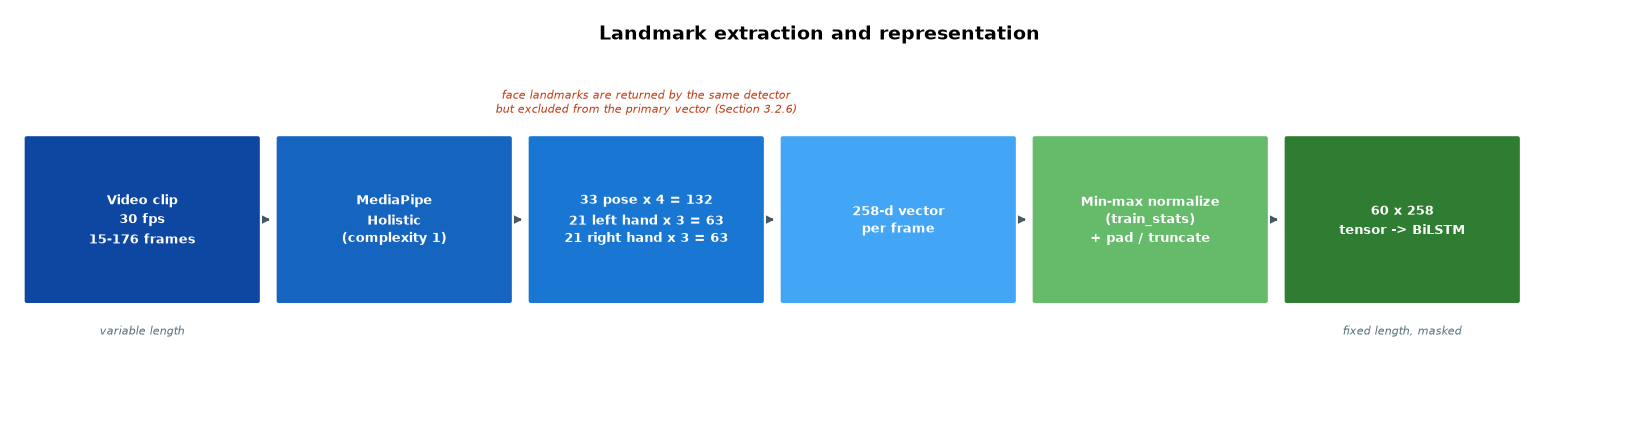

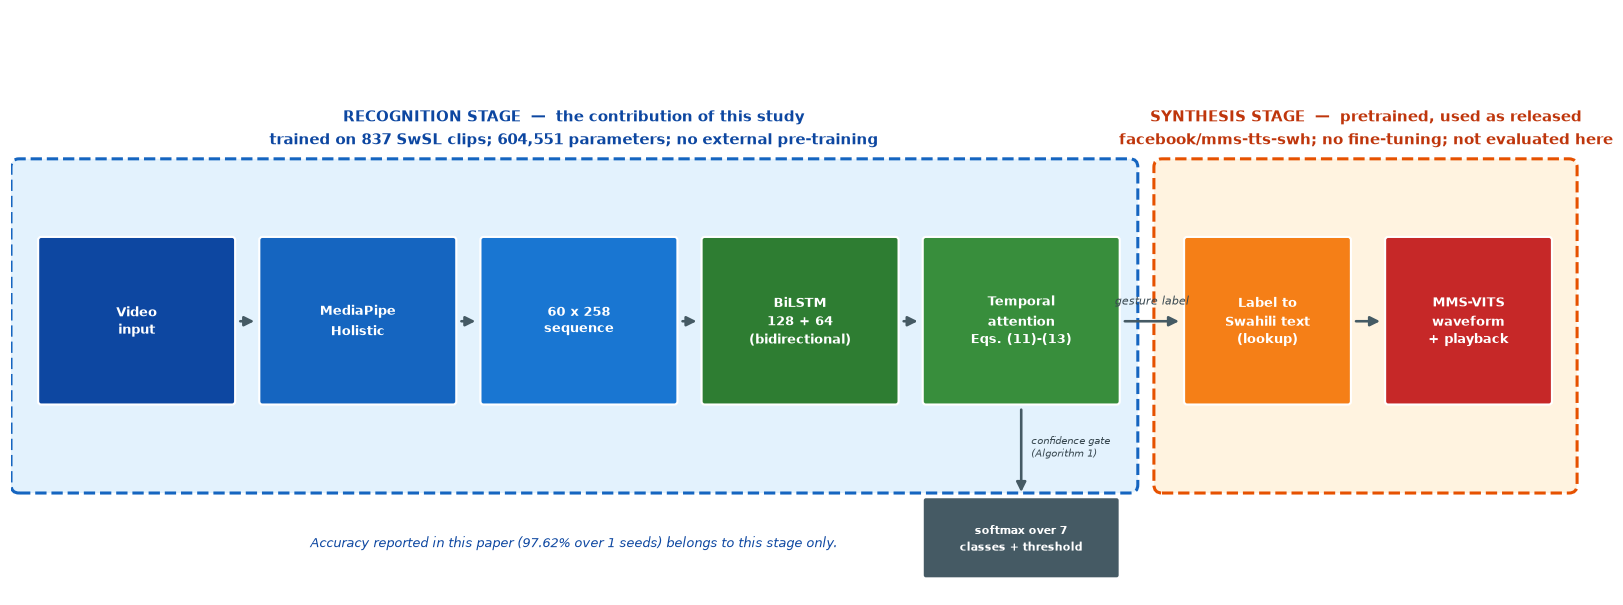

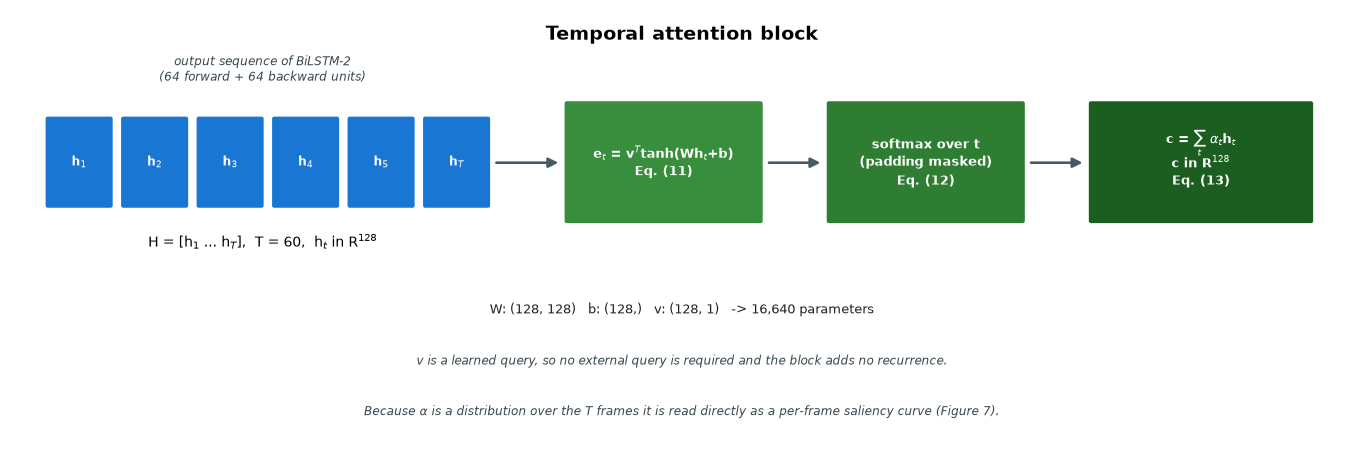

'fig_attention_block'

In [30]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def box(ax, x, y, w, h, text, fc, tc='white', fs=8.5, ec='white'):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.03',
                                facecolor=fc, edgecolor=ec, lw=1.4, zorder=3))
    ax.text(x + w / 2, y + h / 2, text, ha='center', va='center', color=tc,
            fontsize=fs, fontweight='bold', zorder=4, linespacing=1.45)

def arrow(ax, x1, y1, x2, y2, label=None, color='#455A64'):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='-|>',
                                 mutation_scale=13, color=color, lw=1.7, zorder=2))
    if label:
        ax.text((x1 + x2) / 2, y1 + 0.16, label, ha='center', fontsize=7,
                style='italic', color='#37474F', zorder=4)

# ================================================ Figure A: landmark pipeline
fig, ax = plt.subplots(figsize=(15, 4.0))
ax.set_xlim(0, 15.4); ax.set_ylim(0, 4.0); ax.axis('off'); ax.grid(False)
stages = [
    (0.15, 'Video clip\n30 fps\n' + f'{int(raw_len.min())}-{int(raw_len.max())} frames', '#0D47A1'),
    (2.55, 'MediaPipe\nHolistic\n(complexity 1)', '#1565C0'),
    (4.95, '33 pose x 4 = 132\n21 left hand x 3 = 63\n21 right hand x 3 = 63', '#1976D2'),
    (7.35, f'{FEAT_DIM}-d vector\nper frame', '#42A5F5'),
    (9.75, f'Min-max normalize\n({NORMALIZATION})\n+ pad / truncate', '#66BB6A'),
    (12.15, f'{SEQ_LEN} x {FEAT_DIM}\ntensor -> BiLSTM', '#2E7D32'),
]
for x, t, c in stages:
    box(ax, x, 1.15, 2.2, 1.6, t, c)
for i in range(len(stages) - 1):
    arrow(ax, stages[i][0] + 2.25, 1.95, stages[i + 1][0] - 0.05, 1.95)
ax.text(0.15 + 1.1, 0.82, 'variable length', ha='center', fontsize=7, style='italic',
        color=C_GREY)
ax.text(12.15 + 1.1, 0.82, 'fixed length, masked', ha='center', fontsize=7, style='italic',
        color=C_GREY)
ax.text(4.95 + 1.1, 3.0, 'face landmarks are returned by the same detector\n'
                         'but excluded from the primary vector (Section 3.2.6)',
        ha='center', fontsize=7.5, color='#BF360C', style='italic')
ax.text(7.7, 3.72, 'Landmark extraction and representation',
        ha='center', fontsize=12.5, fontweight='bold')
plt.tight_layout()
save_fig(fig, 'fig_landmark_pipeline',
         'REVIEWER B COMMENT 5. The path from one video frame to the model input tensor, '
         'with every dimension shown: 33 pose + 21 + 21 hand landmarks, 258 features per '
         'frame, 60 x 258 per clip.', 'B5')

# ============================================ Figure B: system architecture
fig, ax = plt.subplots(figsize=(15.2, 5.6))
ax.set_xlim(0, 15.6); ax.set_ylim(0, 5.6); ax.axis('off'); ax.grid(False)

ax.add_patch(FancyBboxPatch((0.08, 1.05), 11.05, 3.05, boxstyle='round,pad=0.08',
                            facecolor='#E3F2FD', edgecolor='#1565C0', lw=2.0, ls='--',
                            zorder=0))
ax.text(5.6, 4.32, 'RECOGNITION STAGE  —  the contribution of this study\n'
        f'trained on {len(inv_kept)} SwSL clips; {pmodel.count_params():,} parameters; '
        f'no external pre-training',
        ha='center', fontsize=10, fontweight='bold', color='#0D47A1', linespacing=1.5)

ax.add_patch(FancyBboxPatch((11.45, 1.05), 4.05, 3.05, boxstyle='round,pad=0.08',
                            facecolor='#FFF3E0', edgecolor='#E65100', lw=2.0, ls='--',
                            zorder=0))
ax.text(13.48, 4.32, 'SYNTHESIS STAGE  —  pretrained, used as released\n'
        'facebook/mms-tts-swh; no fine-tuning; not evaluated here',
        ha='center', fontsize=10, fontweight='bold', color='#BF360C', linespacing=1.5)

rec = [(0.3, 'Video\ninput', '#0D47A1'),
       (2.5, 'MediaPipe\nHolistic', '#1565C0'),
       (4.7, f'{SEQ_LEN} x {FEAT_DIM}\nsequence', '#1976D2'),
       (6.9, 'BiLSTM\n128 + 64\n(bidirectional)', '#2E7D32'),
       (9.1, 'Temporal\nattention\nEqs. (11)-(13)', '#388E3C')]
for x, t, c in rec:
    box(ax, x, 1.85, 1.9, 1.55, t, c)
for i in range(len(rec) - 1):
    arrow(ax, rec[i][0] + 1.95, 2.62, rec[i + 1][0] - 0.05, 2.62)

box(ax, 11.7, 1.85, 1.6, 1.55, 'Label to\nSwahili text\n(lookup)', '#F57F17')
box(ax, 13.7, 1.85, 1.6, 1.55, 'MMS-VITS\nwaveform\n+ playback', '#C62828')
arrow(ax, 11.05, 2.62, 11.65, 2.62, 'gesture label')
arrow(ax, 13.35, 2.62, 13.65, 2.62)

box(ax, 9.1, 0.18, 1.9, 0.72,
    f'softmax over {N_CLASSES}\nclasses + threshold', '#455A64', fs=7.5)
arrow(ax, 10.05, 1.8, 10.05, 0.95, color='#455A64')
ax.text(10.15, 1.32, 'confidence gate\n(Algorithm 1)', fontsize=6.8, style='italic',
        color='#37474F', ha='left')

ax.text(5.6, 0.45,
        f'Accuracy reported in this paper ({NUMBERS.get("proposed_accuracy_mean", {}).get("value", "--")}% '
        f'over {len(SEEDS)} seeds) belongs to this stage only.',
        ha='center', fontsize=8.5, color='#0D47A1', style='italic')
plt.tight_layout()
save_fig(fig, 'fig_system_architecture',
         'REVIEWER A COMMENT 15, and the figure that settles Reviewer B comments 1, 8 and 9. '
         'The end-to-end system with the recognition stage (this study) separated from the '
         'pretrained speech-synthesis stage. Replaces the current Figure 1, whose single '
         'undifferentiated chain is what invited the reviewers to read MMS-VITS as part of '
         'the contribution.', 'A15, B1, B5, B8, B9')

# ==================================== Figure C: attention block, drawn in detail
fig, ax = plt.subplots(figsize=(12.5, 4.4))
ax.set_xlim(0, 12.8); ax.set_ylim(0, 4.4); ax.axis('off'); ax.grid(False)
for k in range(6):
    x = 0.35 + k * 0.72
    box(ax, x, 2.5, 0.6, 0.85, f'h$_{{{k+1 if k<5 else "T"}}}$', '#1976D2', fs=8)
ax.text(2.4, 2.1, f'H = [h$_1$ ... h$_T$],  T = {SEQ_LEN},  h$_t$ in R$^{{128}}$',
        ha='center', fontsize=9)
ax.text(2.4, 3.72, 'output sequence of BiLSTM-2\n(64 forward + 64 backward units)',
        ha='center', fontsize=8, style='italic', color='#37474F')
arrow(ax, 4.6, 2.92, 5.25, 2.92)
box(ax, 5.3, 2.35, 1.85, 1.15, 'e$_t$ = v$^T$tanh(Wh$_t$+b)\nEq. (11)', '#388E3C', fs=8.5)
arrow(ax, 7.2, 2.92, 7.75, 2.92)
box(ax, 7.8, 2.35, 1.85, 1.15,
    'softmax over t\n(padding masked)\nEq. (12)', '#2E7D32', fs=8.5)
arrow(ax, 9.7, 2.92, 10.25, 2.92)
box(ax, 10.3, 2.35, 2.1, 1.15,
    'c = $\\sum_t$ $\\alpha_t$h$_t$\nc in R$^{128}$\nEq. (13)', '#1B5E20', fs=8.5)
ax.text(6.4, 1.45, f'W: (128, 128)   b: (128,)   v: (128, 1)   '
                   f'-> {att_layer.count_params():,} parameters',
        ha='center', fontsize=8.5, color='#212121')
ax.text(6.4, 0.95, 'v is a learned query, so no external query is required and the block '
                   'adds no recurrence.', ha='center', fontsize=8, style='italic',
        color='#37474F')
ax.text(6.4, 0.45, 'Because $\\alpha$ is a distribution over the T frames it is read '
                   'directly as a per-frame saliency curve (Figure 7).',
        ha='center', fontsize=8, style='italic', color='#37474F')
ax.text(6.4, 4.12, 'Temporal attention block', ha='center', fontsize=12.5,
        fontweight='bold')
plt.tight_layout()
save_fig(fig, 'fig_attention_block',
         'REVIEWER A COMMENT 5, drawn. The attention block with its input, its three '
         'equations, its parameter shapes and its output dimensionality, so Section 3.5 can '
         'be checked against it without reading code.', 'A5')

## 28. Public release bundle — **Reviewer A comment 14**

Reviewer A asks that the dataset and implementation be made public on GitHub or Zenodo, and
Reviewer B treats the corpus as a principal contribution. This section assembles a release
directory ready to upload:

* **the landmark dataset** as a single compressed `.npz` — the 60 × 258 sequences, labels,
  signer identities, clip ids and the fixed partition indices, so anyone can reproduce every
  number without the raw video (which carries identifiable images of the signers and needs a
  separate consent decision);
* the trained model, the fitted normalization constants and the label mapping;
* `README.md`, `LICENSE`, `CITATION.cff`, `requirements.txt` and a data dictionary;
* the full configuration and the reviewer evidence map.

Raw video is deliberately **not** included. Publishing the landmark corpus under an open
licence while keeping the video under controlled access is the standard arrangement for
sign-language data and is what the manuscript's Data Availability Statement should describe.

In [31]:
# Built outside OUT_DIR: the zip below goes into the results archive, so keeping the
# loose directory there as well would double its size.
REL = ('/content/swsl_release' if os.path.isdir('/content')
       else os.path.abspath(f'{OUT_DIR}/../swsl_release'))
os.makedirs(REL, exist_ok=True)

np.savez_compressed(
    f'{REL}/swsl_landmarks_v1.npz',
    X=X_raw[:, :, PRIMARY].astype(np.float32),
    y=y_idx.astype(np.int16),
    classes=np.array(CLASS_LIST, dtype=object),
    signers=np.array(g_raw, dtype=object),
    clip_ids=np.array(ids_raw, dtype=object),
    raw_lengths=raw_len.astype(np.int32),
    train_idx=tr_i.astype(np.int32), val_idx=va_i.astype(np.int32),
    test_idx=te_i.astype(np.int32),
)
ds_mb = os.path.getsize(f'{REL}/swsl_landmarks_v1.npz') / 1e6

norm = DATA['norm']
if norm.min_ is not None:
    np.savez(f'{REL}/normalization_constants.npz', min=norm.min_, max=norm.max_,
             range=norm.range_)
pmodel.save(f'{REL}/swsl_bilstm_attention.keras')
shutil.copy(f'{OUT_DIR}/config.json', f'{REL}/config.json')
shutil.copy(f'{OUT_DIR}/attention_specification.json', f'{REL}/attention_specification.json')
if os.path.exists(f'{OUT_DIR}/label_to_text.json'):
    shutil.copy(f'{OUT_DIR}/label_to_text.json', f'{REL}/label_to_text.json')

pd.DataFrame([
    ['X', f'float32 ({len(X_raw)}, {SEQ_LEN}, {FEAT_DIM})',
     'Landmark sequences, zero-padded / truncated to 60 frames. Feature order per frame: '
     '33 pose landmarks x (x, y, z, visibility) = 132, then 21 left-hand x (x, y, z) = 63, '
     'then 21 right-hand x (x, y, z) = 63. NOT normalized: apply the constants in '
     'normalization_constants.npz.'],
    ['y', f'int16 ({len(y_idx)},)', 'Class index into `classes`.'],
    ['classes', f'object ({N_CLASSES},)', 'Gesture labels in index order.'],
    ['signers', f'object ({len(g_raw)},)', 'Signer identity per clip, for '
     'signer-independent evaluation.'],
    ['clip_ids', f'object ({len(ids_raw)},)', 'Stable clip identifier, "class__filename".'],
    ['raw_lengths', f'int32 ({len(raw_len)},)', 'Frame count before standardization.'],
    ['train_idx / val_idx / test_idx', 'int32',
     'The exact partition used in the paper (stratified, random_state=42). Augmentation is '
     'applied to train_idx only.'],
], columns=['Array', 'Type and shape', 'Description']).to_csv(
    f'{REL}/data_dictionary.csv', index=False)

open(f'{REL}/requirements.txt', 'w').write(
    f'# Versions this pipeline was run with\n'
    f'tensorflow=={ENV["tensorflow"]}\nkeras=={ENV["keras"]}\n'
    f'mediapipe=={ENV["mediapipe"]}\nnumpy=={ENV["numpy"]}\npandas=={ENV["pandas"]}\n'
    f'opencv-python=={ENV["opencv"]}\nscikit-learn\nscipy\nstatsmodels\nmatplotlib\n'
    f'transformers\ntorch\n')

open(f'{REL}/CITATION.cff', 'w').write(f'''cff-version: 1.2.0
title: "Swahili Sign Language (SwSL) isolated-gesture landmark corpus and BiLSTM-attention recognizer"
message: "If you use this dataset or code, please cite the accompanying article."
type: dataset
authors:
  - family-names: Nicholaus
    given-names: Mrindoko
  - family-names: Singano
    given-names: Betty J.
  - family-names: Mtowe
    given-names: Robert J.
  - family-names: William
    given-names: Sinbad R.
  - family-names: Magembe
    given-names: Festo K.
keywords:
  - Swahili Sign Language
  - isolated sign language recognition
  - MediaPipe Holistic
  - BiLSTM
  - temporal attention
  - low-resource languages
license: CC-BY-4.0
date-released: "{time.strftime('%Y-%m-%d')}"
''')

open(f'{REL}/LICENSE', 'w').write(
    'The landmark dataset in this release is licensed CC BY 4.0.\n'
    'The source code is licensed MIT.\n\n'
    'Raw video recordings are NOT included. They contain identifiable images of the two\n'
    'signers and are available from the corresponding author under a data-use agreement.\n')

open(f'{REL}/README.md', 'w').write(f'''# SwSL isolated-gesture landmark corpus and recognizer

Companion release for *A Swahili Sign Language Recognition Using Bidirectional Long
Short-Term Memory with Temporal Attention*.

## Contents

| File | What it is |
|---|---|
| `swsl_landmarks_v1.npz` | {len(X_raw)} landmark sequences, {SEQ_LEN} x {FEAT_DIM}, with labels, signer ids and the exact paper partition ({ds_mb:.1f} MB) |
| `normalization_constants.npz` | The fitted min/max per feature dimension. Fitted on the training partition only |
| `swsl_bilstm_attention.keras` | The trained recognition model ({pmodel.count_params():,} parameters) |
| `config.json` | Every setting behind the reported numbers |
| `attention_specification.json` | Full specification of the temporal attention block |
| `label_to_text.json` | Class index to Swahili text, for the speech stage |
| `data_dictionary.csv` | Field-by-field description of the dataset arrays |

## Corpus

- **{N_CLASSES} isolated gestures**: {", ".join(f"{c} ({GLOSS_EN.get(c, '')})" for c in CLASS_LIST)}
- **{len(SIGNERS)} signers**: {", ".join(SIGNERS)}
- **{len(inv_kept)} validated clips**, 30 fps, recorded indoors against a plain wall
- Landmarks from MediaPipe Holistic (model complexity {MODEL_COMPLEXITY},
  min detection / tracking confidence {MIN_DET_CONF} / {MIN_TRK_CONF})
- Face landmarks were extracted but are excluded from the released 258-d vector; see the
  ablation results in the article

## Reproducing the results

```python
import numpy as np, keras
d = np.load('swsl_landmarks_v1.npz', allow_pickle=True)
n = np.load('normalization_constants.npz')
X = (d['X'] - n['min']) / n['range']
model = keras.models.load_model('swsl_bilstm_attention.keras')
te = d['test_idx']
print((model.predict(X[te]).argmax(1) == d['y'][te]).mean())
```

Augmentation is applied to `train_idx` only: seven variants per clip (original, temporal
stretch at {AUG_STRETCH[0]}x and {AUG_STRETCH[1]}x, Gaussian jitter at sigma
{AUG_NOISE[0]} and {AUG_NOISE[1]}, temporal shift of {AUG_SHIFT[0]:+d} and
{AUG_SHIFT[1]:+d} frames). Do not augment validation or test.

## Evaluation protocols

`train_idx` / `val_idx` / `test_idx` is a sample-level stratified split: **both signers
appear in all three partitions**, so it measures generalization to unseen repetitions by
known signers. Use the `signers` array for a leave-one-signer-out protocol, which is the
signer-independent measurement.

## Licence

Landmark data CC BY 4.0; code MIT. Raw video is not released — see `LICENSE`.
''')

shutil.make_archive(f'{OUT_DIR}/swsl_release_bundle', 'zip', REL)
rel_mb = os.path.getsize(f'{OUT_DIR}/swsl_release_bundle.zip') / 1e6
register('record', 'swsl_release_bundle',
         ['swsl_release_bundle.zip'],
         'REVIEWER A COMMENT 14. A complete, self-contained release: the landmark corpus, '
         'the trained model, the normalization constants, the exact partition, a data '
         'dictionary, a licence and a citation file. Upload to Zenodo for a DOI, mirror the '
         'code on GitHub, and replace the "available upon reasonable request" sentence in '
         'the Data Availability Statement with the DOI.', 'A14')
print(f'Release bundle: {rel_mb:.1f} MB  ({REL})')
for f in sorted(os.listdir(REL)):
    print(f'  {os.path.getsize(os.path.join(REL, f))/1e6:8.2f} MB  {f}')
record('release_dataset_mb', round(ds_mb, 1),
       'Data Availability Statement: size of the releasable landmark corpus')

Release bundle: 19.0 MB  (/Volumes/MacX/Sw/swsl_release)
      0.00 MB  CITATION.cff
      0.00 MB  LICENSE
      0.00 MB  README.md
      0.00 MB  attention_specification.json
      0.00 MB  config.json
      0.00 MB  data_dictionary.csv
      0.00 MB  label_to_text.json
      0.00 MB  normalization_constants.npz
      0.00 MB  requirements.txt
      7.35 MB  swsl_bilstm_attention.keras
     12.34 MB  swsl_landmarks_v1.npz


12.3

## 29. Export: reviewer evidence map, manuscript digest, and the results archive

Four deliverables:

1. **`REVIEWER_EVIDENCE_MAP.csv`** — all 32 comments, each with its status and the file that
   answers it. This is the spine of the response letter.
2. **`MANUSCRIPT_NUMBERS.md` / `.json`** — every scalar the revision needs, with a note
   saying where in the manuscript it belongs. Nothing has to be read off a chart.
3. **`artifact_inventory.csv`** — every table and figure with its single distinct purpose,
   which is **Reviewer B comment 12**: it shows where the current manuscript repeats the
   same numbers and which artifact should survive.
4. **`swsl_results.zip`** — everything, downloaded to your machine and copied to Drive.

In [32]:
import pandas as pd, numpy as np, os, json
# ------------------------------------------------ reviewer evidence map
EV = [
 ('A', 1, 'Strengthen the problem-to-method rationale in the Introduction',
  'text + evidence',
  'tables/table09_ablation_study.csv (no-augmentation row); '
  'figures/fig_accuracy_vs_parameters.png; tables/table_parameters_vs_accuracy.csv',
  'The small-data argument is now measurable: augmentation is the largest single '
  'component, and the compact landmark models beat the high-capacity pixel models.'),
 ('A', 2, 'Section 2 must build a research gap, not summarize theory', 'text only',
  'tables/related_work_synthesis_template.csv',
  'A writing change. The template gives the columns a gap-oriented synthesis needs.'),
 ('A', 3, 'Table 1 needs signers, classes, scale, availability, setting, gaps', 'text only',
  'tables/table01_positioning_template.csv',
  'Already largely addressed in R3; the template keeps the columns consistent and omits '
  'accuracy by construction.'),
 ('A', 4, 'Justify depth, width, dropout, dense layers and regularization', 'EVIDENCE',
  'tables/table09_ablation_study.csv; figures/fig08_ablation.png',
  'Depth (1 / 2 / 3 layers), width (64-32 / 128-64 / 256-128), batch normalization, '
  'dropout and L2 each measured as a single-variable change.'),
 ('A', 5, 'Specify the attention mechanism fully and reproducibly', 'EVIDENCE',
  'attention_specification.json; figures/fig_attention_block.png; '
  'figures/fig07_attention_weights.png; tables/table_attention_concentration.csv; '
  'attention_weights_test.npy',
  'Input, dimensionality, scoring function, softmax, masking and output are specified, '
  'drawn, measured and exported; five scoring alternatives are compared.'),
 ('A', 6, 'Reconcile 840 / 5,880 / 126 and state the split order', 'EVIDENCE',
  'tables/table_split_and_augmentation.csv; tables/table_split_per_class.csv; '
  'tables/table_augmentation_variants.csv',
  'Split first, then augment the training partition only. Test = original clips, '
  'so the confusion-matrix support is reproducible.'),
 ('A', 7, 'Compare with CNN/MLP, BiLSTM/GRU, Transformer and skeleton models', 'EVIDENCE',
  'tables/table07_baseline_comparison.csv; figures/fig05_baseline_comparison.png; '
  'tables/all_runs_metrics.csv',
  'Twelve architectures across every family named, one protocol, multiple seeds.'),
 ('A', 8, 'Position Table 11 as literature positioning, not a benchmark', 'text only',
  'tables/table11_positioning.csv',
  'Accuracy columns omitted by construction; the caption states that no comparison is '
  'implied.'),
 ('A', 9, 'Superiority claims must rest on same-dataset experiments', 'EVIDENCE',
  'tables/table_mcnemar_tests.csv; tables/table_bootstrap_confidence_intervals.csv; '
  'tables/table_cross_validation_summary.csv; tables/table_seed_level_tests.csv',
  'Paired McNemar tests with Holm correction, bootstrap intervals on the difference, and '
  'repeated cross-validation. Claim only what these support.'),
 ('A', 10, 'Justify excluding the MediaPipe face landmarks', 'EVIDENCE',
  'tables/table09_ablation_study.csv (face rows); tables/table_parameter_audit.csv',
  'Measured with the full 468-landmark face stream and with a 40-landmark compact set, so '
  'the exclusion rests on a measurement rather than on a parameter-budget argument.'),
 ('A', 11, 'Consolidate Sections 4.8-4.12 into one subsection', 'text only', '-',
  'Already done in R3 as Section 4.7 "Limitations and Deployment Considerations".'),
 ('A', 12, 'Delete the applied-computer-engineering relevance subsection', 'text only', '-',
  'Already removed in R3. Confirm it in the response letter.'),
 ('A', 13, 'Separate limitations from future work', 'text only', '-',
  'Already done in R3 as Sections 4.7.1 and 4.7.3.'),
 ('A', 14, 'Release the dataset and code publicly', 'EVIDENCE',
  'swsl_release_bundle.zip; swsl_release/README.md; swsl_release/CITATION.cff',
  'Upload to Zenodo for a DOI, mirror the code on GitHub, and replace "available upon '
  'reasonable request" in the Data Availability Statement with the DOI.'),
 ('A', 15, 'Add a system architecture diagram', 'EVIDENCE',
  'figures/fig_system_architecture.png/.pdf/.svg; figures/fig_landmark_pipeline.png',
  'Recognition stage visually separated from the pretrained synthesis stage. Replaces '
  'Figure 1.'),
 ('B', 1, 'Present MMS-VITS as a downstream pretrained component', 'text + evidence',
  'tts_config.json; figures/fig_system_architecture.png',
  'The configuration record states "downstream, pretrained" first, and the diagram shows '
  'it.'),
 ('B', 2, 'Position the novelty as implementation and evaluation on low-resource SwSL',
  'text only', '-',
  'A framing change in the Introduction and Conclusions.'),
 ('B', 3, 'Cite "Bridging Communication Gaps..." in Section 2', 'text only', '-',
  'Reference [30] is a placeholder in R3; the full bibliographic details must be filled in.'),
 ('B', 4, 'Give the linguistic and visual characteristics, tied to the ablation', 'EVIDENCE',
  'tables/table_gesture_characteristics.csv; tables/table_characteristics_vs_ablation.csv; '
  'figures/fig_characteristics_correlation.png; figures/fig02_representative_frames.png',
  'Handedness, location, movement, handshape, orientation and non-manual activity measured '
  'per class, then set beside per-class recall under each feature ablation.'),
 ('B', 5, 'Diagram: frame to 33+21+21 to 258 to 60x258 to BiLSTM', 'EVIDENCE',
  'figures/fig_landmark_pipeline.png; figures/fig_landmark_overlay.png',
  'Both the schematic and the landmarks drawn on real frames.'),
 ('B', 6, 'Define the min-max normalization scope precisely', 'EVIDENCE',
  'config.json (normalization block); tables/table09_ablation_study.csv (normalization rows)',
  'Four schemes defined and all four measured; the default is fitted on the training '
  'partition only, so it is both precise and leak-free.'),
 ('B', 7, 'Document the MMS-VITS checkpoint, fine-tuning and inference configuration',
  'EVIDENCE',
  'tts_config.json; tables/table_label_to_speech_mapping.csv; '
  'tables/table_speech_synthesis.csv; audio/',
  'Checkpoint, architecture, parameters, sampling rate, generation parameters, text '
  'normalization, latency, and one audio file per class.'),
 ('B', 8, 'Attribute the accuracy to recognition, not to the synthesis stage', 'text + evidence',
  'tables/table_overall_metrics_proposed.csv; tts_config.json',
  'Every metric table is scoped to the recognition stage; the TTS record states that no '
  'evaluation of synthesis was performed.'),
 ('B', 9, 'Same as B8 (the comment is repeated)', 'text + evidence',
  'tables/table_overall_metrics_proposed.csv', 'Covered by B8.'),
 ('B', 10, 'The parameter count does not follow from the layer table', 'EVIDENCE',
  'tables/table05_parameter_audit.csv; tables/table_parameter_reconciliation.csv',
  'True layer-by-layer counts, MACs per clip and serialized size, beside the published '
  'claims. The weight-sharing footnote must be deleted.'),
 ('B', 11, 'Balanced corpus versus "class weighting is necessary"', 'EVIDENCE',
  'tables/table_class_balance_by_stage.csv; config.json (class_weighting)',
  'Imbalance measured at seven pipeline stages; the weighting policy follows from the '
  'measurement.'),
 ('B', 12, 'The same numbers are repeated across tables and figures', 'text only',
  'tables/artifact_inventory.csv',
  'Each artifact has one stated purpose. Use the inventory to decide which of the '
  'duplicated presentations to keep.'),
 ('B', 13, 'Report the confusion matrix as absolute counts', 'EVIDENCE',
  'tables/table_confusion_matrix_counts.csv; figures/fig06_confusion_matrix_counts.png; '
  'tables/table08_per_class_metrics.csv; tables/confusion_matrix_summed_over_seeds.csv',
  'The "17 (94.4%)" format, plus counts summed over seeds and absolute correct/error '
  'columns in the per-class table.'),
 ('B', 14, 'Soften real-time claims or benchmark the runtime', 'EVIDENCE',
  'tables/table_runtime_benchmark.csv; figures/fig_runtime_benchmark.png; '
  'tables/table_confidence_threshold_sweep.csv; tables/table_calibration_bins.csv',
  'Per-frame extraction cost and per-clip inference latency with percentiles on CPU and '
  'GPU, an explicit verdict against the 30 fps budget, and the threshold sweep that makes '
  'the confidence gate in Algorithm 1 concrete.'),
 ('B', 15, 'Clarify the signer-dependent protocol; run signer-independent if feasible',
  'EVIDENCE',
  'tables/table_signer_independent.csv; tables/table_protocol_comparison.csv; '
  'tables/table_signer_independent_per_class.csv; tables/table_signer_distribution.csv; '
  'figures/fig_signer_independent_confusion.png',
  'Leave-one-signer-out was run. Report the gap between the two protocols and keep the '
  'precision caveat; do not keep the claim that the measurement is impossible.'),
 ('B', 16, 'Interpret the feature ablation cautiously', 'EVIDENCE',
  'tables/table_characteristics_vs_ablation.csv; tables/table_ablation_per_class_recall.csv',
  'Framed throughout as measured feature importance in this corpus, explicitly not as a '
  'linguistic claim about SwSL.'),
 ('B', 17, 'Condense the conclusion', 'text only', 'MANUSCRIPT_NUMBERS.md',
  'Keep four things: contributions, main finding, the two binding limitations '
  '(signer dependence, unmeasured latency on target hardware), and next validation steps.'),
]
ev = pd.DataFrame(EV, columns=['Reviewer', 'No.', 'Comment', 'Kind', 'Evidence file(s)',
                               'What to say in the response'])
ev['Comment ID'] = ev.Reviewer + ev['No.'].astype(str)
ev = ev[['Comment ID', 'Reviewer', 'No.', 'Comment', 'Kind', 'Evidence file(s)',
         'What to say in the response']]
save_table(ev, 'REVIEWER_EVIDENCE_MAP',
           'All 32 reviewer comments with the artifact that answers each one. The spine of '
           'the response letter.', 'all', show=False)
ev.to_csv(f'{OUT_DIR}/REVIEWER_EVIDENCE_MAP.csv', index=False)
print(f'Reviewer comments covered: {len(ev)}')
print(ev.Kind.value_counts().to_string())

# --------------------------------------------- templates for the text-only comments
pd.DataFrame(columns=['Study / reference', 'Sign language', 'Setting (isolated/continuous)',
                      'Signers', 'Classes', 'Dataset scale (clips)',
                      'Public or private', 'Input representation',
                      'Model family', 'External pre-training',
                      'Key limitation for SwSL transfer',
                      'Gap this study addresses']).to_csv(
    f'{OUT_DIR}/tables/table01_positioning_template.csv', index=False)
register('table', 'table01_positioning_template',
         ['tables/table01_positioning_template.csv'],
         'REVIEWER A COMMENT 3. Column skeleton for Table 1. Accuracy is deliberately not a '
         'column: the studies use different corpora and protocols, so placing their numbers '
         'side by side invites a comparison the experiments do not support.', 'A3')
pd.DataFrame(columns=['Theme', 'What prior work established',
                      'Limitation of that work', 'What remains missing for SwSL',
                      'How this study addresses it', 'Citations']).to_csv(
    f'{OUT_DIR}/tables/related_work_synthesis_template.csv', index=False)
register('table', 'related_work_synthesis_template',
         ['tables/related_work_synthesis_template.csv'],
         'REVIEWER A COMMENT 2. Skeleton for the synthesis paragraph that must close '
         'Section 2, linking the literature to this study\'s contributions instead of '
         'summarizing theory.', 'A2')

# --------------------------------------------- artifact inventory (B12)
inv_art = pd.DataFrame(ARTIFACTS)[['kind', 'name', 'reviewer_comment', 'purpose', 'files']]
inv_art.columns = ['Kind', 'Artifact', 'Reviewer comment', 'Single purpose', 'Files']
inv_art.to_csv(f'{OUT_DIR}/tables/artifact_inventory.csv', index=False)
print(f'\nArtifacts produced: {len(inv_art)} '
      f'({(inv_art.Kind=="table").sum()} tables, {(inv_art.Kind=="figure").sum()} figures, '
      f'{(inv_art.Kind=="record").sum()} data records)')

# --------------------------------------------- manuscript numbers digest
json.dump(NUMBERS, open(f'{OUT_DIR}/MANUSCRIPT_NUMBERS.json', 'w'), indent=2, default=str)
def num(key, default='n/a'):
    """A recorded scalar, or a placeholder if the cell that produces it did not run."""
    v = NUMBERS.get(key, {}).get('value', default)
    return f'{v:,}' if isinstance(v, int) else v

lines = ['# Numbers for the revised manuscript', '',
         f'Generated {time.strftime("%Y-%m-%d %H:%M")} · preset `{PRESET}` · '
         f'{len(SEEDS)} seeds · {ENV["gpu_name"] or "CPU only"}', '',
         'Every value below was produced by this run. Where a value replaces one in the',
         'current manuscript, the note says where.', '',
         '| Quantity | Value | Where it belongs |', '|---|---|---|']
for k, v in NUMBERS.items():
    lines.append(f'| `{k}` | {v["value"]} | {v["note"]} |')
lines += ['', '## The five corrections this run forces', '',
          f'1. **Parameter count.** The model has '
          f'**{num("proposed_parameters")}** parameters, not '
          f'177,607. Correct the abstract, Table 5, Table 10, Table 11 and Section 4.7.2, '
          f'and delete the weight-sharing footnote.',
          f'2. **The augmented corpus size.** The training partition holds '
          f'{len(X_tr_aug):,} augmented sequences, from {len(tr_i)} original clips. '
          f'5,880 describes augmenting every partition, which is not the procedure. Replace '
          f'the augmented column of Table 2 with the per-partition table.',
          f'3. **Class weighting.** The training imbalance ratio is '
          f'{num("train_imbalance_ratio")}. '
          + ('Weighting was unnecessary; Table 6 and Eq. (15) should say so.'
             if CLASS_WEIGHT is None else
             'Weighting is justified; keep Eq. (15) and state the ratio.'),
          f'4. **Signer independence.** Leave-one-signer-out gives '
          f'{num("signer_independent_accuracy")}% against '
          f'{num("signer_dependent_accuracy")}% '
          f'signer-dependent. The claim that the experiment could not be run must go; the '
          f'precision caveat stays.',
          f'5. **Real-time.** {num("real_time_verdict")} at '
          f'{num("extraction_ms_per_frame")} ms per frame '
          f'({num("extraction_fps")} fps) on '
          f'{ENV["processor"]}. Name the device wherever a rate is quoted.',
          '', '## What the conclusion should contain (B17)', '',
          '1. Contributions: the corpus, the landmark-based recurrent classifier with '
          'temporal attention, and the single-protocol evaluation of the architectural '
          'families on that corpus.',
          '2. Main finding: temporal selectivity rather than capacity determines performance '
          'in this regime — with the ablation margins and the significance test result.',
          '3. The two binding limitations: signer dependence (now quantified) and latency '
          'unmeasured on target hardware (now measured on this one).',
          '4. Next validation steps: enlarged signer pool, phonological annotation, '
          'continuous signing, device benchmarking, listening and usability studies.',
          '', '## Do not claim', '',
          '- Superiority over published systems evaluated on other corpora. Only the '
          'same-protocol table supports a comparative claim.',
          '- Signer-independent recognition from the headline figure.',
          f'- Real-time operation on a target device that was not benchmarked.',
          '- A linguistic conclusion about the manual versus non-manual channel from the '
          'feature ablation.']
open(f'{OUT_DIR}/MANUSCRIPT_NUMBERS.md', 'w').write('\n'.join(lines))
print('\nWrote MANUSCRIPT_NUMBERS.md and .json')

# --------------------------------------------- one workbook with every table
try:
    with pd.ExcelWriter(f'{OUT_DIR}/all_tables.xlsx') as xl:
        for f in sorted(glob.glob(f'{OUT_DIR}/tables/*.csv')):
            sheet = os.path.basename(f)[:-4][:31]
            try:
                pd.read_csv(f).to_excel(xl, sheet_name=sheet, index=False)
            except Exception:
                pass
    print(f'Wrote all_tables.xlsx '
          f'({len(glob.glob(f"{OUT_DIR}/tables/*.csv"))} sheets)')
except Exception as e:
    print(f'Workbook export skipped: {e}')

# --------------------------------------------- archive and download
json.dump({'environment': ENV, 'config': CONFIG,
           'numbers': NUMBERS,
           'results': {n: {k: v for k, v in r.items()
                           if k not in ('runs', 'best')} for n, r in RESULTS.items()},
           'ablations': {n: {k: v for k, v in r.items()
                             if k not in ('runs', 'best')} for n, r in ABL.items()}},
          open(f'{OUT_DIR}/RUN_SUMMARY.json', 'w'), indent=2, default=str)

manifest = []
for root, _, files in os.walk(OUT_DIR):
    for f in files:
        p = os.path.join(root, f)
        manifest.append({'file': os.path.relpath(p, OUT_DIR),
                         'bytes': os.path.getsize(p)})
mf = pd.DataFrame(manifest).sort_values('file')
mf.to_csv(f'{OUT_DIR}/MANIFEST.csv', index=False)
print(f'\n{len(mf)} files, {mf.bytes.sum()/1e6:.1f} MB total')
print(mf.groupby(mf.file.str.split('/').str[0]).agg(
    files=('file', 'count'), MB=('bytes', lambda s: round(s.sum() / 1e6, 2))).to_string())

zip_out = '/content/swsl_results' if IN_COLAB else f'{OUT_DIR}/../swsl_results'
shutil.make_archive(zip_out, 'zip', OUT_DIR)
print(f'\nArchive: {zip_out}.zip ({os.path.getsize(zip_out + ".zip")/1e6:.1f} MB)')

if IN_COLAB:
    try:
        shutil.copy(f'{zip_out}.zip', f'{PROJECT_DIR}/swsl_results.zip')
        print(f'Copied to Drive: {PROJECT_DIR}/swsl_results.zip')
    except Exception as e:
        print(f'Drive copy failed ({e}); the local archive is still available.')
    try:
        from google.colab import files as colab_files
        colab_files.download(f'{zip_out}.zip')
        print('Download started.')
    except Exception as e:
        print(f'Automatic download unavailable ({e}). Take the copy from Drive.')

print('\n' + '=' * 78)
print('DONE. Send back swsl_results.zip and the manuscript can be revised directly from it.')
print('Read MANUSCRIPT_NUMBERS.md first, then REVIEWER_EVIDENCE_MAP.csv.')
print('=' * 78)


Reviewer comments covered: 32
Kind
EVIDENCE           18
text only          10
text + evidence     4



Artifacts produced: 76 (48 tables, 21 figures, 7 data records)

Wrote MANUSCRIPT_NUMBERS.md and .json


Wrote all_tables.xlsx (51 sheets)

255 files, 352.0 MB total
                                    files      MB
file                                             
MANUSCRIPT_NUMBERS.json                 1    0.01
MANUSCRIPT_NUMBERS.md                   1    0.01
REVIEWER_EVIDENCE_MAP.csv               1    0.01
RUN_SUMMARY.json                        1    0.07
all_tables.xlsx                         1    0.16
attention_context_vectors_test.npy      1    0.06
attention_specification.json            1    0.00
attention_weights_test.npy              1    0.03
audio                                   7    0.17
ckpt                                   34  284.42
config.json                             1    0.00
figures                                63   40.19
histories                              34    0.14
label_to_text.json                      1    0.00
mcnemar_tests.json                      1    0.00
models                                  1    7.35
predictions                            


Archive: /Volumes/MacX/Sw/outputs/../swsl_results.zip (323.5 MB)

DONE. Send back swsl_results.zip and the manuscript can be revised directly from it.
Read MANUSCRIPT_NUMBERS.md first, then REVIEWER_EVIDENCE_MAP.csv.
